In [5]:
# Cell 1 — load + setup
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

path = '/Users/philipp/projects/gfm/prodigy/scripts/experiments/analysis/multitask_ssl_pairs/data/combined_all_arms.csv'
df = pd.read_csv(path)


ARM_ORDER = ["NM", "CL", "FP", "NMCL", "NMFP", "CLFP", "MIX"]
GROUP_COLOR = {"single": "#4C72B0", "pair": "#DD8452", "triple": "#C44E52"}
PRIMARY = {"classification": "roc_auc", "regression": "spearman",
           "static_link_prediction": "roc_auc"}
arm2group = df.drop_duplicates("model").set_index("model")["group"].to_dict()
arm2k     = df.drop_duplicates("model").set_index("model")["k"].to_dict()

def mean_by_arm(task, metric):
    return (df[df.task == task].groupby("model")[metric].mean().reindex(ARM_ORDER))

# T1 summary: arm × task (mean over datasets) + generalist bar
summary = pd.DataFrame({t: mean_by_arm(t, m) for t, m in PRIMARY.items()})
summary["min_cls_slp"] = summary[["classification", "static_link_prediction"]].min(axis=1)
summary["k"] = [arm2k[a] for a in summary.index]
summary

,classification,regression,static_link_prediction,min_cls_slp,k
model,,,,,
NM,0.810105,-0.000550,0.466758,0.466758,1
CL,0.637752,-0.127829,0.332459,0.332459,1
FP,0.492428,0.165625,0.449248,0.449248,1
NMCL,0.800276,-0.143965,0.305135,0.305135,2
NMFP,0.802477,-0.098286,0.424261,0.424261,2
CLFP,0.600684,0.109790,0.226823,0.226823,2
MIX,0.795128,0.097237,0.759268,0.759268,3


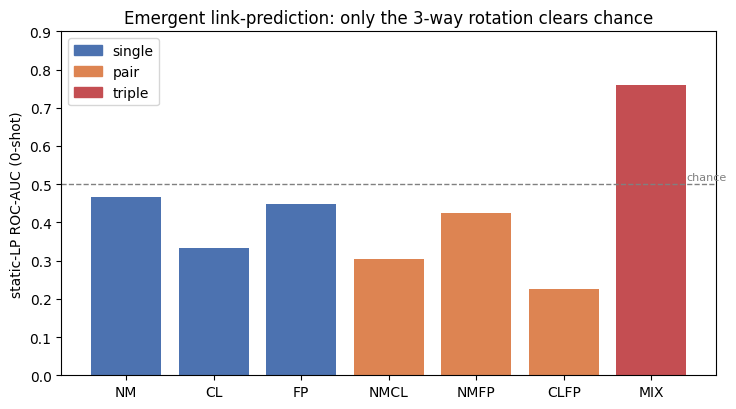

In [6]:
# Cell 2 — HEADLINE: static-LP AUC by arm, colored by group (chance = 0.5)
slp = mean_by_arm("static_link_prediction", "roc_auc")
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.bar(slp.index, slp.values, color=[GROUP_COLOR[arm2group[a]] for a in slp.index])
ax.axhline(0.5, ls="--", c="gray", lw=1)
ax.text(6.4, 0.51, "chance", color="gray", fontsize=8)
ax.set_ylabel("static-LP ROC-AUC (0-shot)"); ax.set_ylim(0, 0.9)
ax.set_title("Emergent link-prediction: only the 3-way rotation clears chance")
ax.legend(handles=[Patch(color=c, label=g) for g, c in GROUP_COLOR.items()])
plt.tight_layout()

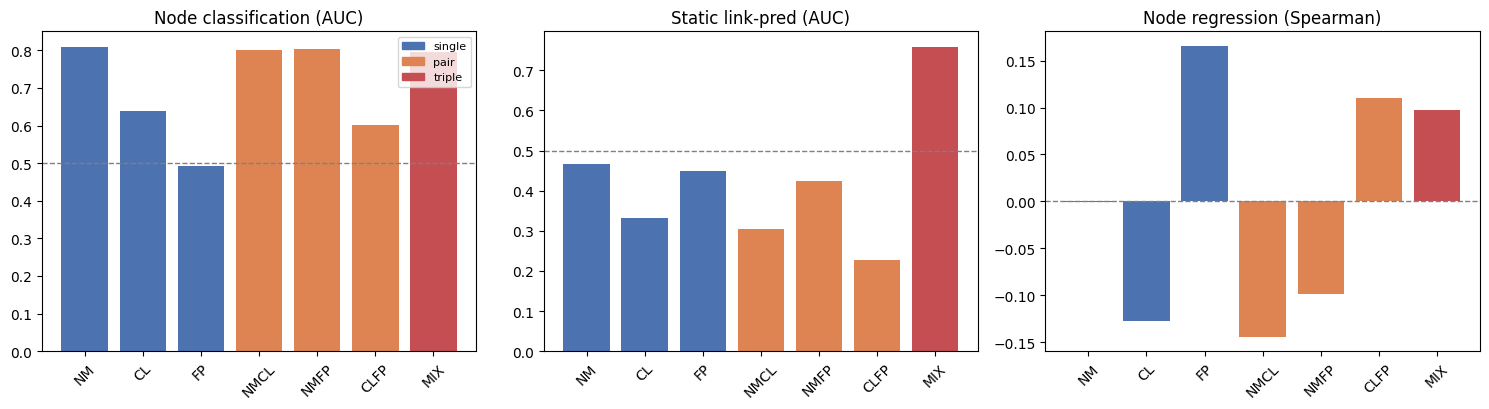

In [7]:
# Cell 3 — all three metrics side by side (single vs pair vs 3-way)
specs = [("classification", "roc_auc", "Node classification (AUC)", 0.5),
         ("static_link_prediction", "roc_auc", "Static link-pred (AUC)", 0.5),
         ("regression", "spearman", "Node regression (Spearman)", 0.0)]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (task, metric, title, chance) in zip(axes, specs):
    s = mean_by_arm(task, metric)
    ax.bar(s.index, s.values, color=[GROUP_COLOR[arm2group[a]] for a in s.index])
    ax.axhline(chance, ls="--", c="gray", lw=1)
    ax.set_title(title); ax.tick_params(axis="x", rotation=45)
axes[0].legend(handles=[Patch(color=c, label=g) for g, c in GROUP_COLOR.items()], fontsize=8)
plt.tight_layout()

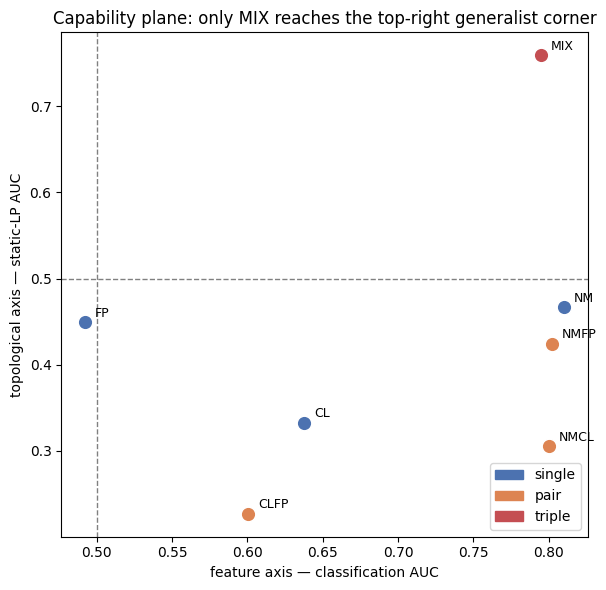

In [8]:
# Cell 5 — capability plane: feature (cls) vs topology (sLP); MIX = generalist corner
fig, ax = plt.subplots(figsize=(6.2, 6))
for a in ARM_ORDER:
    x, y = summary.loc[a, "classification"], summary.loc[a, "static_link_prediction"]
    ax.scatter(x, y, c=GROUP_COLOR[arm2group[a]], s=110, zorder=3, edgecolor="white")
    ax.annotate(a, (x, y), xytext=(7, 4), textcoords="offset points", fontsize=9)
ax.axhline(0.5, ls="--", c="gray", lw=1); ax.axvline(0.5, ls="--", c="gray", lw=1)
ax.set_xlabel("feature axis — classification AUC")
ax.set_ylabel("topological axis — static-LP AUC")
ax.set_title("Capability plane: only MIX reaches the top-right generalist corner")
ax.legend(handles=[Patch(color=c, label=g) for g, c in GROUP_COLOR.items()])
plt.tight_layout()

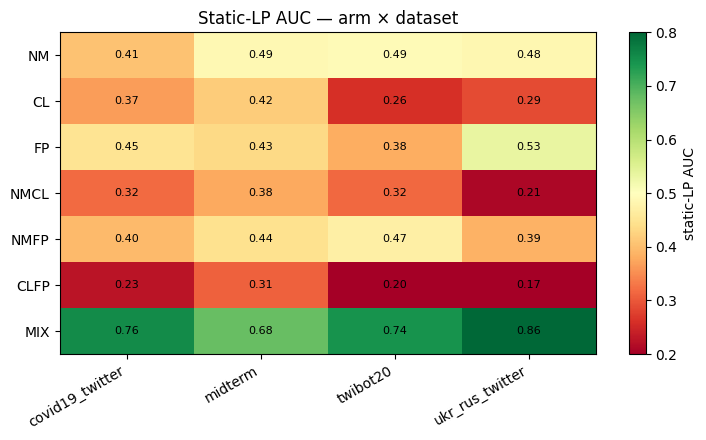

In [9]:
# Cell 6 — per-dataset static-LP heatmap (arm × dataset), diverging around chance
piv = (df[df.task == "static_link_prediction"]
       .pivot_table("roc_auc", "model", "dataset").reindex(ARM_ORDER))
fig, ax = plt.subplots(figsize=(7.5, 4.5))
im = ax.imshow(piv.values, cmap="RdYlGn", vmin=0.2, vmax=0.8, aspect="auto")  # 0.5 = midpoint
ax.set_xticks(range(piv.shape[1])); ax.set_xticklabels(piv.columns, rotation=30, ha="right")
ax.set_yticks(range(piv.shape[0])); ax.set_yticklabels(piv.index)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.values[i, j]
        ax.text(j, i, "" if np.isnan(v) else f"{v:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, label="static-LP AUC"); ax.set_title("Static-LP AUC — arm × dataset")
plt.tight_layout()

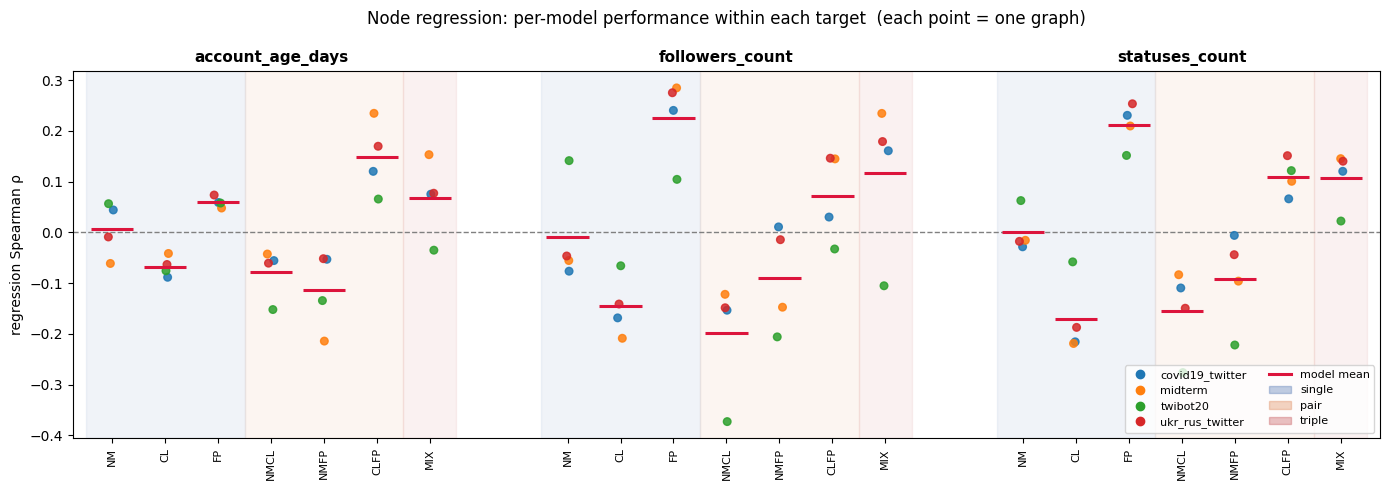

In [56]:
# Regression Spearman ρ — models nested within targets, one point per graph
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from collections import OrderedDict

GROUP_COLOR = {"single": "#4C72B0", "pair": "#DD8452", "triple": "#C44E52"}

path = '/Users/philipp/projects/gfm/prodigy/scripts/experiments/analysis/multitask_ssl_pairs/data/combined_all_arms.csv'
df = pd.read_csv(path)
df = df[
    (df.task == "regression") &
    (df.split == "test") &
    (df.target.isin(["followers_count", "statuses_count", "account_age_days"])) &
    (df.model.isin(["NM", "CL", "FP", "NMCL", "NMFP", "CLFP", "MIX"]))
]

arm2group   = df.drop_duplicates("model").set_index("model")["group"].to_dict()
reg = df[(df.task == "regression") & (df.split == "test")]
ARM_ORDER   = ["NM", "CL", "FP", "NMCL", "NMFP", "CLFP", "MIX"]
TARGETS     = sorted(reg.target.unique())
DATASETS   = sorted(reg.dataset.unique())
DATA_COLOR = dict(zip(DATASETS, plt.cm.tab10.colors))

# contiguous group blocks (lattice order keeps single/pair/triple contiguous)
group_span = OrderedDict()
for a in ARM_ORDER:
    group_span.setdefault(arm2group[a], []).append(a)

# x positions: model ticks, with a gap between target blocks
BLOCK_GAP, pos, target_center, x = 1.6, {}, {}, 0.0
for t in TARGETS:
    start = x
    for m in ARM_ORDER:
        pos[(t, m)] = x; x += 1
    target_center[t] = (start + x - 1) / 2
    x += BLOCK_GAP

fig, ax = plt.subplots(figsize=(14, 5))

# background band per objective-group, within each target block
for t in TARGETS:
    for g, arms in group_span.items():
        xs = [pos[(t, a)] for a in arms]
        ax.axvspan(min(xs) - 0.5, max(xs) + 0.5, color=GROUP_COLOR[g], alpha=0.08, zorder=0)

# points (one per graph) + per-model mean bar
rng = np.random.default_rng(0)
for t in TARGETS:
    for m in ARM_ORDER:
        sub  = reg[(reg.target == t) & (reg.model == m)].dropna(subset=["spearman"])
        vals = sub["spearman"].values
        xc = pos[(t, m)]
        ax.scatter(xc + (rng.random(len(vals)) - 0.5) * 0.15, vals,
                   s=30, c=[DATA_COLOR[d] for d in sub["dataset"]], alpha=0.85, zorder=3)
        if len(vals):
            ax.hlines(vals.mean(), xc - 0.4, xc + 0.4, color="crimson", lw=2.2, zorder=4)

ax.axhline(0, ls="--", c="gray", lw=1, zorder=1)             # chance

ax.set_xticks([pos[(t, m)] for t in TARGETS for m in ARM_ORDER])
ax.set_xticklabels([m for _ in TARGETS for m in ARM_ORDER], rotation=90, fontsize=8)
for t in TARGETS:                                            # target labels above each block
    ax.text(target_center[t], 1.015, t, ha="center", va="bottom",
            transform=ax.get_xaxis_transform(), fontweight="bold", fontsize=11)

ax.set_ylabel("regression Spearman ρ")
ax.set_title("Node regression: per-model performance within each target  (each point = one graph)", pad=34)
ax.margins(x=0.01)
ax.legend(handles=[*[Line2D([], [], marker="o", ls="", color=DATA_COLOR[d], label=d) for d in DATASETS],
                   Line2D([], [], color="crimson", lw=2.2, label="model mean"),
                   *[plt.Rectangle((0, 0), 1, 1, color=GROUP_COLOR[g], alpha=0.35, label=g)
                     for g in group_span]],
          loc="lower right", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

In [88]:
reg = df[(df.task == "regression") & (df.split == "test")].copy()
reg["rank"] = (reg.groupby(["target", "dataset"])["spearman"]
                  .rank(ascending=False, method="min"))   # 1 = best model for that target×graph
reg# mean rank per model across all target×graph cells (lower = better generalist)
reg.groupby("model")["rank"].mean().reindex(ARM_ORDER).sort_values()

# rank matrix: model × (target / graph)
(reg.assign(tg=reg.target + " / " + reg.dataset)
    .pivot_table("rank", "model", "tg").reindex(ARM_ORDER))

tg,account_age_days / covid19_twitter,account_age_days / midterm,account_age_days / twibot20,account_age_days / ukr_rus_twitter,followers_count / covid19_twitter,followers_count / midterm,followers_count / twibot20,followers_count / ukr_rus_twitter,statuses_count / covid19_twitter,statuses_count / midterm,statuses_count / twibot20,statuses_count / ukr_rus_twitter
model,,,,,,,,,,,,
NM,4.0,6.0,3.0,4.0,5.0,4.0,1.0,5.0,5.0,4.0,3.0,4.0
CL,7.0,4.0,5.0,7.0,7.0,7.0,4.0,6.0,7.0,7.0,5.0,7.0
FP,3.0,3.0,2.0,3.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0
NMCL,6.0,5.0,7.0,6.0,6.0,5.0,7.0,7.0,6.0,5.0,7.0,6.0
NMFP,5.0,7.0,6.0,5.0,4.0,6.0,6.0,4.0,4.0,6.0,6.0,5.0
CLFP,1.0,1.0,1.0,1.0,3.0,3.0,3.0,3.0,3.0,3.0,2.0,2.0
MIX,2.0,2.0,4.0,2.0,2.0,2.0,5.0,2.0,2.0,2.0,4.0,3.0


/var/folders/6w/cs8z0j913k1d_x_ywtvrm5xc0000gp/T/ipykernel_15005/1102414352.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right', fontsize=8, ncol=2)
/var/folders/6w/cs8z0j913k1d_x_ywtvrm5xc0000gp/T/ipykernel_15005/1102414352.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right', fontsize=8, ncol=2)
/var/folders/6w/cs8z0j913k1d_x_ywtvrm5xc0000gp/T/ipykernel_15005/1102414352.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right', fontsize=8, ncol=2)


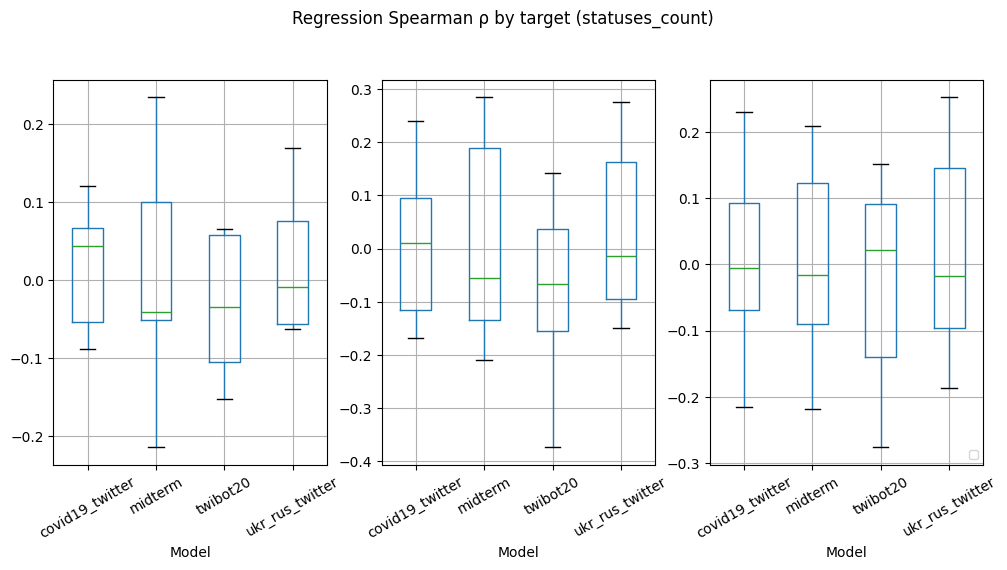

In [145]:
fig, ax = plt.subplots(1, 3, figsize=(12, 5))
for j, (i, g) in enumerate(reg[['dataset', 'target', 'model', 'spearman']].groupby('target')):
    g.pivot_table('spearman', index='model', columns='dataset').boxplot(ax=ax[j], rot=30)
    plt.suptitle(f"Regression Spearman ρ by target ({i})", fontsize=12, y=1.02)
    plt.legend(loc='lower right', fontsize=8, ncol=2)
    # plt.set_ylabel("Spearman ρ")
    ax[j].set_xlabel("Model")

In [155]:
# df['id'] = df['task'] + '-' + df['target'] + '-' + df['dataset']
# for (task, target, dataset), group in df.groupby(['task', 'target', 'dataset']):
#     group.plot.bar(x='model', y='spearman', title=f"{task} - {target} - {dataset}", legend=False)
#     plt.ylabel("Spearman ρ")
#     plt.xticks(rotation=45)
#     plt.tight_layout()
#     plt.show()

<Axes: xlabel='rank'>

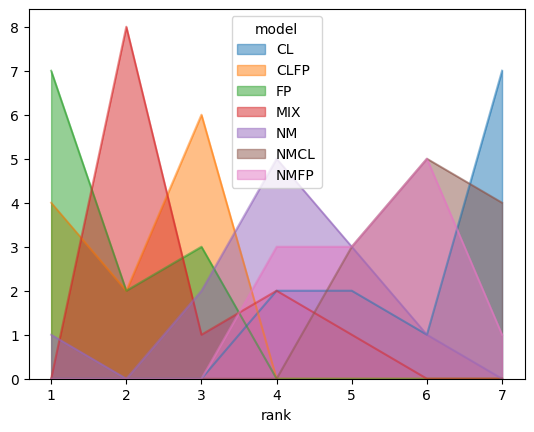

In [177]:
df['rank'] = df.groupby(['task', 'target', 'dataset'])['spearman'].rank(ascending=False, method='min')
df.groupby('model')['rank'].value_counts().unstack().T.plot.area(stacked=False)

In [259]:
path = '/Users/philipp/projects/gfm/prodigy/scripts/experiments/analysis/multitask_ssl_pairs/data/combined_all_arms.csv'
df = pd.read_csv(path)
df['rank'] = 0
i = df.task.eq('classification')
df.loc[i, 'rank'] = df[i].groupby(['task', 'dataset'], observed=False)['roc_auc'].rank(ascending=False, method='min')
i = df.task.eq('regression')
df.loc[i, 'rank'] = df[i].groupby(['task', 'target', 'dataset'], observed=False)['spearman'].rank(ascending=False, method='min')
i = df.task.eq('static_link_prediction')
df.loc[i, 'rank'] += df[i].groupby(['task', 'dataset'], observed=False)['roc_auc'].rank(ascending=False, method='min').fillna(0)
# df.groupby(['model', 'task', 'target'])['rank'].mean().groupby(['model', 'task']).mean()
df['target'] = df.target.fillna('na')

In [285]:
df

,group,k,model,task,dataset,target,split,shots,roc_auc,accuracy,f1,spearman,rmse,mae,r2,mse,run,rank
0,single,1,NM,classification,election2020,na,test,10,0.980380,0.964000,0.964215,NaN,NaN,NaN,NaN,NaN,eval_NM_to_election2020_pl_10shot_14_07_2026_1...,3
1,single,1,NM,classification,twibot20,na,test,10,0.639830,0.598833,0.610770,NaN,NaN,NaN,NaN,NaN,eval_NM_to_twibot20_pl_10shot_14_07_2026_11_53_16,2
2,single,1,CL,classification,election2020,na,test,10,0.664866,0.639000,0.642928,NaN,NaN,NaN,NaN,NaN,eval_CL_to_election2020_pl_10shot_14_07_2026_1...,5
3,single,1,CL,classification,twibot20,na,test,10,0.610638,0.583667,0.558813,NaN,NaN,NaN,NaN,NaN,eval_CL_to_twibot20_pl_10shot_14_07_2026_11_53_44,5
4,single,1,FP,classification,election2020,na,test,10,0.495312,0.500000,0.666667,NaN,NaN,NaN,NaN,NaN,eval_FP_to_election2020_pl_10shot_14_07_2026_1...,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,pair,2,CLFP,static_link_prediction,ukr_rus_twitter,na,test,0,0.168152,0.230500,0.120069,NaN,NaN,NaN,NaN,NaN,eval_CLFP_to_ukr_rus_twitter_slp_0shot_14_07_2...,7
122,triple,3,MIX,static_link_prediction,covid19_twitter,na,test,0,0.755080,0.676500,0.579050,NaN,NaN,NaN,NaN,NaN,eval_MIX_to_covid19_twitter_slp_0shot_14_07_20...,1
123,triple,3,MIX,static_link_prediction,midterm,na,test,0,0.676130,0.642250,0.534331,NaN,NaN,NaN,NaN,NaN,eval_MIX_to_midterm_slp_0shot_14_07_2026_11_35_05,1
124,triple,3,MIX,static_link_prediction,twibot20,na,test,0,0.744600,0.664750,0.566160,NaN,NaN,NaN,NaN,NaN,eval_MIX_to_twibot20_slp_0shot_14_07_2026_11_5...,1


In [ ]:
MODEL_ORDER = ['NM', 'CL', 'FP', 'NMCL', 'NMFP', 'CLFP', 'MIX']
COLORS = {'NM': 'tab:blue', 'CL': 'tab:orange', 'FP': 'tab:green'}
OBJECTIVES = {
    'NM': ['NM'], 'CL': ['CL'], 'FP': ['FP'],
    'NMCL': ['NM', 'CL'], 'NMFP': ['NM', 'FP'],
    'CLFP': ['CL', 'FP'], 'MIX': ['NM', 'CL', 'FP'],
}

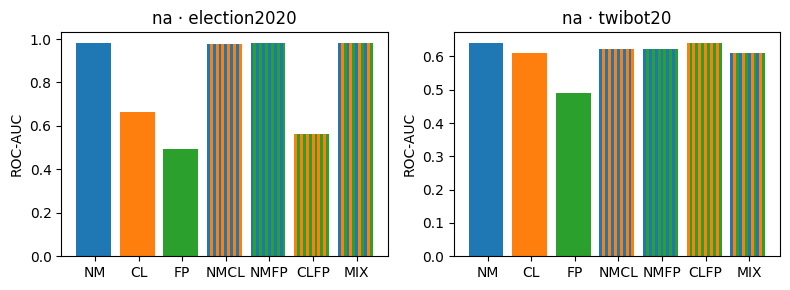

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

groups = list(df[df.task.eq('classification')].groupby(['target', 'dataset']))
fig, axes = plt.subplots(1, len(groups), figsize=(4 * len(groups), 3))
axes = np.atleast_1d(axes)

for ax, ((target, dataset), g) in zip(axes, groups):
    g = g.set_index('model').reindex(MODEL_ORDER)
    for x, (model, value) in enumerate(g['roc_auc'].items()):
        objs = OBJECTIVES[model]
        for i in range(12):  # alternating stripes
            ax.bar(x - .4 + i/15, value, width=1/15,
                   color=COLORS[objs[i % len(objs)]])
    ax.set(title=f'{target} · {dataset}', xticks=range(7),
           xticklabels=MODEL_ORDER, ylabel='ROC-AUC')

plt.tight_layout()

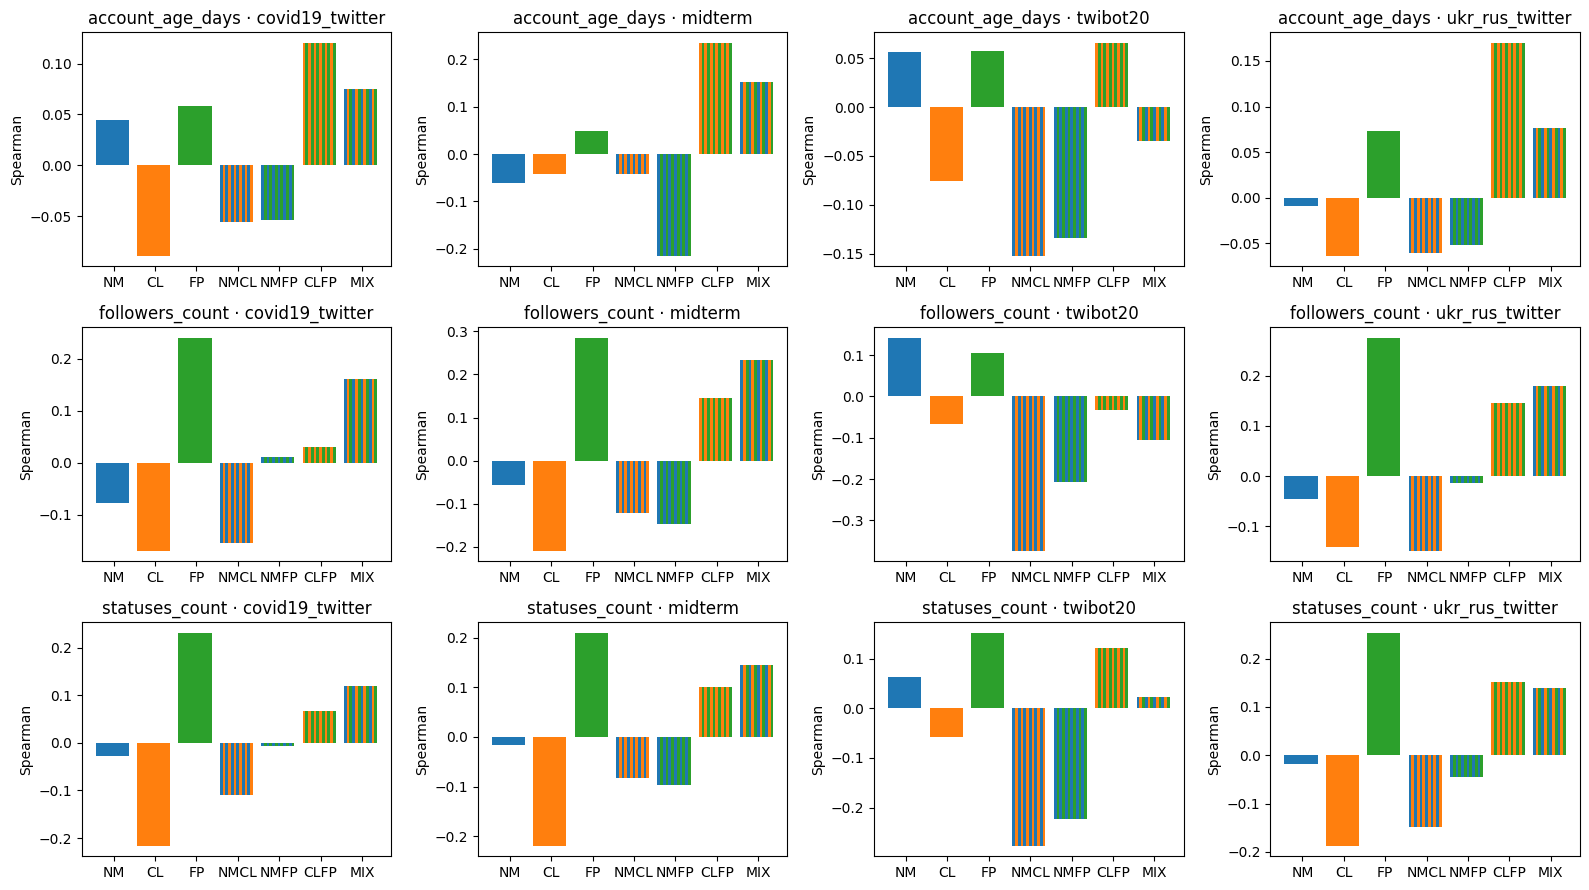

In [456]:
groups = list(df[df.task.eq('regression')].groupby(['target', 'dataset']))

fig, axes = plt.subplots(3, 4, figsize=(16, 9))
axes = axes.ravel()

for ax, ((target, dataset), g) in zip(axes, groups):
    g = g.set_index('model').reindex(MODEL_ORDER)

    for x, (model, value) in enumerate(g['spearman'].items()):
        objs = OBJECTIVES[model]
        for i in range(12):
            ax.bar(
                x - .4 + i / 15,
                value,
                width=1 / 15,
                color=COLORS[objs[i % len(objs)]],
            )

    ax.set(
        title=f'{target} · {dataset}',
        xticks=range(len(MODEL_ORDER)),
        xticklabels=MODEL_ORDER,
        ylabel='Spearman',
    )

for ax in axes[len(groups):]:
    ax.set_visible(False)

plt.tight_layout()

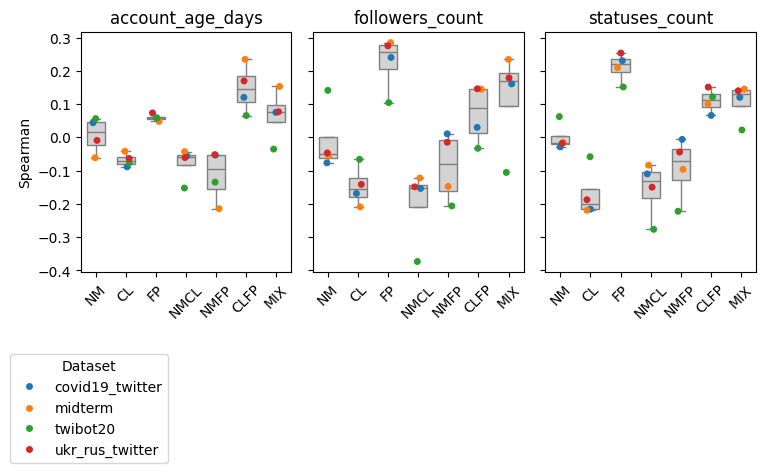

In [484]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = df[df.task.eq('regression')].copy()

targets = plot_df['target'].unique()
datasets = plot_df['dataset'].unique()
palette = dict(zip(datasets, sns.color_palette('tab10', len(datasets))))

fig, axes = plt.subplots(3, 4, figsize=(10, 9), sharey=True)
axes = axes.ravel()

for ax, target in zip(axes, targets):
    d = plot_df[plot_df.target.eq(target)]

    # One box per model, summarizing values across datasets
    sns.boxplot(
        data=d,
        x='model',
        y='spearman',
        order=MODEL_ORDER,
        color='lightgray',
        width=0.6,
        showfliers=False,
        ax=ax,
    )

    # Color the individual observations by dataset
    sns.stripplot(
        data=d,
        x='model',
        y='spearman',
        hue='dataset',
        order=MODEL_ORDER,
        hue_order=datasets,
        palette=palette,
        jitter=0.12,
        size=5,
        ax=ax,
    )

    ax.set_title(target)
    ax.set_xlabel('')
    ax.set_ylabel('Spearman')
    ax.tick_params(axis='x', rotation=45)

    if ax.legend_:
        ax.legend_.remove()

for ax in axes[len(targets):]:
    ax.set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title='Dataset',
    loc='center left',
    bbox_to_anchor=(0, 0.54),
)

# plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.tight_layout()

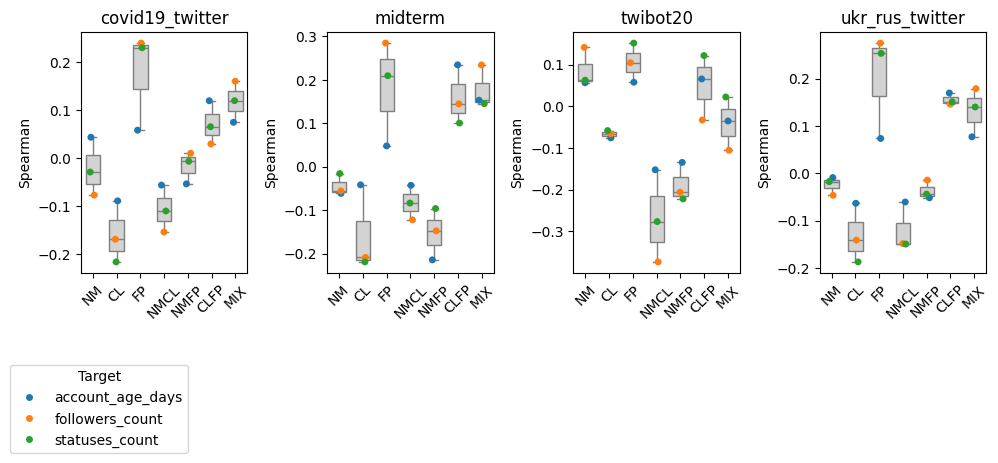

In [485]:
plot_df = df[df.task.eq('regression')].copy()

datasets = plot_df['dataset'].unique()
targets = plot_df['target'].unique()
palette = dict(zip(targets, sns.color_palette('tab10', len(targets))))

fig, axes = plt.subplots(
    3, 4,
    figsize=(10, 9),
    sharey=False,  # independent y-scale per dataset
)
axes = axes.ravel()

for ax, dataset in zip(axes, datasets):
    d = plot_df[plot_df.dataset.eq(dataset)]

    # One box per model, summarizing values across targets
    sns.boxplot(
        data=d,
        x='model',
        y='spearman',
        order=MODEL_ORDER,
        color='lightgray',
        width=0.6,
        showfliers=False,
        ax=ax,
    )

    # Color individual observations by target
    sns.stripplot(
        data=d,
        x='model',
        y='spearman',
        hue='target',
        order=MODEL_ORDER,
        hue_order=targets,
        palette=palette,
        jitter=0.12,
        size=5,
        ax=ax,
    )

    ax.set_title(dataset)
    ax.set_xlabel('')
    ax.set_ylabel('Spearman')
    ax.tick_params(axis='x', rotation=45)

    if ax.legend_:
        ax.legend_.remove()

for ax in axes[len(datasets):]:
    ax.set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title='Target',
    loc='center left',
    bbox_to_anchor=(0, 0.54),
)

plt.tight_layout()

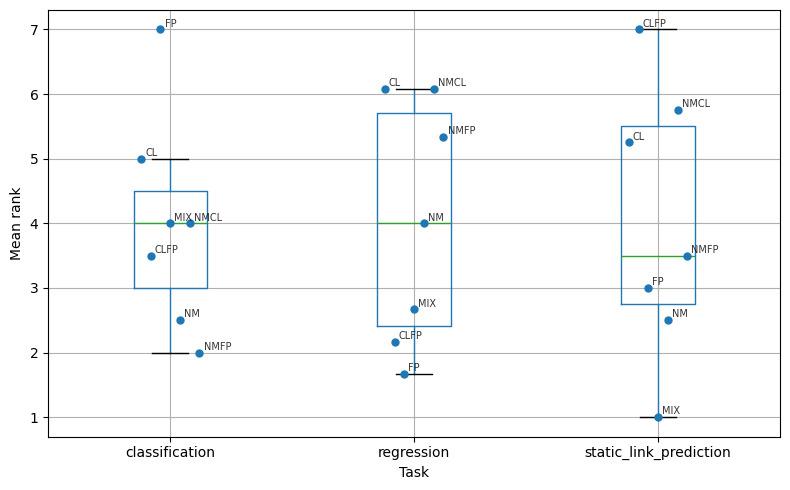

In [536]:
skills = (
    df.groupby(['model', 'task', 'target'])['rank'].mean()
      .groupby(['model', 'task']).mean()
      .unstack('task')
)

ax = skills.boxplot(figsize=(8, 5), showfliers=False)

for x, task in enumerate(skills.columns, start=1):
    values = skills[task].dropna()

    # Small horizontal offsets to reduce overlap
    offsets = np.linspace(-0.12, 0.12, len(values))

    ax.scatter(
        x + offsets,
        values,
        color='tab:blue',
        s=25,
        zorder=3,
    )

    for offset, (model, value) in zip(offsets, values.items()):
        ax.annotate(
            model,
            (x + offset, value),
            xytext=(3, 2),
            textcoords='offset points',
            fontsize=7,
            alpha=0.8,
        )

ax.set_xlabel('Task')
ax.set_ylabel('Mean rank')
plt.tight_layout()

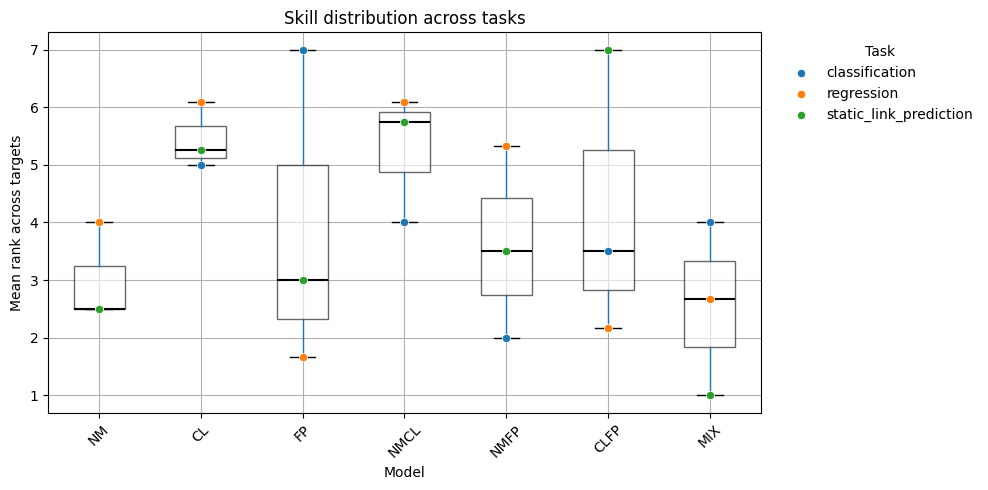

In [555]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Rows: models; columns: tasks
skills = (
    df.groupby(['model', 'task', 'target'])['rank']
      .mean()
      .groupby(['model', 'task'])
      .mean()
      .unstack('task')
      .reindex(MODEL_ORDER)
)

tasks = skills.columns.tolist()
models = skills.index.tolist()
colors = dict(zip(tasks, sns.color_palette('tab10', len(tasks))))

fig, ax = plt.subplots(figsize=(10, 5))

# One box per model, summarizing its task-level scores
skills.T.boxplot(
    ax=ax,
    showfliers=False,
    patch_artist=True,
    boxprops={
        'facecolor': 'white',
        'edgecolor': 'black',
        'alpha': 0.6,
    },
    medianprops={
        'color': 'black',
        'linewidth': 1.5,
    },
)

# Overlay one colored dot per task
offsets = np.linspace(-0.15, 0.15, len(tasks))

for offset, task in zip(offsets, tasks):
    values = skills[task]

    ax.scatter(
        np.arange(1, len(models) + 1),
        values,
        color=colors[task],
        s=35,
        label=task,
        edgecolor='white',
        linewidth=0.5,
        zorder=3,
    )

ax.set_xlabel('Model')
ax.set_ylabel('Mean rank across targets')
ax.set_title('Skill distribution across tasks')
ax.tick_params(axis='x', rotation=45)

ax.legend(
    title='Task',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False,
)

plt.tight_layout()
plt.show()

<Axes: xlabel='task'>

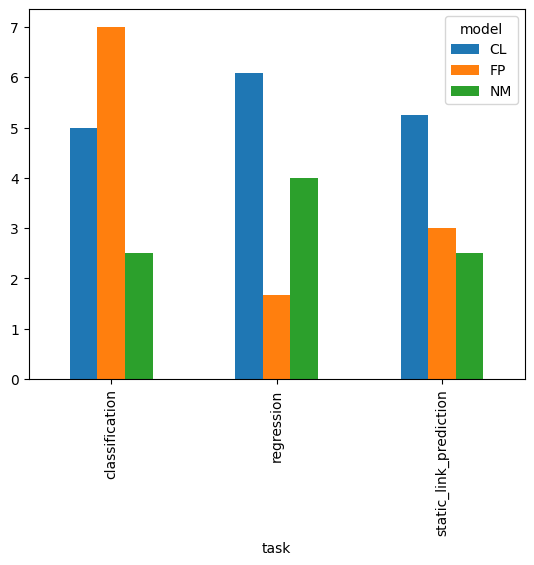

In [570]:
# Rows: models; columns: tasks
skills = (
    df[df.k.eq(1)].groupby(['model', 'task', 'target'])['rank']
      .mean()
      .groupby(['model', 'task'])
      .mean()
      .unstack('task')
    #   .reindex(MODEL_ORDER)
)
skills.T.plot.bar()

<Axes: xlabel='task'>

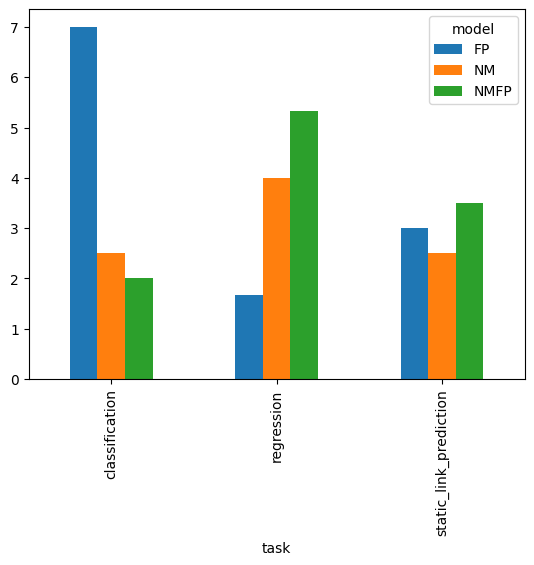

In [571]:
# Rows: models; columns: tasks
skills = (
    df[df.model.isin(['NM', 'FP', 'NMFP'])].groupby(['model', 'task', 'target'])['rank']
      .mean()
      .groupby(['model', 'task'])
      .mean()
      .unstack('task')
    #   .reindex(MODEL_ORDER)
)
skills.T.plot.bar()

In [594]:
import numpy as np
import pandas as pd

controls = {
    "NMCL": ["NM", "CL"],
    "NMFP": ["NM", "FP"],
    "CLFP": ["CL", "FP"],
    "NMCLFP": ["NM", "CL", "FP"],
}

keys = ["task", "dataset", "target", "split", "shots"]
metrics = ["roc_auc", "accuracy", "f1", 'spearman']

wide = df.pivot_table(
    index=keys,
    columns="model",
    values=metrics,
    aggfunc="mean",
)

comparisons = []

for metric in metrics:
    scores = wide[metric]

    for mixture, base_models in controls.items():
        required = [mixture] + base_models

        # Skip combinations not present in the dataframe.
        if not set(required).issubset(scores.columns):
            continue

        x = scores[required].dropna().copy()

        x["control_mean"] = x[base_models].mean(axis=1)
        x["best_control"] = x[base_models].max(axis=1)

        x["gain_vs_mean"] = x[mixture] - x["control_mean"]
        x["gain_vs_best"] = x[mixture] - x["best_control"]

        for base in base_models:
            x[f"gain_vs_{base}"] = x[mixture] - x[base]

        x["helps"] = x["gain_vs_best"] > 0
        x["mixture"] = mixture
        x["metric"] = metric

        comparisons.append(x.reset_index())

mixing = pd.concat(comparisons, ignore_index=True)

In [595]:
summary_by_task = (
    mixing.groupby(["task", "mixture", "metric"])
    .agg(
        comparisons=("gain_vs_best", "size"),
        mean_gain_vs_best=("gain_vs_best", "mean"),
        median_gain_vs_best=("gain_vs_best", "median"),
        win_rate_vs_best=("helps", "mean"),
        mean_gain_vs_mean=("gain_vs_mean", "mean"),
    )
    .reset_index()
    .sort_values(["task", "metric", "mean_gain_vs_best"], ascending=[True, True, False])
)

summary_by_task

,task,mixture,metric,comparisons,mean_gain_vs_best,median_gain_vs_best,win_rate_vs_best,mean_gain_vs_mean
6,classification,NMFP,accuracy,2,-0.004250,-0.004250,0.500000,0.136167
3,classification,NMCL,accuracy,2,-0.007833,-0.007833,0.000000,0.077208
0,classification,CLFP,accuracy,2,-0.029750,-0.029750,0.500000,0.025625
4,classification,NMCL,f1,2,-0.014825,-0.014825,0.000000,0.078486
7,classification,NMFP,f1,2,-0.038366,-0.038366,0.500000,0.047412
1,classification,CLFP,f1,2,-0.105183,-0.105183,0.000000,-0.074868
8,classification,NMFP,roc_auc,2,-0.007628,-0.007628,0.500000,0.151211
5,classification,NMCL,roc_auc,2,-0.009829,-0.009829,0.000000,0.076347
2,classification,CLFP,roc_auc,2,-0.037067,-0.037067,0.500000,0.035595
9,regression,CLFP,spearman,12,-0.055835,-0.105629,0.333333,0.090892


In [596]:
summary_by_task.pivot_table(
    index=["task", "mixture"],
    columns="metric",
    values=["mean_gain_vs_best", "win_rate_vs_best"],
)

mean_gain_vs_best                      \
metric                                  accuracy        f1   roc_auc   
task                   mixture                                         
classification         CLFP            -0.029750 -0.105183 -0.037067   
                       NMCL            -0.007833 -0.014825 -0.009829   
                       NMFP            -0.004250 -0.038366 -0.007628   
regression             CLFP                  NaN       NaN       NaN   
                       NMCL                  NaN       NaN       NaN   
                       NMFP                  NaN       NaN       NaN   
static_link_prediction CLFP            -0.253500 -0.507450 -0.222424   
                       NMCL            -0.030125 -0.533157 -0.161623   
                       NMFP            -0.036687 -0.652852 -0.065787   

                                         win_rate_vs_best               \
metric                          spearman         accuracy   f1 roc_auc   
task                   mixture                                           
classification         CLFP          NaN              0.5  0.0     0.5   
                       NMCL          NaN              0.0  0.0     0.0   
                       NMFP          NaN              0.5  0.5     0.5   
regression             CLFP    -0.055835              NaN  NaN     NaN   
                       NMCL    -0.145054              NaN  NaN     NaN   
                       NMFP    -0.266987              NaN  NaN     NaN   
static_link_prediction CLFP          NaN              0.0  0.0     0.0   
                       NMCL          NaN              0.0  0.0     0.0   
                       NMFP          NaN              0.0  0.0     0.0   

                                          
metric                          spearman  
task                   mixture            
classification         CLFP          NaN  
                       NMCL          NaN  
                       NMFP          NaN  
regression             CLFP     0.333333  
                       NMCL     0.000000  
                       NMFP     0.000000  
static_link_prediction CLFP          NaN  
                       NMCL          NaN  
                       NMFP          NaN

In [597]:
single_controls = ["NM", "CL", "FP"]
pair_controls = ["NMCL", "NMFP", "CLFP"]

required = ["MIX"] + single_controls + pair_controls
scores = wide[metric]

# Keep comparisons where every relevant model is available.
x = scores[required].dropna(subset=required).copy()

x["best_single"] = x[single_controls].max(axis=1)
x["best_pair"] = x[pair_controls].max(axis=1)

x["MIX_gain_vs_best_single"] = x["MIX"] - x["best_single"]
x["MIX_gain_vs_best_pair"] = x["MIX"] - x["best_pair"]

x["MIX_beats_all_singles"] = x["MIX_gain_vs_best_single"] > 0
x["MIX_beats_all_pairs"] = x["MIX_gain_vs_best_pair"] > 0

In [598]:
mix_results = []

for metric in metrics:
    scores = wide[metric]

    required = ["MIX"] + single_controls + pair_controls
    if not set(required).issubset(scores.columns):
        continue

    x = scores[required].dropna(subset=required).copy()

    x["best_single"] = x[single_controls].max(axis=1)
    x["best_pair"] = x[pair_controls].max(axis=1)

    x["gain_vs_best_single"] = x["MIX"] - x["best_single"]
    x["gain_vs_best_pair"] = x["MIX"] - x["best_pair"]

    x["beats_all_singles"] = x["gain_vs_best_single"] > 0
    x["beats_all_pairs"] = x["gain_vs_best_pair"] > 0
    x["metric"] = metric

    mix_results.append(x.reset_index())

mix_results = pd.concat(mix_results, ignore_index=True)

In [599]:
mix_summary = (
    mix_results.groupby(["task", "metric"])
    .agg(
        comparisons=("gain_vs_best_pair", "size"),

        mean_gain_vs_best_single=("gain_vs_best_single", "mean"),
        win_rate_vs_best_single=("beats_all_singles", "mean"),

        mean_gain_vs_best_pair=("gain_vs_best_pair", "mean"),
        median_gain_vs_best_pair=("gain_vs_best_pair", "median"),
        win_rate_vs_best_pair=("beats_all_pairs", "mean"),
    )
    .reset_index()
)

mix_summary

,task,metric,comparisons,mean_gain_vs_best_single,win_rate_vs_best_single,mean_gain_vs_best_pair,median_gain_vs_best_pair,win_rate_vs_best_pair
0,classification,accuracy,2,-0.005458,0.50,-0.009625,-0.009625,0.500000
1,classification,f1,2,-0.029461,0.50,0.005109,0.005109,1.000000
2,classification,roc_auc,2,-0.014977,0.50,-0.015775,-0.015775,0.000000
3,regression,spearman,12,-0.071465,0.25,-0.012553,-0.027982,0.416667
4,static_link_prediction,accuracy,4,0.154750,1.00,0.191437,0.171000,1.000000
5,static_link_prediction,f1,4,-0.062608,0.25,0.444842,0.412414,1.000000
6,static_link_prediction,roc_auc,4,0.269220,1.00,0.335007,0.316979,1.000000


In [600]:
mix_summary["mean_gain_vs_best_pair_pp"] = (
    100 * mix_summary["mean_gain_vs_best_pair"]
)

In [607]:
metric_by_task = {
    "classification": "roc_auc",
    "regression": "spearman",
    "static_link_prediction": "roc_auc",
}

import pandas as pd

# Model produced by combining each pair of objectives.
pair_model = {
    frozenset(["NM", "CL"]): "NMCL",
    frozenset(["NM", "FP"]): "NMFP",
    frozenset(["CL", "FP"]): "CLFP",
}

objectives = ["NM", "CL", "FP"]
match_keys = ["dataset", "target", "split", "shots"]

effects = []

for task, metric in metric_by_task.items():
    task_df = df[df["task"].eq(task)].copy()

    # Aggregate repeated runs within each matched evaluation setting.
    scores = (
        task_df.groupby(match_keys + ["model"], dropna=False)[metric]
        .mean()
        .rename("score")
        .reset_index()
    )

    for control in objectives:
        for added in objectives:
            if control == added:
                continue

            mixture = pair_model[frozenset([control, added])]

            control_scores = (
                scores[scores["model"].eq(control)]
                [match_keys + ["score"]]
                .rename(columns={"score": "control_score"})
            )

            mixture_scores = (
                scores[scores["model"].eq(mixture)]
                [match_keys + ["score"]]
                .rename(columns={"score": "mixture_score"})
            )

            matched = control_scores.merge(
                mixture_scores,
                on=match_keys,
                how="inner",
            )

            matched["delta"] = (
                matched["mixture_score"] - matched["control_score"]
            )

            effects.append({
                "adding": added,
                "control": control,
                "task": task,
                "mean_delta": matched["delta"].mean(),
                "n": len(matched),
            })

effects = pd.DataFrame(effects)

effect_table = (
    effects.pivot(
        index="adding",
        columns=["control", "task"],
        values="mean_delta",
    )
    .reindex(index=objectives, columns=objectives, level="control")
)

effect_table.index.name = "Adding objective"
effect_table.index = "+" + effect_table.index
effect_table.columns.names = ["Single-objective control", "Task"]

effect_table.fillna(0).style.format("{:+.3f}").background_gradient(
    cmap="RdBu",
    vmin=-abs(effect_table).max().max(),
    vmax=abs(effect_table).max().max(),
    axis=None,
)

In [608]:
missing_objective = {
    "NM": "CLFP",
    "CL": "NMFP",
    "FP": "NMCL",
}

match_keys = ["dataset", "target", "split", "shots"]

mix_effects = []

for task, metric in metric_by_task.items():
    task_df = df[df["task"].eq(task)].copy()

    scores = (
        task_df.groupby(match_keys + ["model"], dropna=False)[metric]
        .mean()
        .rename("score")
        .reset_index()
    )

    mix_scores = (
        scores[scores["model"].eq("MIX")]
        [match_keys + ["score"]]
        .rename(columns={"score": "mix_score"})
    )

    for added, pair_control in missing_objective.items():
        control_scores = (
            scores[scores["model"].eq(pair_control)]
            [match_keys + ["score"]]
            .rename(columns={"score": "control_score"})
        )

        matched = control_scores.merge(
            mix_scores,
            on=match_keys,
            how="inner",
        )

        matched["delta"] = (
            matched["mix_score"] - matched["control_score"]
        )

        mix_effects.append({
            "adding": added,
            "control": pair_control,
            "task": task,
            "mean_delta": matched["delta"].mean(),
            "n": len(matched),
        })

mix_effects = pd.DataFrame(mix_effects)

In [616]:
mix_effect_table = (
    mix_effects.pivot(
        index="adding",
        columns=["control", "task"],
        values="mean_delta",
    )
    .reindex(["NM", "CL", "FP"])
)

mix_effect_table.index.name = "Adding objective"
mix_effect_table.columns.names = [
    "Two-objective control",
    "Task",
]

mix_effect_table.fillna(0).style.format("{:+.3f}").background_gradient(
    cmap="RdBu",
    vmin=-abs(mix_effect_table).max().max(),
    vmax=abs(mix_effect_table).max().max(),
    axis=None,
)

Two-objective control,CLFP,NMFP,NMCL,CLFP,NMFP,NMCL,CLFP,NMFP,NMCL
Task,classification,classification,classification,regression,regression,regression,static_link_prediction,static_link_prediction,static_link_prediction
Adding objective,,,,,,,,,
NM,+0.194,+0.000,+0.000,-0.013,+0.000,+0.000,+0.532,+0.000,+0.000
CL,+0.000,-0.007,+0.000,+0.000,+0.196,+0.000,+0.000,+0.335,+0.000
FP,+0.000,+0.000,-0.005,+0.000,+0.000,+0.241,+0.000,+0.000,+0.454


In [617]:
compact_mix_table = (
    mix_effects.pivot(
        index="adding",
        columns="task",
        values="mean_delta",
    )
    .reindex(["NM", "CL", "FP"])
)

compact_mix_table.insert(
    0,
    "Added to",
    compact_mix_table.index.map(missing_objective),
)

compact_mix_table.index.name = "Adding objective"


task_cols = list(metric_by_task)

limit = compact_mix_table[task_cols].abs().max().max()

compact_mix_table.style.format(
    {col: "{:+.3f}" for col in task_cols}
).background_gradient(
    subset=task_cols,
    cmap="RdBu",
    vmin=-limit,
    vmax=limit,
    axis=None,
)

task,Added to,classification,regression,static_link_prediction
Adding objective,,,,
NM,CLFP,+0.194,-0.013,+0.532
CL,NMFP,-0.007,+0.196,+0.335
FP,NMCL,-0.005,+0.241,+0.454


In [618]:
import numpy as np
import pandas as pd

pair_model = {
    frozenset(["NM", "CL"]): "NMCL",
    frozenset(["NM", "FP"]): "NMFP",
    frozenset(["CL", "FP"]): "CLFP",
}

# Singleton → pair transitions
one_to_two = effects.copy()

one_to_two["destination"] = one_to_two.apply(
    lambda r: pair_model[frozenset([r["control"], r["adding"]])],
    axis=1,
)

one_to_two["transition"] = one_to_two.apply(
    lambda r: f'{r["control"]} + {r["adding"]} → {r["destination"]}',
    axis=1,
)

one_to_two["stage"] = "1 → 2 objectives"


# Pair → MIX transitions
two_to_three = mix_effects.copy()
two_to_three["destination"] = "MIX"

two_to_three["transition"] = two_to_three.apply(
    lambda r: f'{r["control"]} + {r["adding"]} → MIX',
    axis=1,
)

two_to_three["stage"] = "2 → 3 objectives"


all_effects = pd.concat(
    [one_to_two, two_to_three],
    ignore_index=True,
)

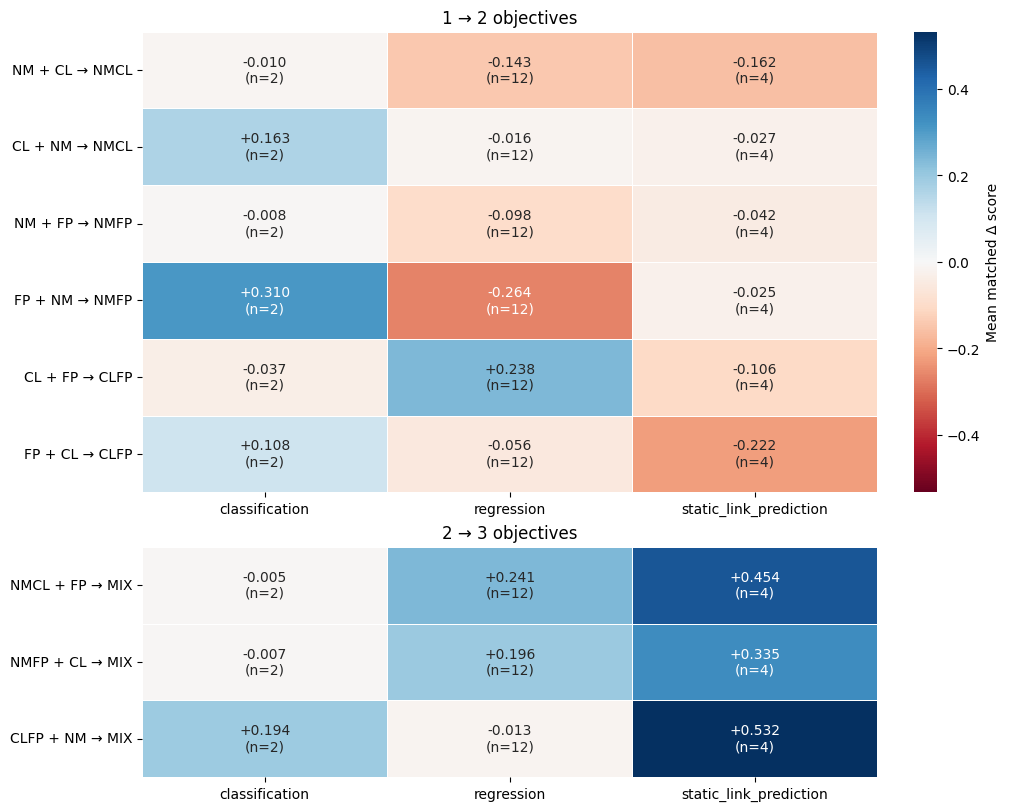

In [619]:
import matplotlib.pyplot as plt
import seaborn as sns

transition_order = {
    "1 → 2 objectives": [
        "NM + CL → NMCL",
        "CL + NM → NMCL",
        "NM + FP → NMFP",
        "FP + NM → NMFP",
        "CL + FP → CLFP",
        "FP + CL → CLFP",
    ],
    "2 → 3 objectives": [
        "NMCL + FP → MIX",
        "NMFP + CL → MIX",
        "CLFP + NM → MIX",
    ],
}

task_order = [
    "classification",
    "regression",
    "static_link_prediction",
]

# Same color scale across both panels.
limit = all_effects["mean_delta"].abs().max()

fig, axes = plt.subplots(
    2, 1,
    figsize=(10, 8),
    gridspec_kw={"height_ratios": [2, 1]},
    constrained_layout=True,
)

for ax, stage in zip(axes, transition_order):
    stage_df = all_effects[all_effects["stage"].eq(stage)]

    delta = (
        stage_df.pivot(
            index="transition",
            columns="task",
            values="mean_delta",
        )
        .reindex(
            index=transition_order[stage],
            columns=task_order,
        )
    )

    counts = (
        stage_df.pivot(
            index="transition",
            columns="task",
            values="n",
        )
        .reindex_like(delta)
    )

    # Show both effect and sample count in each cell.
    annotations = delta.copy().astype(object)

    for row in delta.index:
        for col in delta.columns:
            value = delta.loc[row, col]
            n = counts.loc[row, col]

            annotations.loc[row, col] = (
                ""
                if pd.isna(value)
                else f"{value:+.3f}\n(n={int(n)})"
            )

    sns.heatmap(
        delta,
        mask=delta.isna(),
        annot=annotations,
        fmt="",
        cmap="RdBu",
        center=0,
        vmin=-limit,
        vmax=limit,
        linewidths=0.5,
        linecolor="white",
        cbar=stage == "1 → 2 objectives",
        cbar_kws={"label": "Mean matched Δ score"},
        ax=ax,
    )

    ax.set_title(stage)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=0)
    ax.tick_params(axis="y", rotation=0)

plt.show()

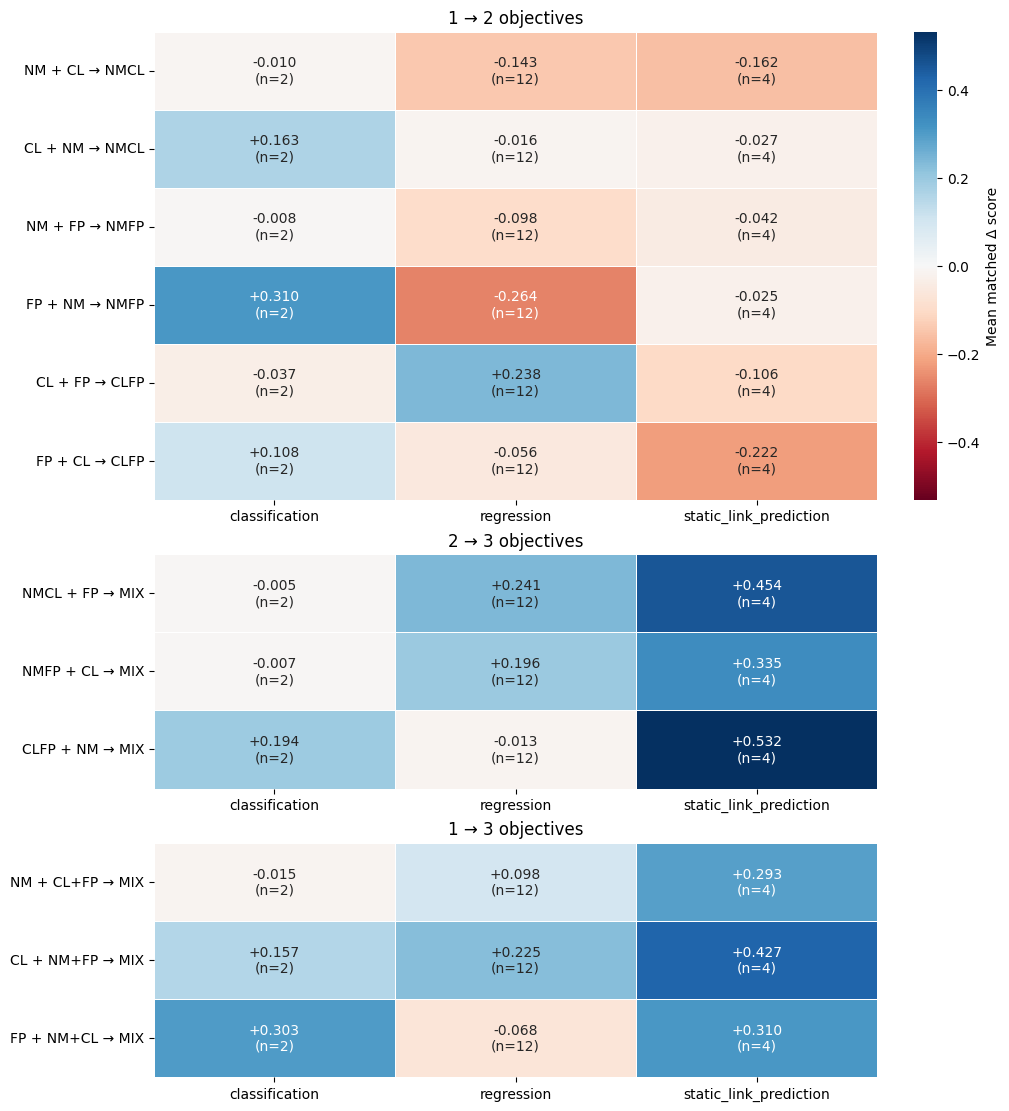

In [626]:
objectives = ["NM", "CL", "FP"]
one_to_three_rows = []

for task, metric in metric_by_task.items():
    task_df = df[df["task"].eq(task)]

    scores = (
        task_df.groupby(match_keys + ["model"], dropna=False)[metric]
        .mean()
        .rename("score")
        .reset_index()
    )

    mix_scores = (
        scores[scores["model"].eq("MIX")]
        [match_keys + ["score"]]
        .rename(columns={"score": "mix_score"})
    )

    for control in objectives:
        added = [obj for obj in objectives if obj != control]

        control_scores = (
            scores[scores["model"].eq(control)]
            [match_keys + ["score"]]
            .rename(columns={"score": "control_score"})
        )

        matched = control_scores.merge(
            mix_scores,
            on=match_keys,
            how="inner",
        )

        matched["delta"] = (
            matched["mix_score"] - matched["control_score"]
        )

        one_to_three_rows.append({
            "control": control,
            "adding": "+".join(added),
            "destination": "MIX",
            "transition": (
                f'{control} + {"+".join(added)} → MIX'
            ),
            "stage": "1 → 3 objectives",
            "task": task,
            "mean_delta": matched["delta"].mean(),
            "n": len(matched),
        })

one_to_three = pd.DataFrame(one_to_three_rows)

all_effects = pd.concat(
    [
        one_to_two,
        two_to_three,
        one_to_three,
    ],
    ignore_index=True,
)

transition_order = {
    "1 → 2 objectives": [
        "NM + CL → NMCL",
        "CL + NM → NMCL",
        "NM + FP → NMFP",
        "FP + NM → NMFP",
        "CL + FP → CLFP",
        "FP + CL → CLFP",
    ],
    "2 → 3 objectives": [
        "NMCL + FP → MIX",
        "NMFP + CL → MIX",
        "CLFP + NM → MIX",
    ],
    "1 → 3 objectives": [
        "NM + CL+FP → MIX",
        "CL + NM+FP → MIX",
        "FP + NM+CL → MIX",
    ],
}

fig, axes = plt.subplots(
    3, 1,
    figsize=(10, 11),
    gridspec_kw={"height_ratios": [2, 1, 1]},
    constrained_layout=True,
)

limit = all_effects["mean_delta"].abs().max()

D = []

for panel_i, (ax, stage) in enumerate(
    zip(axes, transition_order)
):
    stage_df = all_effects[all_effects["stage"].eq(stage)]

    delta = (
        stage_df.pivot(
            index="transition",
            columns="task",
            values="mean_delta",
        )
        .reindex(
            index=transition_order[stage],
            columns=task_order,
        )
    )

    counts = (
        stage_df.pivot(
            index="transition",
            columns="task",
            values="n",
        )
        .reindex_like(delta)
    )

    annotations = delta.copy().astype(object)

    for row in delta.index:
        for col in delta.columns:
            value = delta.loc[row, col]
            n = counts.loc[row, col]

            annotations.loc[row, col] = (
                ""
                if pd.isna(value)
                else f"{value:+.3f}\n(n={int(n)})"
            )

    sns.heatmap(
        delta,
        mask=delta.isna(),
        annot=annotations,
        fmt="",
        cmap="RdBu",
        center=0,
        vmin=-limit,
        vmax=limit,
        linewidths=0.5,
        linecolor="white",
        cbar=panel_i == 0,
        cbar_kws={"label": "Mean matched Δ score"},
        ax=ax,
    )
    D.append(delta)

    ax.set_title(stage)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=0)
    ax.tick_params(axis="y", rotation=0)

plt.show()

In [ ]:
D = pd.concat(D)

task,classification,regression,static_link_prediction
transition,,,
NM + CL → NMCL,-0.009829,-0.143415,-0.161623
CL + NM → NMCL,0.162524,-0.016136,-0.027324
NM + FP → NMFP,-0.007628,-0.097736,-0.042496
FP + NM → NMFP,0.310050,-0.263911,-0.024986
CL + FP → CLFP,-0.037067,0.237619,-0.105636
FP + CL → CLFP,0.108257,-0.055835,-0.222424
NMCL + FP → MIX,-0.005148,0.241201,0.454133
NMFP + CL → MIX,-0.007349,0.195523,0.335007
CLFP + NM → MIX,0.194444,-0.012553,0.532445


In [649]:
import numpy as np
import pandas as pd
from IPython.display import display

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

single_models = ["NM", "CL", "FP"]
multi_models = ["NMCL", "NMFP", "CLFP", "MIX"]

# Select the primary metric used for each downstream task.
# All of these metrics use "higher is better".
metric_by_task = {
    "classification": "roc_auc",
    "regression": "spearman",
    "static_link_prediction": "roc_auc",
}

# Columns that define the same evaluation condition.
# Do not include model, group, k, run, or rank.
match_keys = [
    "dataset",
    "target",
    "split",
    "shots",
]


# ------------------------------------------------------------
# Calculate matched deltas
# ------------------------------------------------------------

effect_rows = []

for task, metric in metric_by_task.items():
    task_df = df.loc[
        df["task"].eq(task)
        & df["model"].isin(single_models + multi_models),
        match_keys + ["model", metric],
    ].copy()

    # Average repeated runs for each model within the same condition.
    scores = (
        task_df
        .groupby(match_keys + ["model"], dropna=False)[metric]
        .mean()
        .rename("score")
        .reset_index()
    )

    for multi_model in multi_models:
        multi_scores = (
            scores.loc[
                scores["model"].eq(multi_model),
                match_keys + ["score"],
            ]
            .rename(columns={"score": "multi_score"})
        )

        for single_model in single_models:
            control_scores = (
                scores.loc[
                    scores["model"].eq(single_model),
                    match_keys + ["score"],
                ]
                .rename(columns={"score": "control_score"})
            )

            # Only compare settings available for both models.
            matched = multi_scores.merge(
                control_scores,
                on=match_keys,
                how="inner",
                validate="one_to_one",
            )

            matched["delta"] = (
                matched["multi_score"]
                - matched["control_score"]
            )

            effect_rows.append({
                "task": task,
                "single_model": single_model,
                "multi_model": multi_model,
                "metric": metric,
                "mean_delta": matched["delta"].mean(),
                "n": len(matched),
            })

effects = pd.DataFrame(effect_rows)

task_order = list(metric_by_task)

column_order = pd.MultiIndex.from_product(
    [task_order, single_models],
    names=["Task", "Single-objective control"],
)

delta_table = (
    effects.pivot(
        index="multi_model",
        columns=["task", "single_model"],
        values="mean_delta",
    )
    .reindex(
        index=multi_models,
        columns=column_order,
    )
)

delta_table.index.name = "Multi-objective model"

delta_table

n_table = (
    effects.pivot(
        index="multi_model",
        columns=["task", "single_model"],
        values="n",
    )
    .reindex(
        index=multi_models,
        columns=column_order,
    )
)

n_table.index.name = "Multi-objective model"

values = delta_table.to_numpy(dtype=float)
limit = np.nanmax(np.abs(values))

styled_delta_table = (
    delta_table.style
    .format("{:+.3f}", na_rep="—")
    .background_gradient(
        cmap="RdBu",  # red = negative; blue = positive
        vmin=-limit,
        vmax=limit,
        axis=None,
    )
    .set_caption(
        "Mean matched performance delta: "
        "multi-objective model − single-objective control"
    )
    .set_properties(**{
        "text-align": "center",
    })
)

display(styled_delta_table)

In [652]:
import numpy as np
import pandas as pd
from IPython.display import display

single_models = ["NM", "CL", "FP"]
two_way_models = ["NMCL", "NMFP", "CLFP"]

# Models shown as rows.
evaluated_models = two_way_models + ["MIX"]

# Models used as column-wise controls.
control_models = single_models + two_way_models

metric_by_task = {
    "classification": "roc_auc",
    "regression": "spearman",
    "static_link_prediction": "roc_auc",
}

match_keys = [
    "dataset",
    "target",
    "split",
    "shots",
]

effect_rows = []

for task, metric in metric_by_task.items():
    relevant_models = list(
        dict.fromkeys(evaluated_models + control_models)
    )

    task_df = df.loc[
        df["task"].eq(task)
        & df["model"].isin(relevant_models),
        match_keys + ["model", metric],
    ].copy()

    # Average repeated runs within each evaluation condition.
    scores = (
        task_df
        .groupby(match_keys + ["model"], dropna=False)[metric]
        .mean()
        .rename("score")
        .reset_index()
    )

    for evaluated_model in evaluated_models:
        evaluated_scores = (
            scores.loc[
                scores["model"].eq(evaluated_model),
                match_keys + ["score"],
            ]
            .rename(columns={"score": "evaluated_score"})
        )

        for control_model in control_models:
            # Do not compare a model with itself.
            if evaluated_model == control_model:
                continue

            control_scores = (
                scores.loc[
                    scores["model"].eq(control_model),
                    match_keys + ["score"],
                ]
                .rename(columns={"score": "control_score"})
            )

            matched = evaluated_scores.merge(
                control_scores,
                on=match_keys,
                how="inner",
                validate="one_to_one",
            )

            matched["delta"] = (
                matched["evaluated_score"]
                - matched["control_score"]
            )

            effect_rows.append({
                "task": task,
                "control_model": control_model,
                "evaluated_model": evaluated_model,
                "metric": metric,
                "mean_delta": matched["delta"].mean(),
                "n": len(matched),
            })

effects = pd.DataFrame(effect_rows)

task_order = list(metric_by_task)

column_order = pd.MultiIndex.from_product(
    [task_order, control_models],
    names=["Task", "Control model"],
)

delta_table = (
    effects.pivot(
        index="evaluated_model",
        columns=["task", "control_model"],
        values="mean_delta",
    )
    .reindex(
        index=evaluated_models,
        columns=column_order,
    )
)

delta_table.index.name = "Evaluated model"

values = delta_table.to_numpy(dtype=float)
limit = np.nanmax(np.abs(values))

styled_table = (
    delta_table.style
    .format("{:+.3f}", na_rep="—")
    .background_gradient(
        cmap="RdBu",
        vmin=-limit,
        vmax=limit,
        axis=None,
    )
    .set_caption(
        "Mean matched delta: evaluated model − control model"
    )
    .set_properties(**{
        "text-align": "center",
    })
)

display(styled_table)

n_table = (
    effects.pivot(
        index="evaluated_model",
        columns=["task", "control_model"],
        values="n",
    )
    .reindex(
        index=evaluated_models,
        columns=column_order,
    )
)

display(
    n_table.style
    .format("{:.0f}", na_rep="—")
    .set_caption("Number of matched evaluation settings")
)

In [654]:
import itertools
import numpy as np
import pandas as pd
from IPython.display import display

# ============================================================
# Configuration
# ============================================================

objectives = ["NM", "CL", "FP"]

# Adjust CL's related task here if necessary.
related_task = {
    "NM": "classification",
    "FP": "regression",
    "CL": "static_link_prediction",
}

metric_by_task = {
    "classification": "roc_auc",
    "regression": "spearman",
    "static_link_prediction": "roc_auc",
}

# Map each objective set to its model name.
model_for_objectives = {
    frozenset(["NM"]): "NM",
    frozenset(["CL"]): "CL",
    frozenset(["FP"]): "FP",
    frozenset(["NM", "CL"]): "NMCL",
    frozenset(["NM", "FP"]): "NMFP",
    frozenset(["CL", "FP"]): "CLFP",
    frozenset(["NM", "CL", "FP"]): "MIX",
}

# Same evaluation condition across models.
match_keys = [
    "dataset",
    "target",
    "split",
    "shots",
]


# ============================================================
# Compute every marginal objective-addition effect
# ============================================================

marginal_rows = []

for task, metric in metric_by_task.items():
    task_df = df.loc[
        df["task"].eq(task),
        match_keys + ["model", metric],
    ].copy()

    # Average repeated runs within each matched condition.
    scores = (
        task_df
        .groupby(match_keys + ["model"], dropna=False)[metric]
        .mean()
        .rename("score")
        .reset_index()
        .dropna(subset=["score"])
    )

    for added_objective in objectives:
        remaining = [
            obj for obj in objectives
            if obj != added_objective
        ]

        # Backgrounds are:
        #   - either one of the other objectives: 1 → 2
        #   - both of the other objectives: 2 → 3
        backgrounds = (
            [frozenset(x) for x in itertools.combinations(remaining, 1)]
            + [frozenset(remaining)]
        )

        for background in backgrounds:
            treatment_set = background | {added_objective}

            control_model = model_for_objectives[background]
            treatment_model = model_for_objectives[treatment_set]

            control_scores = (
                scores.loc[
                    scores["model"].eq(control_model),
                    match_keys + ["score"],
                ]
                .rename(columns={"score": "control_score"})
            )

            treatment_scores = (
                scores.loc[
                    scores["model"].eq(treatment_model),
                    match_keys + ["score"],
                ]
                .rename(columns={"score": "treatment_score"})
            )

            matched = control_scores.merge(
                treatment_scores,
                on=match_keys,
                how="inner",
                validate="one_to_one",
            )

            matched["delta"] = (
                matched["treatment_score"]
                - matched["control_score"]
            )

            background_label = "+".join(
                obj for obj in objectives
                if obj in background
            )

            for _, row in matched.iterrows():
                marginal_rows.append({
                    **{key: row[key] for key in match_keys},
                    "task": task,
                    "metric": metric,
                    "added_objective": added_objective,
                    "background": background_label,
                    "control_model": control_model,
                    "treatment_model": treatment_model,
                    "stage": f"{len(background)} → {len(treatment_set)}",
                    "transition": (
                        f"{control_model} + {added_objective}"
                        f" → {treatment_model}"
                    ),
                    "delta": row["delta"],
                })

marginal = pd.DataFrame(marginal_rows)

transition_summary = (
    marginal
    .groupby(
        [
            "added_objective",
            "task",
            "stage",
            "background",
            "control_model",
            "treatment_model",
            "transition",
        ],
        dropna=False,
    )
    .agg(
        mean_delta=("delta", "mean"),
        median_delta=("delta", "median"),
        win_rate=("delta", lambda x: (x > 0).mean()),
        n=("delta", "size"),
    )
    .reset_index()
)

transition_summary

objective_task_summary = (
    transition_summary
    .groupby(["added_objective", "task"])
    .agg(
        # Each of the three backgrounds receives equal weight.
        mean_delta=("mean_delta", "mean"),
        median_background_delta=("mean_delta", "median"),
        positive_backgrounds=(
            "mean_delta",
            lambda x: (x > 0).sum(),
        ),
        background_win_rate=(
            "mean_delta",
            lambda x: (x > 0).mean(),
        ),
        min_background_delta=("mean_delta", "min"),
        max_background_delta=("mean_delta", "max"),
        n_matched=("n", "sum"),
    )
    .reset_index()
)

objective_task_summary["related_task"] = (
    objective_task_summary["added_objective"]
    .map(related_task)
)

objective_task_summary["is_related_task"] = (
    objective_task_summary["task"]
    == objective_task_summary["related_task"]
)

related_results = (
    objective_task_summary
    .loc[
        objective_task_summary["is_related_task"],
        [
            "added_objective",
            "related_task",
            "mean_delta",
            "positive_backgrounds",
            "background_win_rate",
            "min_background_delta",
            "max_background_delta",
            "n_matched",
        ],
    ]
    .sort_values("added_objective")
    .reset_index(drop=True)
)

display(
    related_results.style
    .format({
        "mean_delta": "{:+.3f}",
        "background_win_rate": "{:.0%}",
        "min_background_delta": "{:+.3f}",
        "max_background_delta": "{:+.3f}",
    })
    .set_caption("Does each objective improve its related task?")
)

effect_matrix = (
    objective_task_summary
    .pivot(
        index="added_objective",
        columns="task",
        values="mean_delta",
    )
    .reindex(
        index=objectives,
        columns=list(metric_by_task),
    )
)

effect_matrix.index.name = "Added objective"
effect_matrix.columns.name = "Downstream task"

limit = np.nanmax(np.abs(effect_matrix.to_numpy(dtype=float)))

display(
    effect_matrix.style
    .format("{:+.3f}", na_rep="—")
    .background_gradient(
        cmap="RdBu",
        vmin=-limit,
        vmax=limit,
        axis=None,
    )
    .set_caption(
        "Mean marginal effect of adding each objective "
        "(equal-weighted across backgrounds)"
    )
)

context_matrix = (
    transition_summary
    .pivot(
        index=["added_objective", "transition"],
        columns="task",
        values="mean_delta",
    )
    .reindex(columns=list(metric_by_task))
)

limit = np.nanmax(np.abs(context_matrix.to_numpy(dtype=float)))

display(
    context_matrix.style
    .format("{:+.3f}", na_rep="—")
    .background_gradient(
        cmap="RdBu",
        vmin=-limit,
        vmax=limit,
        axis=None,
    )
    .set_caption(
        "Background-specific marginal objective effects"
    )
)

stage_summary = (
    transition_summary
    .groupby(["added_objective", "task", "stage"])
    .agg(
        mean_delta=("mean_delta", "mean"),
        positive_transitions=(
            "mean_delta",
            lambda x: (x > 0).sum(),
        ),
        transitions=("mean_delta", "size"),
    )
    .reset_index()
)

stage_summary

,added_objective,related_task,mean_delta,positive_backgrounds,background_win_rate,min_background_delta,max_background_delta,n_matched
0,CL,static_link_prediction,-0.016,1,33%,-0.222,+0.335,12
1,FP,regression,+0.127,2,67%,-0.098,+0.241,36
2,NM,classification,+0.222,3,100%,+0.163,+0.310,6


Downstream task,classification,regression,static_link_prediction
Added objective,,,
NM,+0.222,-0.098,+0.160
CL,+0.030,-0.001,-0.016
FP,-0.017,+0.127,+0.102


,added_objective,task,stage,mean_delta,positive_transitions,transitions
0,CL,classification,1 → 2,0.049214,1,2
1,CL,classification,2 → 3,-0.007349,0,1
2,CL,regression,1 → 2,-0.099625,0,2
3,CL,regression,2 → 3,0.195523,1,1
4,CL,static_link_prediction,1 → 2,-0.192024,0,2
5,CL,static_link_prediction,2 → 3,0.335007,1,1
6,FP,classification,1 → 2,-0.022348,0,2
7,FP,classification,2 → 3,-0.005148,0,1
8,FP,regression,1 → 2,0.069941,1,2
9,FP,regression,2 → 3,0.241201,1,1


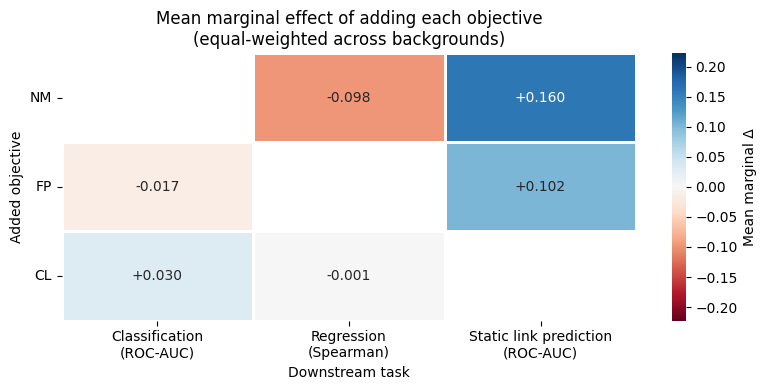

In [709]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

objective_order = ["NM", "FP", "CL"]
task_order = [
    "classification",
    "regression",
    "static_link_prediction",
]

effect_matrix = (
    objective_task_summary
    .pivot(
        index="added_objective",
        columns="task",
        values="mean_delta",
    )
    .reindex(
        index=objective_order,
        columns=task_order,
    )
)

# Symmetric color scale centered at zero.
limit = np.nanmax(
    np.abs(effect_matrix.to_numpy(dtype=float))
)


# Outline the hypothesized objective-task relationships:
# NM → classification, FP → regression, CL → static LP
related_task = {
    "NM": "classification",
    "FP": "regression",
    "CL": "static_link_prediction",
}

# True means hidden.
mask = pd.DataFrame(
    False,
    index=effect_matrix.index,
    columns=effect_matrix.columns,
)

for objective, task in related_task.items():
    mask.loc[objective, task] = True
    
    
fig, ax = plt.subplots(figsize=(8, 4))
ax.set_facecolor("white")


sns.heatmap(
    effect_matrix,
    mask=mask,
    annot=True,
    fmt="+.3f",
    cmap="RdBu",
    center=0,
    vmin=-limit,
    vmax=limit,
    linewidths=1,
    linecolor="white",
    cbar_kws={"label": "Mean marginal Δ"},
    ax=ax,
)


ax.set_title(
    "Mean marginal effect of adding each objective\n"
    "(equal-weighted across backgrounds)"
)
ax.set_xlabel("Downstream task")
ax.set_ylabel("Added objective")

ax.set_xticklabels(
    [
        "Classification\n(ROC-AUC)",
        "Regression\n(Spearman)",
        "Static link prediction\n(ROC-AUC)",
    ],
    rotation=0,
)

ax.set_yticklabels(
    objective_order,
    rotation=0,
)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

objective_order = ["NM", "FP", "CL"]
task_order = [
    "classification",
    "regression",
    "static_link_prediction",
]

effect_matrix = (
    objective_task_summary
    .pivot(
        index="added_objective",
        columns="task",
        values="mean_delta",
    )
    .reindex(
        index=objective_order,
        columns=task_order,
    )
)

# Symmetric color scale centered at zero.
limit = np.nanmax(
    np.abs(effect_matrix.to_numpy(dtype=float))
)

fig, ax = plt.subplots(figsize=(8, 4))

effect_matrix

sns.heatmap(
    effect_matrix,
    annot=True,
    fmt="+.3f",
    cmap="RdBu",          # negative = red, positive = blue
    center=0,
    vmin=-limit,
    vmax=limit,
    linewidths=1,
    linecolor="white",
    cbar_kws={
        "label": "Mean marginal Δ",
    },
    ax=ax,
)

ax.set_title(
    "Mean marginal effect of adding each objective\n"
    "(equal-weighted across backgrounds)"
)
ax.set_xlabel("Downstream task")
ax.set_ylabel("Added objective")

ax.set_xticklabels(
    [
        "Classification\n(ROC-AUC)",
        "Regression\n(Spearman)",
        "Static link prediction\n(ROC-AUC)",
    ],
    rotation=0,
)

ax.set_yticklabels(
    objective_order,
    rotation=0,
)

# Outline the hypothesized objective-task relationships:
# NM → classification, FP → regression, CL → static LP
related_task = {
    "NM": "classification",
    "FP": "regression",
    "CL": "static_link_prediction",
}

plt.tight_layout()
plt.show()

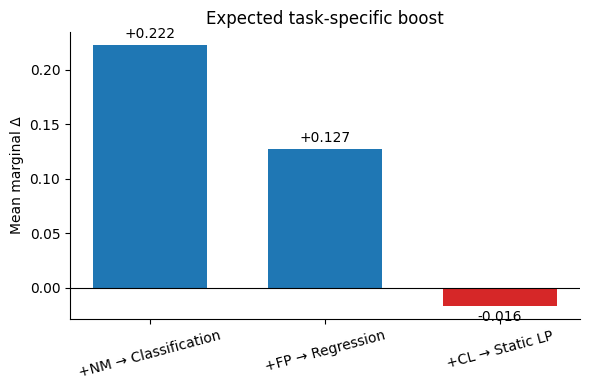

In [701]:
import pandas as pd
import matplotlib.pyplot as plt

expected = pd.DataFrame({
    "added_objective": ["NM", "FP", "CL"],
    "task": [
        "classification",
        "regression",
        "static_link_prediction",
    ],
    "label": [
        "+NM → Classification",
        "+FP → Regression",
        "+CL → Static LP",
    ],
})

expected = expected.merge(
    objective_task_summary[
        ["added_objective", "task", "mean_delta"]
    ],
    on=["added_objective", "task"],
    how="left",
)

fig, ax = plt.subplots(figsize=(6, 4))

colors = [
    "tab:blue" if value >= 0 else "tab:red"
    for value in expected["mean_delta"]
]

bars = ax.bar(
    expected["label"],
    expected["mean_delta"],
    color=colors,
    width=.65,
)

ax.axhline(0, color="black", linewidth=.8)
ax.bar_label(bars, fmt="%+.3f", padding=3)

ax.set_ylabel("Mean marginal Δ")
ax.set_title("Expected task-specific boost")
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

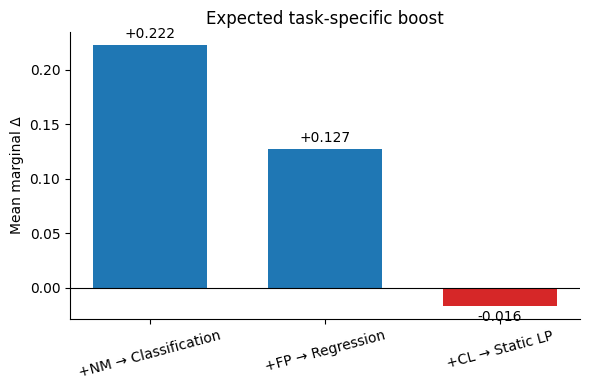

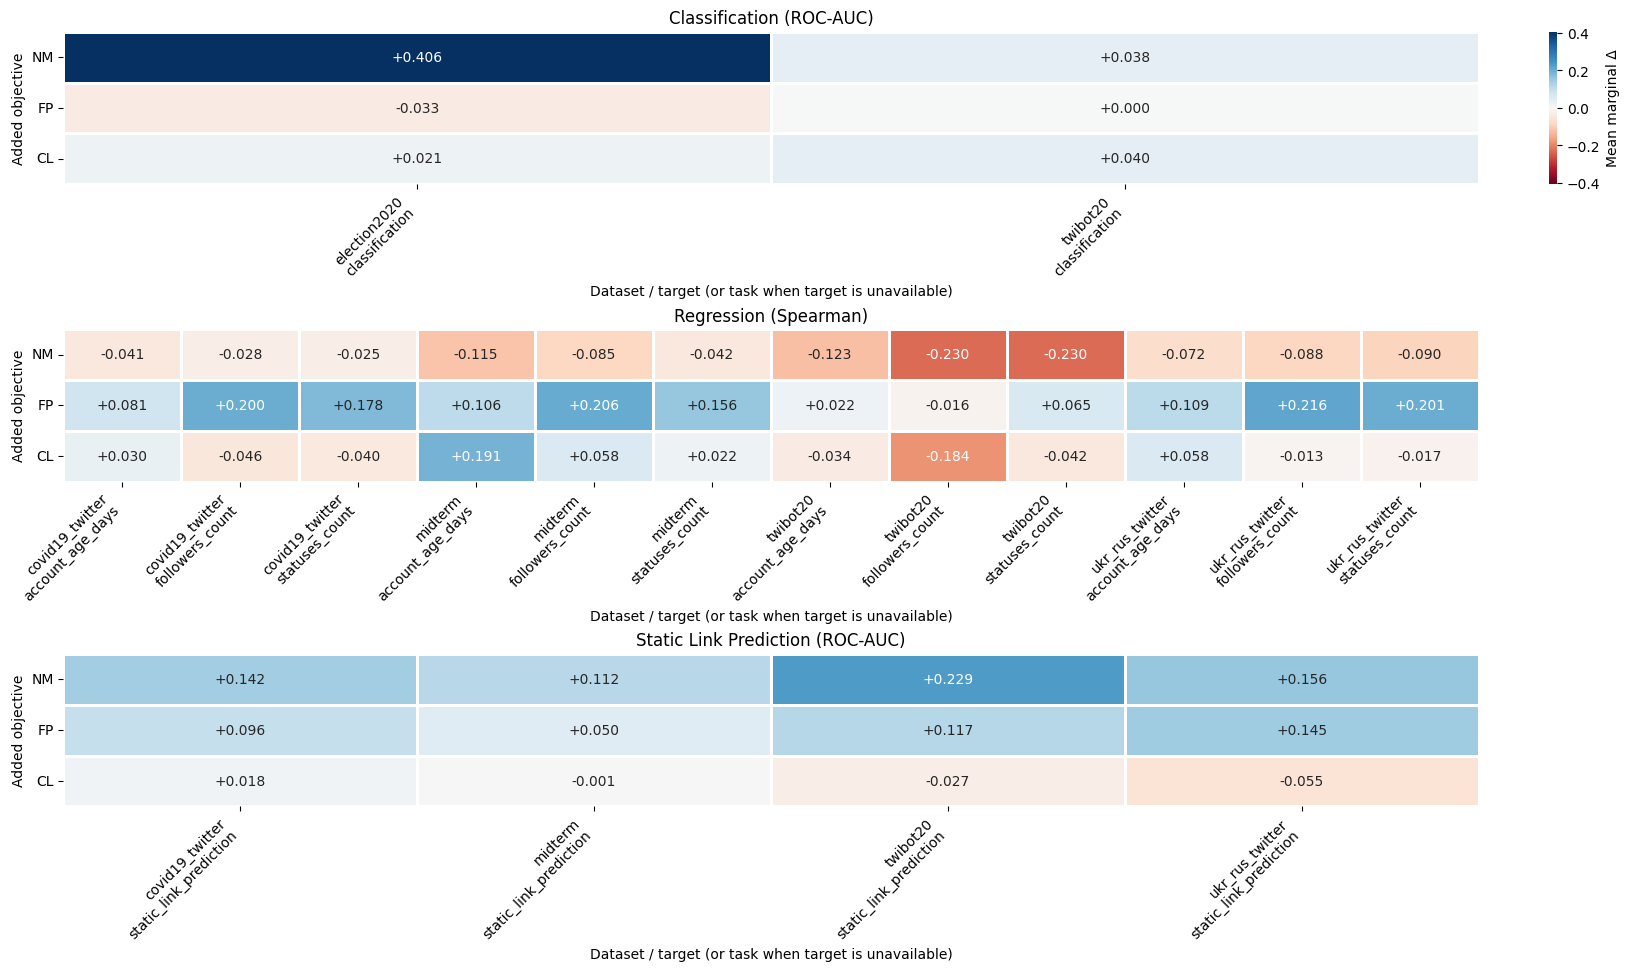

In [660]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plot_data = marginal.copy()

# ------------------------------------------------------------
# Use target when it exists; otherwise use the downstream task.
# ------------------------------------------------------------

target_text = plot_data["target"].astype("string").str.strip()

missing_target = (
    target_text.isna()
    | target_text.str.lower().isin(
        ["", "na", "n/a", "nan", "none", "null"]
    )
)

plot_data["target_or_task"] = target_text.mask(
    missing_target,
    plot_data["task"].astype("string"),
)


# ------------------------------------------------------------
# First average within each objective background.
#
# This collapses split/shots within each
# objective × task × dataset × target × background.
# ------------------------------------------------------------

background_effects = (
    plot_data
    .groupby(
        [
            "added_objective",
            "task",
            "dataset",
            "target_or_task",
            "background",
        ],
        dropna=False,
    )
    .agg(
        background_mean_delta=("delta", "mean"),
        n=("delta", "size"),
    )
    .reset_index()
)


# ------------------------------------------------------------
# Then give each background equal weight.
#
# For example, +NM averages:
#   NMCL - CL
#   NMFP - FP
#   MIX  - CLFP
#
# separately for each dataset and target.
# ------------------------------------------------------------

cell_effects = (
    background_effects
    .groupby(
        [
            "added_objective",
            "task",
            "dataset",
            "target_or_task",
        ],
        dropna=False,
    )
    .agg(
        mean_delta=("background_mean_delta", "mean"),
        backgrounds=("background", "nunique"),
        n_matched=("n", "sum"),
    )
    .reset_index()
)

objective_order = ["NM", "FP", "CL"]

task_order = [
    task for task in [
        "classification",
        "regression",
        "static_link_prediction",
    ]
    if task in cell_effects["task"].unique()
]

metric_by_task = {
    "classification": "ROC-AUC",
    "regression": "Spearman",
    "static_link_prediction": "ROC-AUC",
}

# Use one shared zero-centered color scale.
limit = cell_effects["mean_delta"].abs().max()

# Determine width from the task with the most dataset/target cells.
max_columns = (
    cell_effects
    .groupby("task")[["dataset", "target_or_task"]]
    .apply(lambda x: len(x.drop_duplicates()))
    .max()
)

fig, axes = plt.subplots(
    nrows=len(task_order),
    ncols=1,
    figsize=(
        max(9, 1.35 * max_columns),
        3.2 * len(task_order),
    ),
    constrained_layout=True,
)

if len(task_order) == 1:
    axes = [axes]

for panel_i, (ax, task) in enumerate(
    zip(axes, task_order)
):
    task_effects = cell_effects[
        cell_effects["task"].eq(task)
    ].copy()

    matrix = (
        task_effects
        .pivot(
            index="added_objective",
            columns=["dataset", "target_or_task"],
            values="mean_delta",
        )
        .reindex(index=objective_order)
    )

    # Sort columns by dataset, then target/task.
    matrix = matrix.sort_index(
        axis=1,
        level=[0, 1],
    )

    # Create compact two-line labels.
    column_labels = [
        f"{dataset}\n{target}"
        for dataset, target in matrix.columns
    ]

    sns.heatmap(
        matrix,
        mask=matrix.isna(),
        annot=True,
        fmt="+.3f",
        cmap="RdBu",
        center=0,
        vmin=-limit,
        vmax=limit,
        linewidths=0.75,
        linecolor="white",
        cbar=panel_i == 0,
        cbar_kws={
            "label": "Mean marginal Δ",
        },
        ax=ax,
    )

    ax.set_title(
        f"{task.replace('_', ' ').title()} "
        f"({metric_by_task[task]})"
    )
    ax.set_xlabel("Dataset / target (or task when target is unavailable)")
    ax.set_ylabel("Added objective")

    ax.set_xticklabels(
        column_labels,
        rotation=45,
        ha="right",
    )
    ax.set_yticklabels(
        objective_order,
        rotation=0,
    )

plt.show()



In [661]:
background_count_table = (
    cell_effects
    .pivot(
        index="added_objective",
        columns=["dataset", "target_or_task"],
        values="backgrounds",
    )
    .reindex(index=objective_order)
)

background_count_table

dataset           election2020       twibot20  covid19_twitter  \
target_or_task  classification classification account_age_days   
added_objective                                                  
NM                           3              3                3   
FP                           3              3                3   
CL                           3              3                3   

dataset                                                 midterm  \
target_or_task  followers_count statuses_count account_age_days   
added_objective                                                   
NM                            3              3                3   
FP                            3              3                3   
CL                            3              3                3   

dataset                                                twibot20  \
target_or_task  followers_count statuses_count account_age_days   
added_objective                                                   
NM                            3              3                3   
FP                            3              3                3   
CL                            3              3                3   

dataset                                         ukr_rus_twitter  \
target_or_task  followers_count statuses_count account_age_days   
added_objective                                                   
NM                            3              3                3   
FP                            3              3                3   
CL                            3              3                3   

dataset                                               covid19_twitter  \
target_or_task  followers_count statuses_count static_link_prediction   
added_objective                                                         
NM                            3              3                      3   
FP                            3              3                      3   
CL                            3              3                      3   

dataset                        midterm               twibot20  \
target_or_task  static_link_prediction static_link_prediction   
added_objective                                                 
NM                                   3                      3   
FP                                   3                      3   
CL                                   3                      3   

dataset                ukr_rus_twitter  
target_or_task  static_link_prediction  
added_objective                         
NM                                   3  
FP                                   3  
CL                                   3

In [663]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plot_data = marginal.copy()

# Use target when available; otherwise use task.
target_text = plot_data["target"].astype("string").str.strip()

missing_target = (
    target_text.isna()
    | target_text.str.lower().isin(
        ["", "na", "n/a", "nan", "none", "null"]
    )
)

plot_data["target_or_task"] = target_text.mask(
    missing_target,
    plot_data["task"].astype("string"),
)

# First average matched deltas within each background.
background_effects = (
    plot_data
    .groupby(
        [
            "stage",
            "added_objective",
            "task",
            "dataset",
            "target_or_task",
            "background",
        ],
        dropna=False,
    )
    .agg(
        background_mean_delta=("delta", "mean"),
        n=("delta", "size"),
    )
    .reset_index()
)

# Then average backgrounds within each stage.
stage_cell_effects = (
    background_effects
    .groupby(
        [
            "stage",
            "added_objective",
            "task",
            "dataset",
            "target_or_task",
        ],
        dropna=False,
    )
    .agg(
        mean_delta=("background_mean_delta", "mean"),
        backgrounds=("background", "nunique"),
        n_matched=("n", "sum"),
    )
    .reset_index()
)

# Expected background counts:
# 1 → 2: add O to either of the other two singleton objectives
# 2 → 3: add O to the pair containing the other two objectives
expected_backgrounds = {
    "1 → 2": 2,
    "2 → 3": 1,
}

stage_cell_effects["complete"] = (
    stage_cell_effects["backgrounds"]
    == stage_cell_effects["stage"].map(expected_backgrounds)
)

# Mask incomplete cells by default.
stage_cell_effects["plot_delta"] = (
    stage_cell_effects["mean_delta"]
    .where(stage_cell_effects["complete"])
)

objective_order = ["NM", "FP", "CL"]

task_order = [
    task for task in [
        "classification",
        "regression",
        "static_link_prediction",
    ]
    if task in stage_cell_effects["task"].unique()
]

metric_label = {
    "classification": "ROC-AUC",
    "regression": "Spearman",
    "static_link_prediction": "ROC-AUC",
}

# One shared scale across both figures.
limit = stage_cell_effects["plot_delta"].abs().max()


def plot_stage(stage):
    stage_data = stage_cell_effects[
        stage_cell_effects["stage"].eq(stage)
    ]

    max_columns = (
        stage_data
        .groupby("task")[["dataset", "target_or_task"]]
        .apply(lambda x: len(x.drop_duplicates()))
        .max()
    )

    fig, axes = plt.subplots(
        nrows=len(task_order),
        ncols=1,
        figsize=(
            max(9, 1.35 * max_columns),
            3.2 * len(task_order),
        ),
        constrained_layout=True,
    )

    if len(task_order) == 1:
        axes = [axes]

    for panel_i, (ax, task) in enumerate(
        zip(axes, task_order)
    ):
        task_data = stage_data[
            stage_data["task"].eq(task)
        ]

        matrix = (
            task_data
            .pivot(
                index="added_objective",
                columns=["dataset", "target_or_task"],
                values="plot_delta",
            )
            .reindex(index=objective_order)
            .sort_index(axis=1, level=[0, 1])
        )

        column_labels = [
            f"{dataset}\n{target}"
            for dataset, target in matrix.columns
        ]

        sns.heatmap(
            matrix,
            mask=matrix.isna(),
            annot=True,
            fmt="+.3f",
            cmap="RdBu",
            center=0,
            vmin=-limit,
            vmax=limit,
            linewidths=0.75,
            linecolor="white",
            cbar=panel_i == 0,
            cbar_kws={
                "label": "Mean marginal Δ",
            },
            ax=ax,
        )

        ax.set_title(
            f"{task.replace('_', ' ').title()} "
            f"({metric_label[task]})"
        )
        ax.set_xlabel(
            "Dataset / target "
            "(or task when target is unavailable)"
        )
        ax.set_ylabel("Added objective")

        ax.set_xticklabels(
            column_labels,
            rotation=45,
            ha="right",
        )
        ax.set_yticklabels(
            objective_order,
            rotation=0,
        )

    if stage == "1 → 2":
        description = (
            "Adding an objective to a singleton "
            "(equal mean across two singleton backgrounds)"
        )
    else:
        description = (
            "Adding an objective to the other two-objective pair"
        )

    fig.suptitle(
        f"{stage}: {description}",
        fontsize=14,
    )

    plt.show()

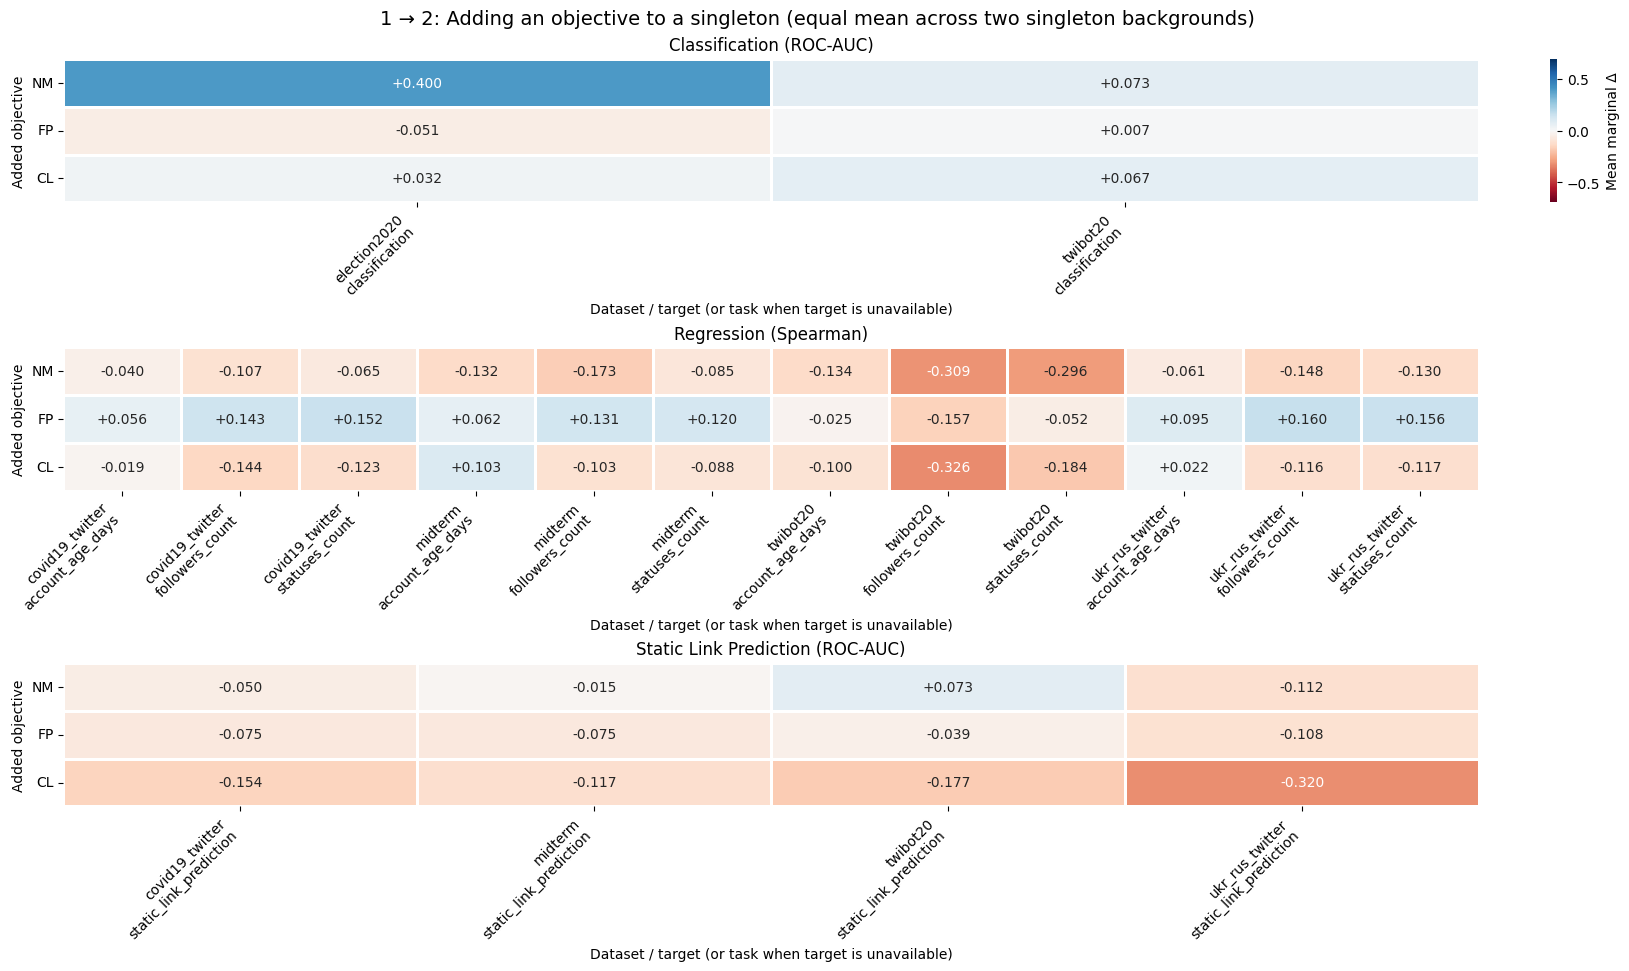

In [664]:
plot_stage("1 → 2")

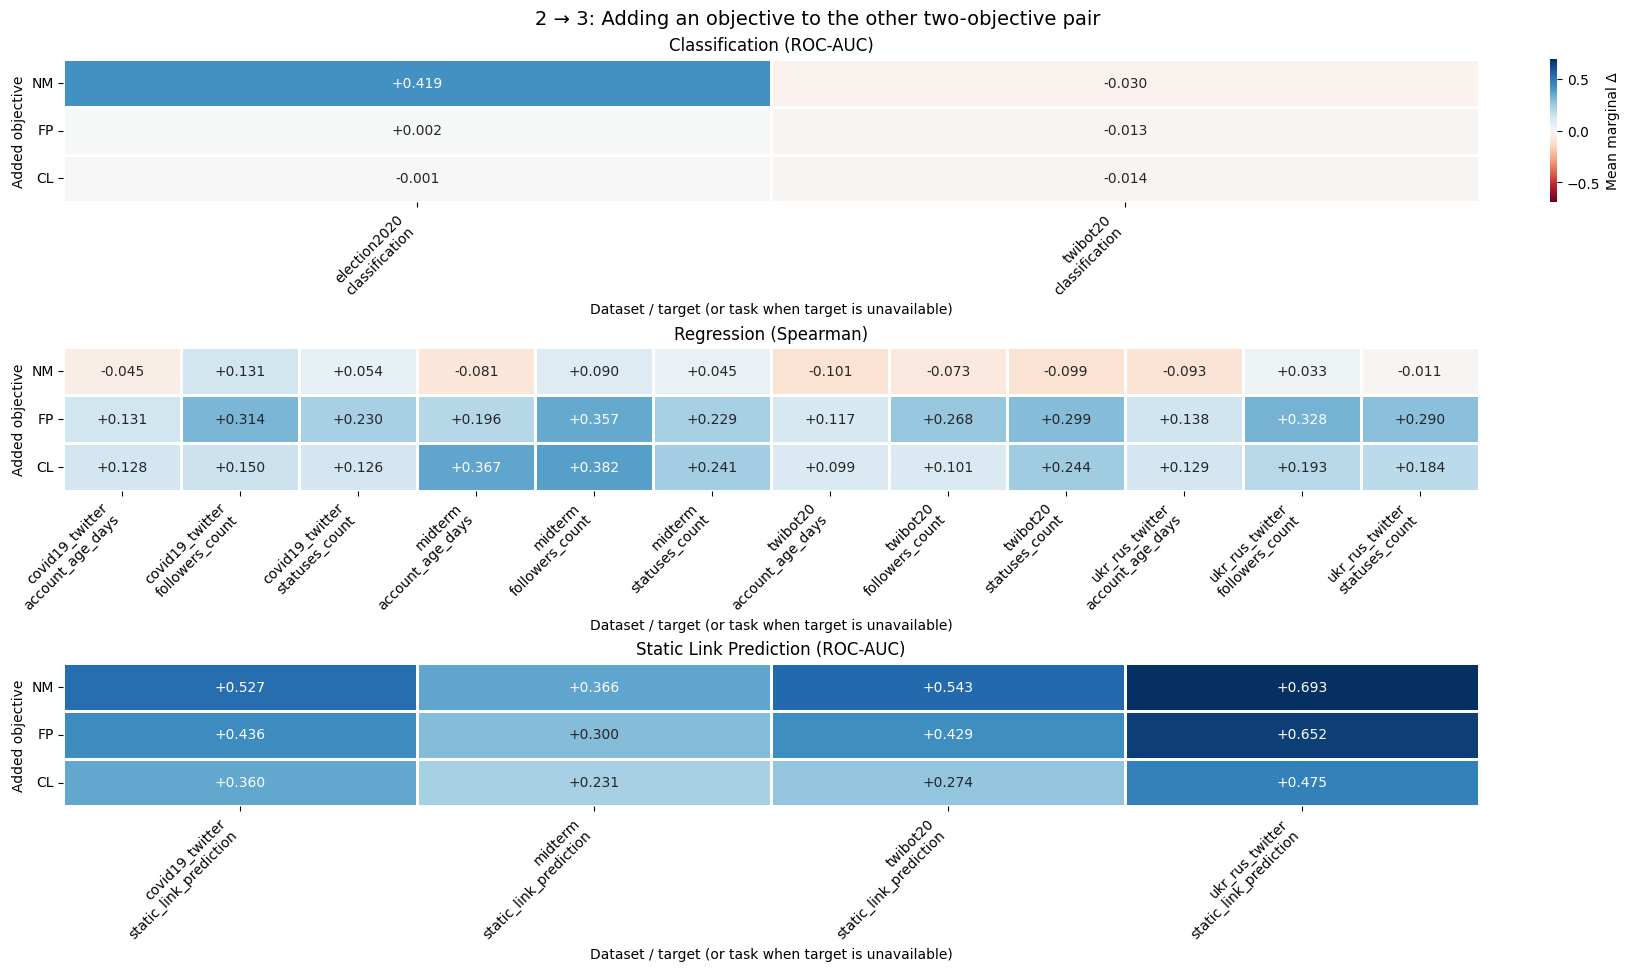

In [667]:
plot_stage("2 → 3")

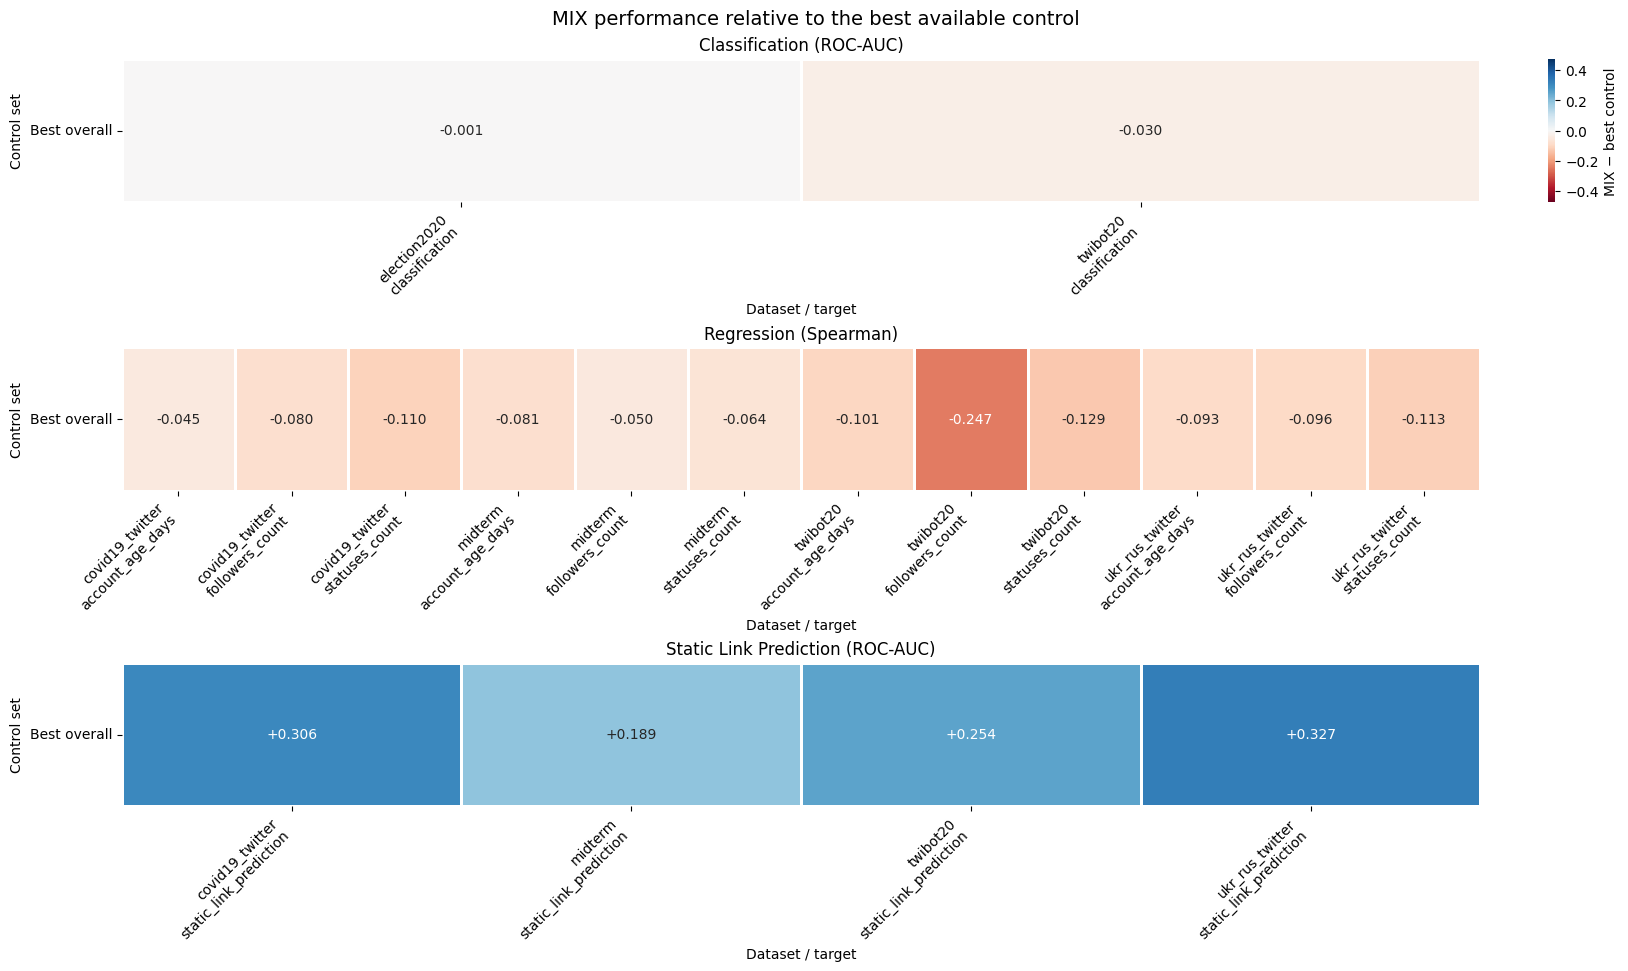

In [669]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

single_models = ["NM", "CL", "FP"]
two_way_models = ["NMCL", "NMFP", "CLFP"]
all_controls = single_models + two_way_models

metric_by_task = {
    "classification": "roc_auc",
    "regression": "spearman",
    "static_link_prediction": "roc_auc",
}

work = df.copy()

# Avoid losing rows with missing targets during grouping/pivoting.
target_text = work["target"].astype("string").str.strip()

missing_target = (
    target_text.isna()
    | target_text.str.lower().isin(
        ["", "na", "n/a", "nan", "none", "null"]
    )
)

work["target_key"] = target_text.mask(
    missing_target,
    "__NO_TARGET__",
)

match_keys = [
    "dataset",
    "target_key",
    "split",
    "shots",
]

mix_best_rows = []

for task, metric in metric_by_task.items():
    task_df = work.loc[
        work["task"].eq(task)
        & work["model"].isin(["MIX"] + all_controls),
        match_keys + ["model", metric],
    ]

    # Average repeated runs within each exact setting.
    scores = (
        task_df
        .groupby(match_keys + ["model"], dropna=False)[metric]
        .mean()
        .rename("score")
        .reset_index()
    )

    wide = scores.pivot(
        index=match_keys,
        columns="model",
        values="score",
    )

    required = ["MIX"] + all_controls

    # Only compare settings where MIX and all controls exist.
    wide = wide.dropna(subset=required).copy()

    wide["best_single_score"] = wide[single_models].max(axis=1)
    wide["best_single_model"] = wide[single_models].idxmax(axis=1)

    wide["best_two_way_score"] = wide[two_way_models].max(axis=1)
    wide["best_two_way_model"] = wide[two_way_models].idxmax(axis=1)

    wide["best_overall_score"] = wide[all_controls].max(axis=1)
    wide["best_overall_model"] = wide[all_controls].idxmax(axis=1)

    wide["MIX_vs_best_single"] = (
        wide["MIX"] - wide["best_single_score"]
    )

    wide["MIX_vs_best_two_way"] = (
        wide["MIX"] - wide["best_two_way_score"]
    )

    wide["MIX_vs_best_overall"] = (
        wide["MIX"] - wide["best_overall_score"]
    )

    wide = wide.reset_index()

    comparisons = {
        "Best singleton": (
            "MIX_vs_best_single",
            "best_single_model",
        ),
        "Best two-way": (
            "MIX_vs_best_two_way",
            "best_two_way_model",
        ),
        "Best overall": (
            "MIX_vs_best_overall",
            "best_overall_model",
        ),
    }

    for comparison, (delta_col, winner_col) in comparisons.items():
        temp = wide[
            match_keys + [delta_col, winner_col]
        ].copy()

        temp = temp.rename(columns={
            delta_col: "delta",
            winner_col: "best_control_model",
        })

        temp["task"] = task
        temp["metric"] = metric
        temp["comparison"] = comparison

        mix_best_rows.append(temp)

mix_vs_best = pd.concat(
    mix_best_rows,
    ignore_index=True,
)

mix_vs_best["target_or_task"] = (
    mix_vs_best["target_key"]
    .replace("__NO_TARGET__", pd.NA)
    .fillna(mix_vs_best["task"])
)

mix_vs_best_cells = (
    mix_vs_best
    .groupby(
        [
            "task",
            "dataset",
            "target_or_task",
            "comparison",
        ],
        dropna=False,
    )
    .agg(
        mean_delta=("delta", "mean"),
        median_delta=("delta", "median"),
        win_rate=("delta", lambda x: (x > 0).mean()),
        n=("delta", "size"),
    )
    .reset_index()
)

comparison_order = [
    # "Best singleton",
    # "Best two-way",
    "Best overall",
]

task_order = [
    task for task in metric_by_task
    if task in mix_vs_best_cells["task"].unique()
]

metric_label = {
    "classification": "ROC-AUC",
    "regression": "Spearman",
    "static_link_prediction": "ROC-AUC",
}

limit = mix_vs_best_cells["mean_delta"].abs().max()

max_columns = (
    mix_vs_best_cells
    .groupby("task")[["dataset", "target_or_task"]]
    .apply(lambda x: len(x.drop_duplicates()))
    .max()
)

fig, axes = plt.subplots(
    nrows=len(task_order),
    ncols=1,
    figsize=(
        max(9, 1.35 * max_columns),
        3.2 * len(task_order),
    ),
    constrained_layout=True,
)

if len(task_order) == 1:
    axes = [axes]

for panel_i, (ax, task) in enumerate(
    zip(axes, task_order)
):
    task_data = mix_vs_best_cells[
        mix_vs_best_cells["task"].eq(task)
    ]

    matrix = (
        task_data
        .pivot(
            index="comparison",
            columns=["dataset", "target_or_task"],
            values="mean_delta",
        )
        .reindex(index=comparison_order)
        .sort_index(axis=1, level=[0, 1])
    )

    labels = [
        f"{dataset}\n{target}"
        for dataset, target in matrix.columns
    ]

    sns.heatmap(
        matrix,
        mask=matrix.isna(),
        annot=True,
        fmt="+.3f",
        cmap="RdBu",
        center=0,
        vmin=-limit,
        vmax=limit,
        linewidths=0.75,
        linecolor="white",
        cbar=panel_i == 0,
        cbar_kws={
            "label": "MIX − best control",
        },
        ax=ax,
    )

    ax.set_title(
        f"{task.replace('_', ' ').title()} "
        f"({metric_label[task]})"
    )
    ax.set_xlabel("Dataset / target")
    ax.set_ylabel("Control set")

    ax.set_xticklabels(
        labels,
        rotation=45,
        ha="right",
    )
    ax.set_yticklabels(
        comparison_order,
        rotation=0,
    )

fig.suptitle(
    "MIX performance relative to the best available control",
    fontsize=14,
)

plt.show()

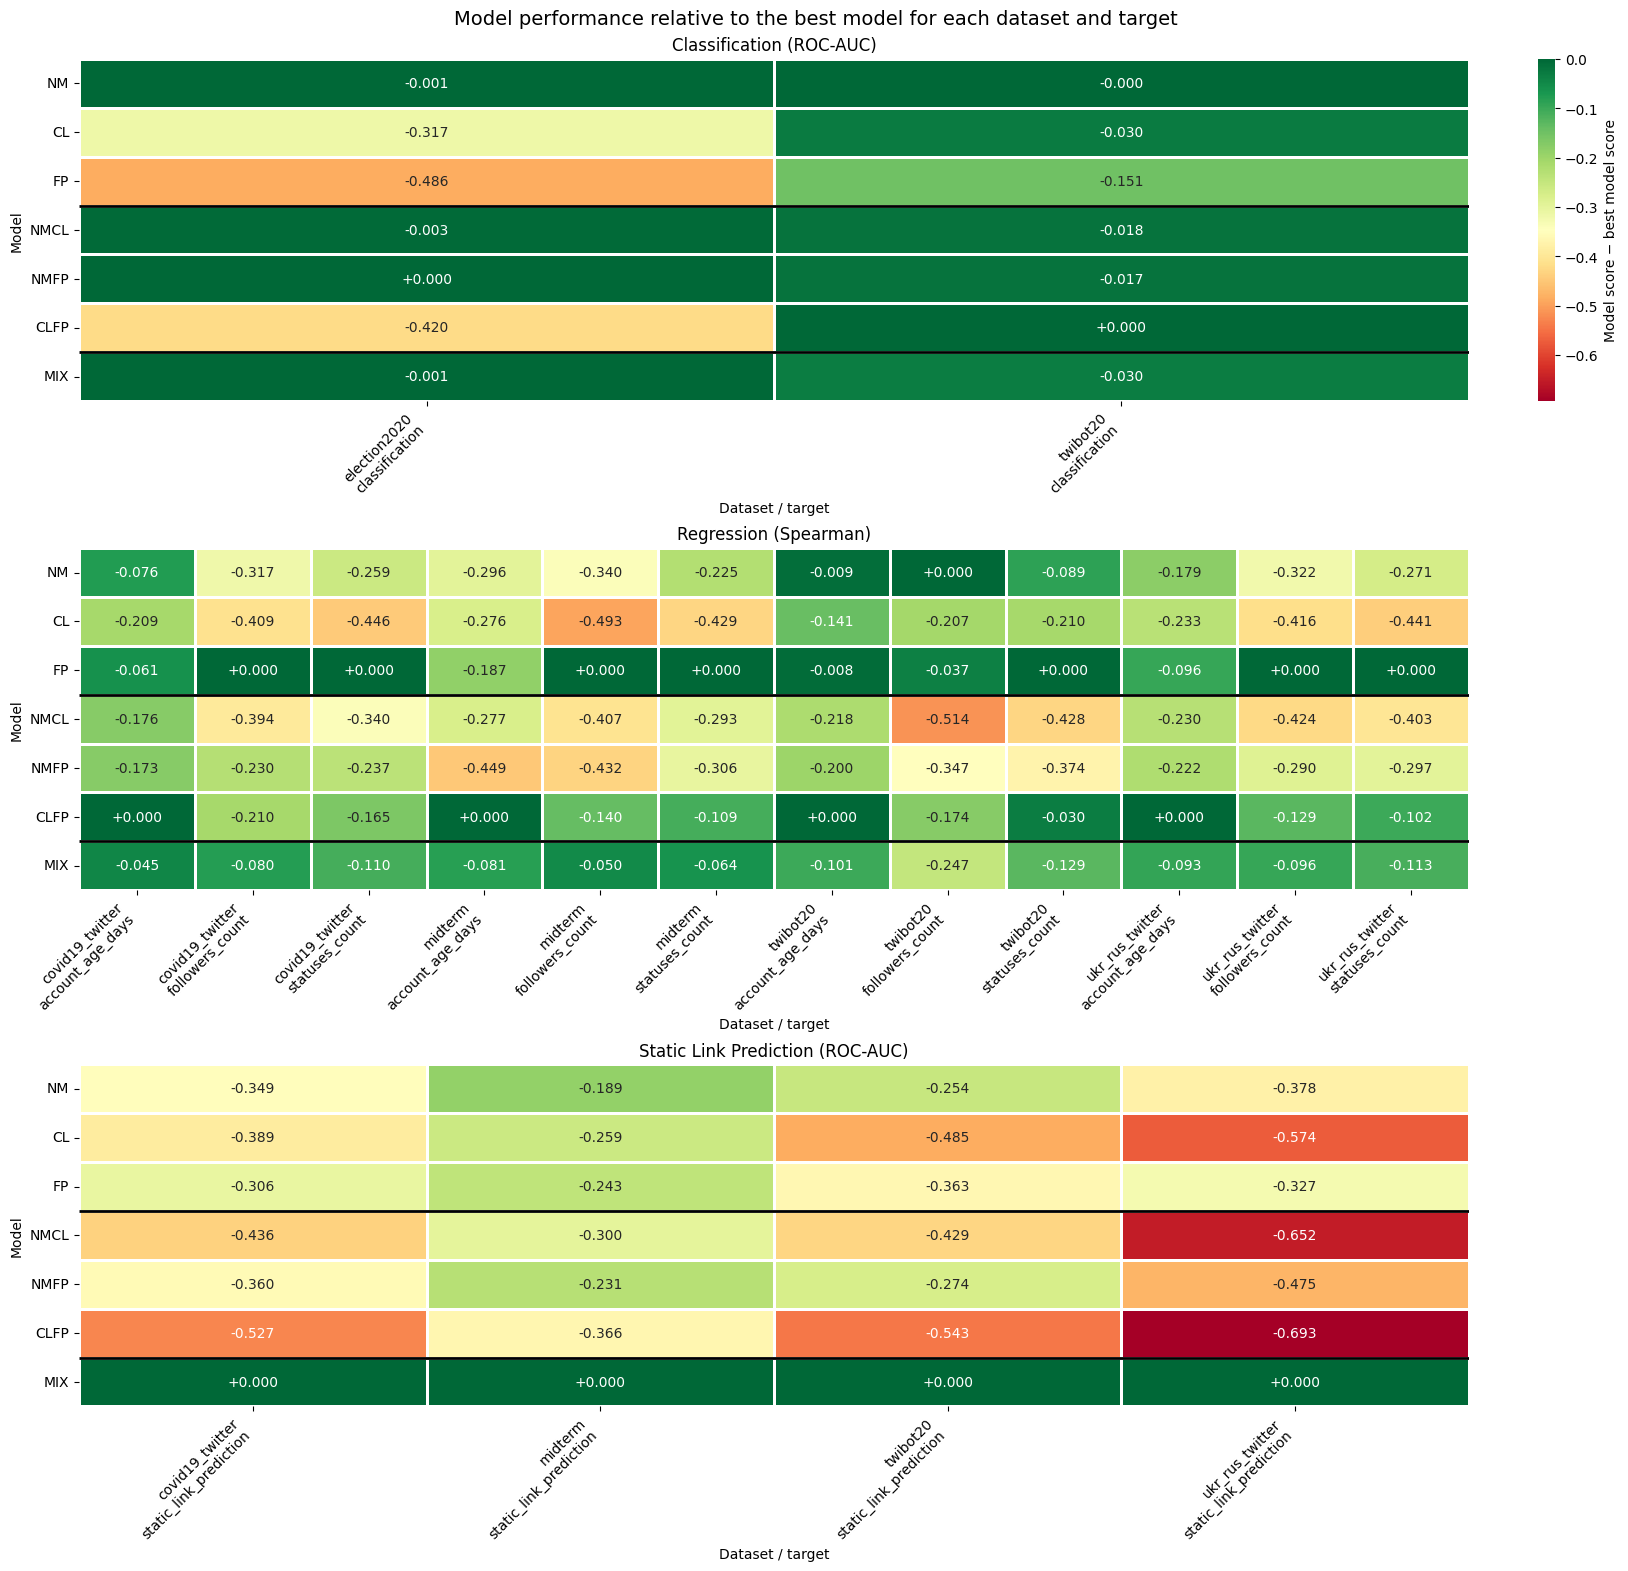

In [671]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = [
    "NM", "CL", "FP",          # 1-way
    "NMCL", "NMFP", "CLFP",    # 2-way
    "MIX",                     # 3-way
]

metric_by_task = {
    "classification": "roc_auc",
    "regression": "spearman",
    "static_link_prediction": "roc_auc",
}

work = df.copy()

# Use target when available; otherwise use task.
target_text = work["target"].astype("string").str.strip()

missing_target = (
    target_text.isna()
    | target_text.str.lower().isin(
        ["", "na", "n/a", "nan", "none", "null"]
    )
)

work["target_or_task"] = target_text.mask(
    missing_target,
    work["task"].astype("string"),
)

model_score_rows = []

for task, metric in metric_by_task.items():
    task_df = work.loc[
        work["task"].eq(task)
        & work["model"].isin(model_order),
        [
            "dataset",
            "target_or_task",
            "split",
            "shots",
            "model",
            metric,
        ],
    ].copy()

    # First average repeated runs within the exact evaluation condition.
    condition_scores = (
        task_df
        .groupby(
            [
                "dataset",
                "target_or_task",
                "split",
                "shots",
                "model",
            ],
            dropna=False,
        )[metric]
        .mean()
        .rename("score")
        .reset_index()
    )

    # Then average conditions for each dataset/target/model.
    model_scores = (
        condition_scores
        .groupby(
            [
                "dataset",
                "target_or_task",
                "model",
            ],
            dropna=False,
        )["score"]
        .mean()
        .reset_index()
    )

    model_scores["task"] = task
    model_scores["metric"] = metric

    model_score_rows.append(model_scores)

model_scores = pd.concat(
    model_score_rows,
    ignore_index=True,
)

group_keys = [
    "task",
    "dataset",
    "target_or_task",
]

# Best score for every dataset/target.
model_scores["best_score"] = (
    model_scores
    .groupby(group_keys)["score"]
    .transform("max")
)

# Model score minus best score.
model_scores["delta_to_best"] = (
    model_scores["score"]
    - model_scores["best_score"]
)

# Record which model is best.
best_rows = (
    model_scores.loc[
        model_scores
        .groupby(group_keys)["score"]
        .idxmax(),
        group_keys + ["model", "score"],
    ]
    .rename(columns={
        "model": "best_model",
        "score": "best_score_check",
    })
)

model_scores = model_scores.merge(
    best_rows[group_keys + ["best_model"]],
    on=group_keys,
    how="left",
)

task_order = [
    task for task in metric_by_task
    if task in model_scores["task"].unique()
]

metric_label = {
    "classification": "ROC-AUC",
    "regression": "Spearman",
    "static_link_prediction": "ROC-AUC",
}

# Shared scale; zero is always the best model.
global_min = model_scores["delta_to_best"].min()

max_columns = (
    model_scores
    .groupby("task")[["dataset", "target_or_task"]]
    .apply(lambda x: len(x.drop_duplicates()))
    .max()
)

fig, axes = plt.subplots(
    nrows=len(task_order),
    ncols=1,
    figsize=(
        max(9, 1.35 * max_columns),
        5.2 * len(task_order),
    ),
    constrained_layout=True,
)

if len(task_order) == 1:
    axes = [axes]

for panel_i, (ax, task) in enumerate(
    zip(axes, task_order)
):
    task_data = model_scores[
        model_scores["task"].eq(task)
    ]

    matrix = (
        task_data
        .pivot(
            index="model",
            columns=["dataset", "target_or_task"],
            values="delta_to_best",
        )
        .reindex(index=model_order)
        .sort_index(axis=1, level=[0, 1])
    )

    labels = [
        f"{dataset}\n{target}"
        for dataset, target in matrix.columns
    ]

    sns.heatmap(
        matrix,
        mask=matrix.isna(),
        annot=True,
        fmt="+.3f",
        cmap="RdYlGn",
        vmin=global_min,
        vmax=0,
        linewidths=0.75,
        linecolor="white",
        cbar=panel_i == 0,
        cbar_kws={
            "label": "Model score − best model score",
        },
        ax=ax,
    )

    # Separate 1-way, 2-way, and 3-way models.
    ax.hlines(
        [3, 6],
        xmin=0,
        xmax=matrix.shape[1],
        colors="black",
        linewidths=2,
    )

    ax.set_title(
        f"{task.replace('_', ' ').title()} "
        f"({metric_label[task]})"
    )
    ax.set_xlabel("Dataset / target")
    ax.set_ylabel("Model")

    ax.set_xticklabels(
        labels,
        rotation=45,
        ha="right",
    )
    ax.set_yticklabels(
        model_order,
        rotation=0,
    )

fig.suptitle(
    "Model performance relative to the best model "
    "for each dataset and target",
    fontsize=14,
)

plt.show()

Best model per task:


,best_model,best_score,dataset_target_cells
classification,NM,0.810105,2
regression,FP,0.165625,12
static_link_prediction,MIX,0.759268,4


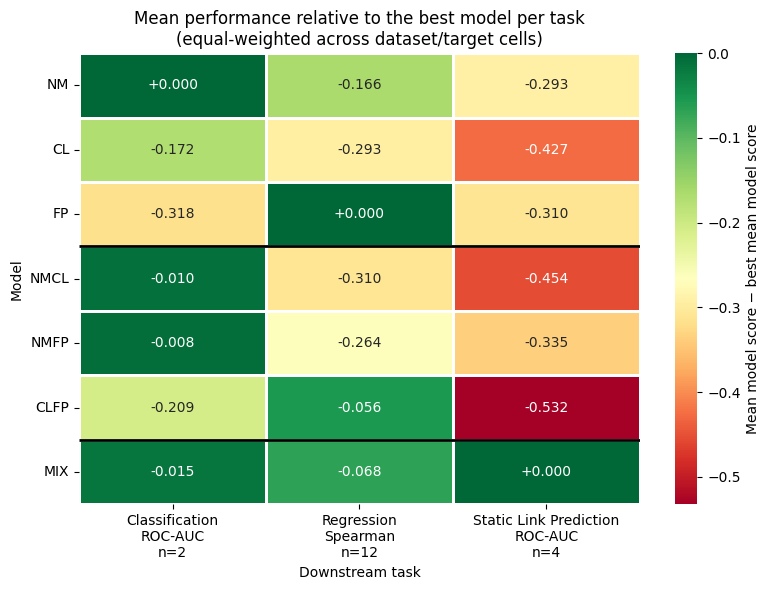

In [672]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = [
    "NM", "CL", "FP",          # 1-way
    "NMCL", "NMFP", "CLFP",    # 2-way
    "MIX",                     # 3-way
]

task_order = [
    task for task in [
        "classification",
        "regression",
        "static_link_prediction",
    ]
    if task in model_scores["task"].unique()
]

metric_label = {
    "classification": "ROC-AUC",
    "regression": "Spearman",
    "static_link_prediction": "ROC-AUC",
}

task_mean_scores = {}
n_dataset_targets = {}

for task in task_order:
    task_data = model_scores[
        model_scores["task"].eq(task)
    ]

    # Rows: models
    # Columns: dataset/target evaluation cells
    task_matrix = (
        task_data
        .pivot(
            index="model",
            columns=["dataset", "target_or_task"],
            values="score",
        )
        .reindex(index=model_order)
    )

    # Keep only dataset/target cells available for every model.
    # This ensures models are averaged over identical evaluations.
    complete_matrix = task_matrix.dropna(
        axis=1,
        how="any",
    )

    if complete_matrix.shape[1] == 0:
        raise ValueError(
            f"No complete dataset/target comparisons for {task}"
        )

    # Each dataset/target cell receives equal weight.
    task_mean_scores[task] = complete_matrix.mean(axis=1)
    n_dataset_targets[task] = complete_matrix.shape[1]

mean_score_by_task = pd.DataFrame(
    task_mean_scores,
    index=model_order,
)

mean_score_by_task.index.name = "Model"

best_score_by_task = mean_score_by_task.max(axis=0)

delta_to_best_by_task = (
    mean_score_by_task
    - best_score_by_task
)

best_model_by_task = mean_score_by_task.idxmax(axis=0)

print("Best model per task:")
display(
    pd.DataFrame({
        "best_model": best_model_by_task,
        "best_score": best_score_by_task,
        "dataset_target_cells": pd.Series(n_dataset_targets),
    })
)

global_min = delta_to_best_by_task.min().min()

column_labels = [
    (
        f"{task.replace('_', ' ').title()}\n"
        f"{metric_label[task]}\n"
        f"n={n_dataset_targets[task]}"
    )
    for task in task_order
]

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    delta_to_best_by_task,
    mask=delta_to_best_by_task.isna(),
    annot=True,
    fmt="+.3f",
    cmap="RdYlGn",
    vmin=global_min,
    vmax=0,
    linewidths=0.75,
    linecolor="white",
    cbar_kws={
        "label": "Mean model score − best mean model score",
    },
    ax=ax,
)

# Separate 1-way, 2-way, and 3-way models.
ax.hlines(
    [3, 6],
    xmin=0,
    xmax=len(task_order),
    colors="black",
    linewidths=2,
)

ax.set_title(
    "Mean performance relative to the best model per task\n"
    "(equal-weighted across dataset/target cells)"
)
ax.set_xlabel("Downstream task")
ax.set_ylabel("Model")

ax.set_xticklabels(
    column_labels,
    rotation=0,
)
ax.set_yticklabels(
    model_order,
    rotation=0,
)

plt.tight_layout()
plt.show()

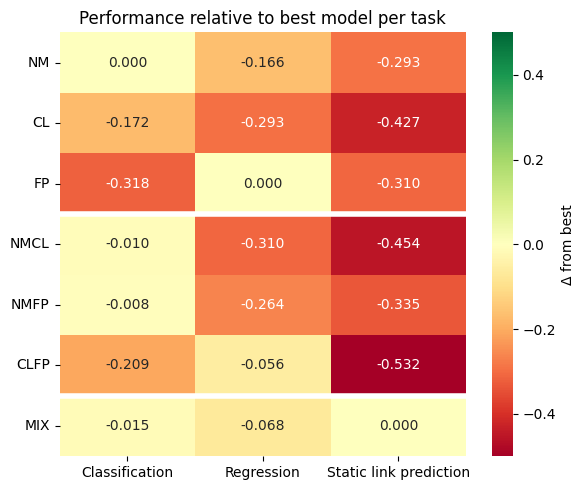

In [687]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

models = ["NM", "CL", "FP", "NMCL", "NMFP", "CLFP", "MIX"]

metric_by_task = {
    "classification": "roc_auc",
    "regression": "spearman",
    "static_link_prediction": "roc_auc",
}

means = {}

for task, metric in metric_by_task.items():
    x = df[df["task"].eq(task)].copy()

    target = x["target"].astype("string").str.strip()
    missing = target.isna() | target.str.lower().isin(
        ["", "na", "n/a", "nan", "none", "null"]
    )
    x["target_or_task"] = target.mask(missing, task)

    # One score per dataset × target × model.
    cells = (
        x.groupby(
            ["dataset", "target_or_task", "model"],
            dropna=False,
        )[metric]
        .mean()
        .unstack("model")
        .reindex(columns=models)
        .dropna()  # retain cells available for every model
    )

    # Equal weight for every dataset × target cell.
    means[task] = cells.mean(axis=0)

mean_scores = pd.DataFrame(means).reindex(models)

# Average scores first, then compare with the best task-level mean.
delta = mean_scores - mean_scores.max(axis=0)

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    delta,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    vmin=-0.5,
    vmax=0.5,
    # linewidths=.5,
    cbar_kws={"label": "Δ from best"},
    ax=ax,
)

ax.hlines([3, 6], 0, delta.shape[1], color="white", linewidth=4)
ax.set(xlabel="", ylabel="", title="Performance relative to best model per task")
ax.set_xticklabels(
    ["Classification", "Regression", "Static link prediction"],
    rotation=0,
)
ax.set_yticklabels(models, rotation=0)

plt.tight_layout()
plt.show()

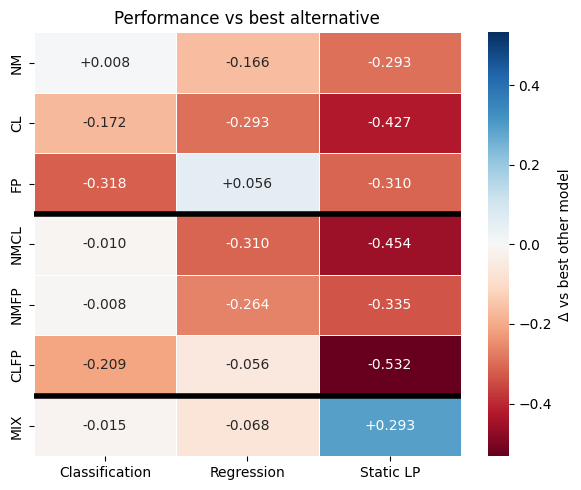

In [699]:
# mean_scores: rows=models, columns=tasks
# Created by the previous aggregation code.

delta = mean_scores.copy()
best_competitor = mean_scores.copy().astype(object)

for task in mean_scores.columns:
    for model in mean_scores.index:
        others = mean_scores[task].drop(model)

        competitor = others.idxmax()
        competitor_score = others.max()

        delta.loc[model, task] = (
            mean_scores.loc[model, task] - competitor_score
        )
        best_competitor.loc[model, task] = competitor
        
import seaborn as sns
import matplotlib.pyplot as plt

limit = delta.abs().max().max()

plt.figure(figsize=(6, 5))

sns.heatmap(
    delta,
    annot=True,
    fmt="+.3f",
    cmap="RdBu",
    center=0,
    vmin=-limit,
    vmax=limit,
    linewidths=.5,
    cbar_kws={"label": "Δ vs best other model"},
)

plt.hlines([3, 6], 0, delta.shape[1], color="black", linewidth=4)

plt.xlabel("")
plt.ylabel("")
plt.title("Performance vs best alternative")
plt.xticks(
    ticks=[.5, 1.5, 2.5],
    labels=["Classification", "Regression", "Static LP"],
    rotation=0,
)
plt.tight_layout()
plt.show()

In [710]:
import itertools
import numpy as np
import pandas as pd
from IPython.display import display

objectives = ["NM", "CL", "FP"]

model_for_objectives = {
    frozenset(["NM"]): "NM",
    frozenset(["CL"]): "CL",
    frozenset(["FP"]): "FP",
    frozenset(["NM", "CL"]): "NMCL",
    frozenset(["NM", "FP"]): "NMFP",
    frozenset(["CL", "FP"]): "CLFP",
    frozenset(["NM", "CL", "FP"]): "MIX",
}

task_order = [
    "classification",
    "regression",
    "static_link_prediction",
]

match_keys = [
    "dataset",
    "target",
    "split",
    "shots",
]

rank_rows = []

for task in task_order:
    task_df = df.loc[
        df["task"].eq(task),
        match_keys + ["model", "rank"],
    ].copy()

    # Average repeated-run ranks within the same condition.
    ranks = (
        task_df
        .groupby(match_keys + ["model"], dropna=False)["rank"]
        .mean()
        .rename("rank")
        .reset_index()
        .dropna(subset=["rank"])
    )

    for added_objective in objectives:
        remaining = [
            obj for obj in objectives
            if obj != added_objective
        ]

        backgrounds = (
            [frozenset(x) for x in itertools.combinations(remaining, 1)]
            + [frozenset(remaining)]
        )

        for background in backgrounds:
            treatment_set = background | {added_objective}

            control_model = model_for_objectives[background]
            treatment_model = model_for_objectives[treatment_set]

            control = (
                ranks.loc[
                    ranks["model"].eq(control_model),
                    match_keys + ["rank"],
                ]
                .rename(columns={"rank": "control_rank"})
            )

            treatment = (
                ranks.loc[
                    ranks["model"].eq(treatment_model),
                    match_keys + ["rank"],
                ]
                .rename(columns={"rank": "treatment_rank"})
            )

            matched = control.merge(
                treatment,
                on=match_keys,
                how="inner",
                validate="one_to_one",
            )

            # Positive means the treatment has a better/lower rank.
            matched["rank_improvement"] = (
                matched["control_rank"]
                - matched["treatment_rank"]
            )

            rank_rows.append({
                "task": task,
                "added_objective": added_objective,
                "background": "+".join(
                    obj for obj in objectives
                    if obj in background
                ),
                "control_model": control_model,
                "treatment_model": treatment_model,
                "stage": f"{len(background)} → {len(treatment_set)}",
                "mean_control_rank": matched["control_rank"].mean(),
                "mean_treatment_rank": matched["treatment_rank"].mean(),
                "mean_rank_improvement": (
                    matched["rank_improvement"].mean()
                ),
                "rank_win_rate": (
                    matched["rank_improvement"] > 0
                ).mean(),
                "n": len(matched),
            })

rank_transitions = pd.DataFrame(rank_rows)

rank_summary = (
    rank_transitions
    .groupby(["added_objective", "task"])
    .agg(
        mean_rank_improvement=(
            "mean_rank_improvement",
            "mean",
        ),
        median_background_improvement=(
            "mean_rank_improvement",
            "median",
        ),
        positive_backgrounds=(
            "mean_rank_improvement",
            lambda x: (x > 0).sum(),
        ),
        background_win_rate=(
            "mean_rank_improvement",
            lambda x: (x > 0).mean(),
        ),
        n_matched=("n", "sum"),
    )
    .reset_index()
)

rank_matrix = (
    rank_summary
    .pivot(
        index="added_objective",
        columns="task",
        values="mean_rank_improvement",
    )
    .reindex(
        index=["NM", "FP", "CL"],
        columns=task_order,
    )
)

rank_matrix.index.name = "Added objective"
rank_matrix.columns.name = "Downstream task"

limit = np.nanmax(
    np.abs(rank_matrix.to_numpy(dtype=float))
)

display(
    rank_matrix.style
    .format("{:+.2f}", na_rep="—")
    .background_gradient(
        cmap="RdBu",
        vmin=-limit,
        vmax=limit,
        axis=None,
    )
    .set_caption(
        "Mean rank improvement from adding each objective "
        "(equal-weighted across backgrounds)"
    )
)

Downstream task,classification,regression,static_link_prediction
Added objective,,,
NM,+1.83,-1.39,+1.67
FP,+0.67,+2.00,+0.67
CL,+0.00,+0.03,-1.58


In [711]:
import numpy as np
import pandas as pd
from IPython.display import display

single_models = ["NM", "CL", "FP"]
two_way_models = ["NMCL", "NMFP", "CLFP"]

# Rows: two- and three-objective models.
evaluated_models = two_way_models + ["MIX"]

# Columns: one- and two-objective controls.
control_models = single_models + two_way_models

task_order = [
    "classification",
    "regression",
    "static_link_prediction",
]

match_keys = [
    "dataset",
    "target",
    "split",
    "shots",
]

rank_effect_rows = []

for task in task_order:
    task_df = df.loc[
        df["task"].eq(task)
        & df["model"].isin(
            list(set(evaluated_models + control_models))
        ),
        match_keys + ["model", "rank"],
    ].copy()

    # Average repeated-run ranks within each condition.
    ranks = (
        task_df
        .groupby(match_keys + ["model"], dropna=False)["rank"]
        .mean()
        .rename("rank")
        .reset_index()
        .dropna(subset=["rank"])
    )

    for evaluated_model in evaluated_models:
        evaluated = (
            ranks.loc[
                ranks["model"].eq(evaluated_model),
                match_keys + ["rank"],
            ]
            .rename(columns={"rank": "evaluated_rank"})
        )

        for control_model in control_models:
            # Leave self-comparisons empty.
            if evaluated_model == control_model:
                continue

            control = (
                ranks.loc[
                    ranks["model"].eq(control_model),
                    match_keys + ["rank"],
                ]
                .rename(columns={"rank": "control_rank"})
            )

            matched = evaluated.merge(
                control,
                on=match_keys,
                how="inner",
                validate="one_to_one",
            )

            # Positive = row model has a better/lower rank.
            matched["rank_improvement"] = (
                matched["control_rank"]
                - matched["evaluated_rank"]
            )

            rank_effect_rows.append({
                "task": task,
                "evaluated_model": evaluated_model,
                "control_model": control_model,
                "mean_evaluated_rank": (
                    matched["evaluated_rank"].mean()
                ),
                "mean_control_rank": (
                    matched["control_rank"].mean()
                ),
                "mean_rank_improvement": (
                    matched["rank_improvement"].mean()
                ),
                "median_rank_improvement": (
                    matched["rank_improvement"].median()
                ),
                "rank_win_rate": (
                    matched["rank_improvement"] > 0
                ).mean(),
                "n": len(matched),
            })

rank_effects = pd.DataFrame(rank_effect_rows)

column_order = pd.MultiIndex.from_product(
    [task_order, control_models],
    names=["Task", "Control model"],
)

rank_delta_table = (
    rank_effects.pivot(
        index="evaluated_model",
        columns=["task", "control_model"],
        values="mean_rank_improvement",
    )
    .reindex(
        index=evaluated_models,
        columns=column_order,
    )
)

rank_delta_table.index.name = "Evaluated model"

values = rank_delta_table.to_numpy(dtype=float)
limit = np.nanmax(np.abs(values))

styled_rank_table = (
    rank_delta_table.style
    .format("{:+.2f}", na_rep="—")
    .background_gradient(
        cmap="RdBu",   # blue = rank improvement
        vmin=-limit,
        vmax=limit,
        axis=None,
    )
    .set_caption(
        "Mean matched rank improvement: "
        "control rank − evaluated-model rank"
    )
    .set_properties(**{
        "text-align": "center",
    })
)

display(styled_rank_table)

rank_n_table = (
    rank_effects.pivot(
        index="evaluated_model",
        columns=["task", "control_model"],
        values="n",
    )
    .reindex(
        index=evaluated_models,
        columns=column_order,
    )
)

display(
    rank_n_table.style
    .format("{:.0f}", na_rep="—")
    .set_caption("Number of matched evaluation settings")
)

In [724]:
rank_delta_table.loc['MIX'].unstack().T.loc[['CL', 'FP', 'NM']].mean(1)

/var/folders/6w/cs8z0j913k1d_x_ywtvrm5xc0000gp/T/ipykernel_15005/2659274728.py:1: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  rank_delta_table.loc['MIX'].unstack().T.loc[['CL', 'FP', 'NM']].mean(1)


Control model
CL    2.888889
FP    1.333333
NM    0.444444
dtype: float64

In [775]:
d = df.groupby(['model', 'task'])['rank'].mean().unstack()
d['mean'] = d.mean(1)
d = d.sort_values('mean', ascending=False)
d['mean']

/var/folders/6w/cs8z0j913k1d_x_ywtvrm5xc0000gp/T/ipykernel_15005/3283343661.py:2: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  d['mean'] = d.mean(1)


model
CL      5.444444
NMCL    5.277778
CLFP    4.222222
FP      3.888889
NMFP    3.611111
NM      3.000000
MIX     2.555556
Name: mean, dtype: float64

Text(0.5, 1.0, 'Static Link Prediction')

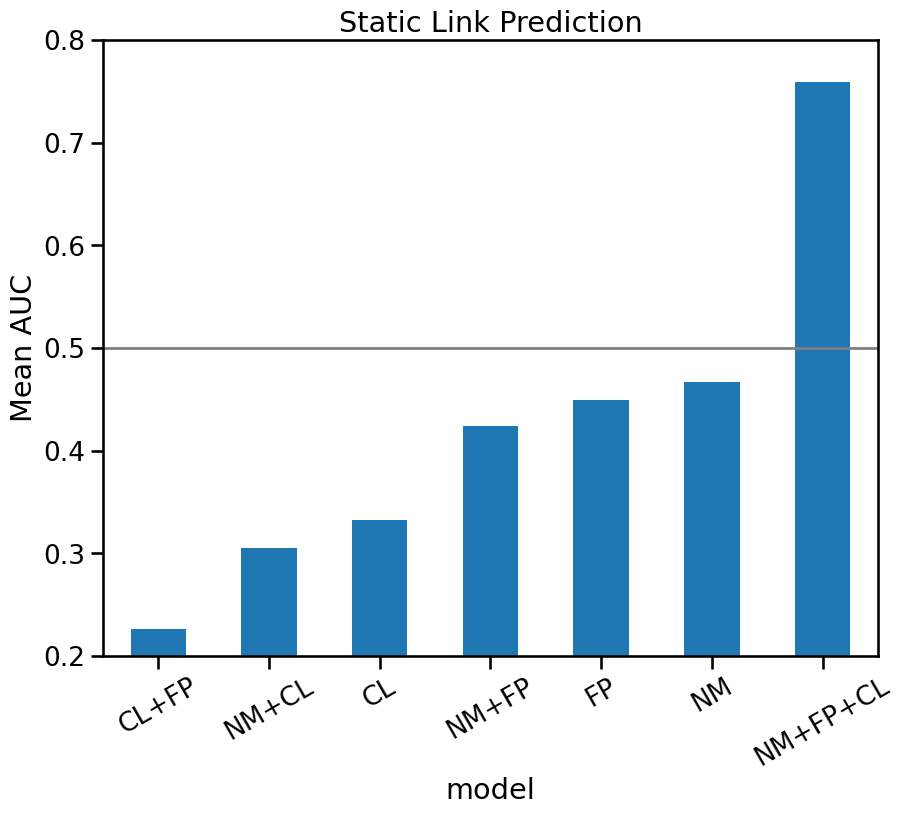

In [1020]:
plt.plot(
    [-1, 8],  # x coordinates
    [0.5, 0.5],  # y coordinates
    color="grey",
    linewidth=2,
)
plt.ylim(0.2,0.8)
# plt.show()
df[df.task.eq('static_link_prediction')].replace({'NMCL': 'NM+CL', 'NMFP': 'NM+FP', 'CLFP': 'CL+FP', "MIX": "NM+FP+CL"}).groupby(['model'])['roc_auc'].mean().sort_values().plot.bar(figsize=(10,8), rot=30)
plt.ylabel('Mean AUC')
plt.title('Static Link Prediction')

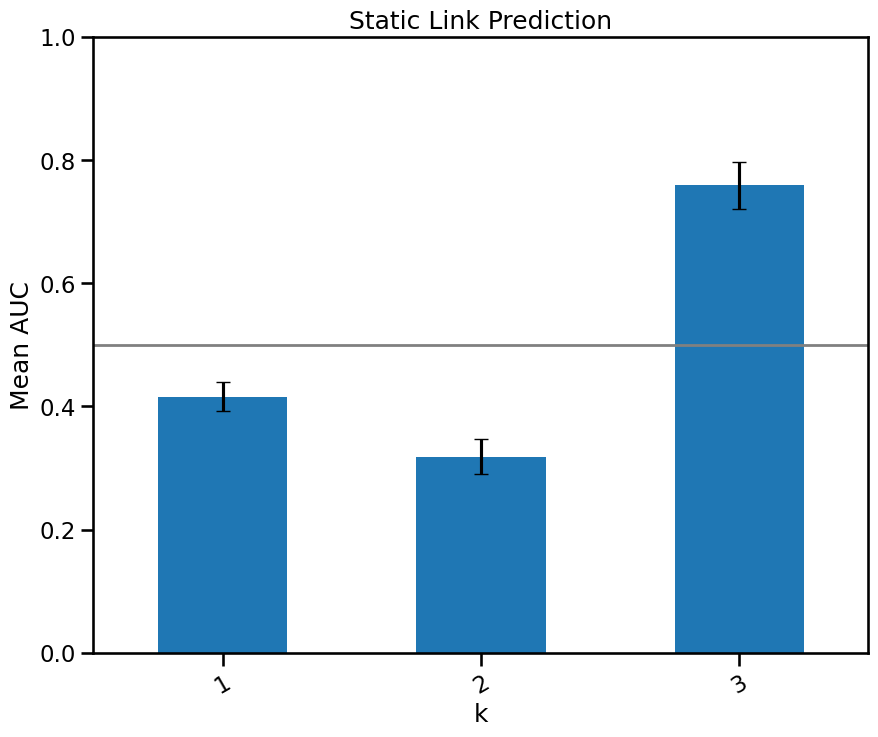

In [ ]:
plt.plot(
    [-1, 8],  # x coordinates
    [0.5, 0.5],  # y coordinates
    color="grey",
    linewidth=2,
)
# t = (
#     df[df.task.eq("static_link_prediction")]
#     .groupby("k")["roc_auc"]
#     .agg(["mean", "std"])
# )

# t["mean"].plot.bar(
#     yerr=t["std"],
#     capsize=5,
#     figsize=(10, 8),
#     rot=30,
# )

plt.ylabel("Mean AUC")
plt.title("Static Link Prediction")
# plt.show()

t = (
    df[df.task.eq("static_link_prediction")]
    .groupby("k")["roc_auc"]
    .agg(["mean", "std", "count", 'min', 'max'])
)

t["sem"] = t["std"] / np.sqrt(t["count"])

t["mean"].plot.bar(
    yerr=t["sem"],
    capsize=5,
    figsize=(10, 8),
    rot=30,
)

plt.ylim(0,1)

sns.set_context("talk", font_scale=1)

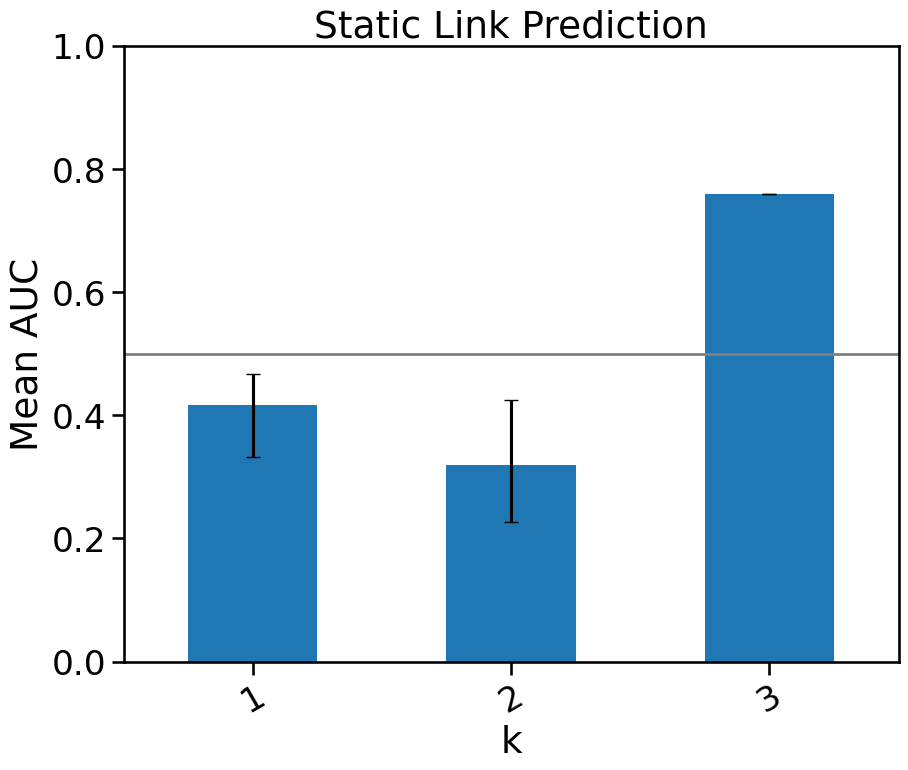

In [1135]:
sns.set_context("talk", font_scale=1.5)


import numpy as np

plt.plot(
    [-1, 8],  # x coordinates
    [0.5, 0.5],  # y coordinates
    color="grey",
    linewidth=2,
)

model_auc = (
    df[df.task.eq("static_link_prediction")]
    .groupby(["k", "model"])["roc_auc"]
    .mean()
    .reset_index()
)

t = (
    model_auc.groupby("k")["roc_auc"]
    .agg(["mean", "min", "max"])
)

errors = np.vstack([
    t["mean"] - t["min"],
    t["max"] - t["mean"],
])

t["mean"].plot.bar(
    yerr=errors,
    capsize=5,
    figsize=(10, 8),
    rot=30,
)

plt.ylabel("Mean AUC")
plt.title("Static Link Prediction")
plt.ylim(0,1)
plt.show()

sns.set_context("talk", font_scale=1)


In [1166]:
# df['task_rank'] = 
df.groupby(['model', 'task', 'target'])['rank'].mean().groupby(['model', 'task']).mean().groupby('model').mean()

model
CL          5.444444
CL+FP       4.222222
FP          3.888889
NM          3.000000
NM+CL       5.277778
NM+FP       3.611111
NM+FP+CL    2.555556
Name: rank, dtype: float64

Text(0.5, 1.0, 'Mean Rank')

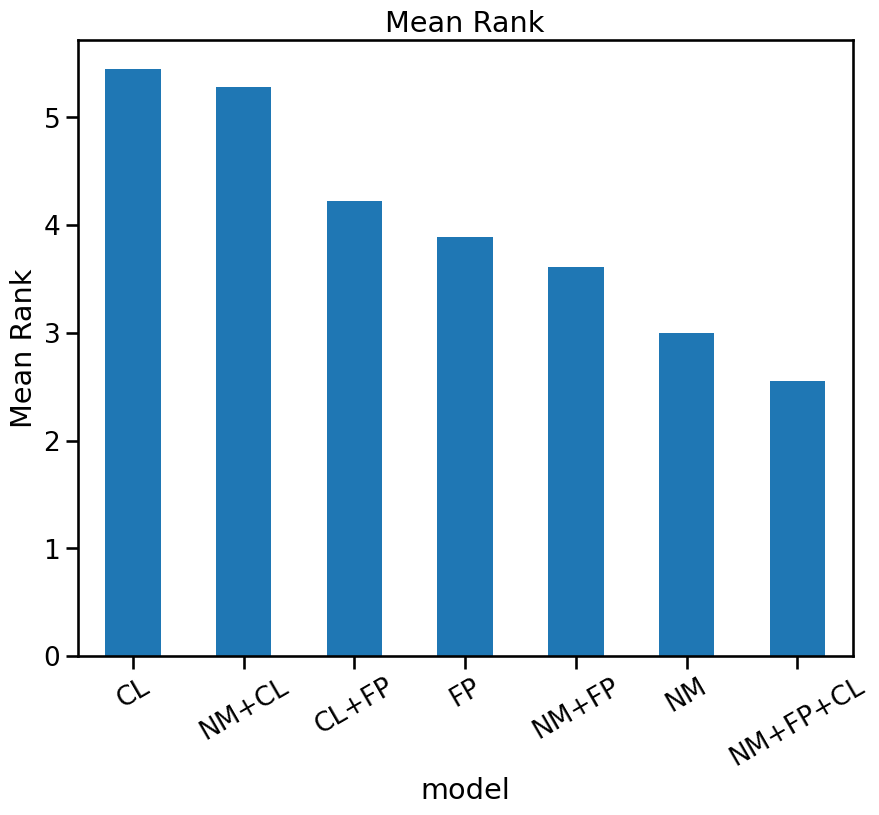

In [1033]:
# plt.plot(
#     [-1, 8],  # x coordinates
#     [0.5, 0.5],  # y coordinates
#     color="grey",
#     linewidth=2,
# )
# plt.ylim(0.2,0.8)
# plt.show()
df.replace({'NMCL': 'NM+CL', 'NMFP': 'NM+FP', 'CLFP': 'CL+FP', "MIX": "NM+FP+CL"}).groupby(['model', 'task'])['rank'].mean().groupby(['model']).mean().sort_values(ascending=False).plot.bar(figsize=(10,8), rot=30)
plt.ylabel('Mean Rank')
plt.title('Mean Rank')

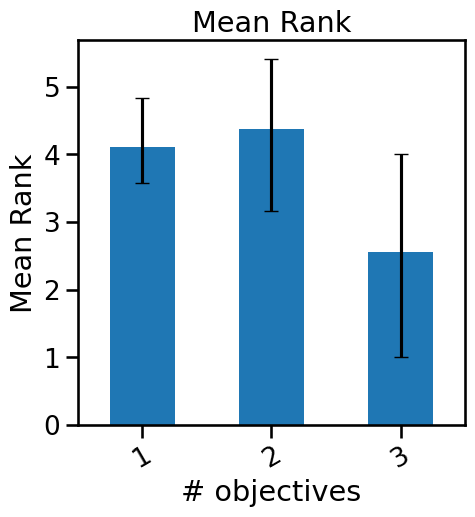

In [1167]:
sns.set_context("talk", font_scale=1.15)


# plt.plot(
#     [-1, 8],  # x coordinates
#     [0.5, 0.5],  # y coordinates
#     color="grey",
#     linewidth=2,
# )
# plt.ylim(0.2,0.8)
# plt.show()
# df.replace({'NMCL': 'NM+CL', 'NMFP': 'NM+FP', 'CLFP': 'CL+FP', "MIX": "NM+FP+CL"}).groupby(['k', 'task'])['rank'].mean().groupby(['k']).mean().plot.bar(figsize=(5,5), rot=30)
# plt.ylabel('Mean Rank')
# plt.title('Mean Rank')

import numpy as np

task_rank = (
    df.groupby(["k", "task"])["rank"]
    .mean()
    .reset_index()
)

t = (
    task_rank.groupby("k")["rank"]
    .agg(["mean", "min", "max"])
)

errors = np.vstack([
    t["mean"] - t["min"],
    t["max"] - t["mean"],
])

t["mean"].plot.bar(
    yerr=errors,
    capsize=5,
    figsize=(5, 5),
    rot=30,
)

plt.xlabel("# objectives")
plt.ylabel("Mean Rank")
plt.title("Mean Rank")
plt.show()

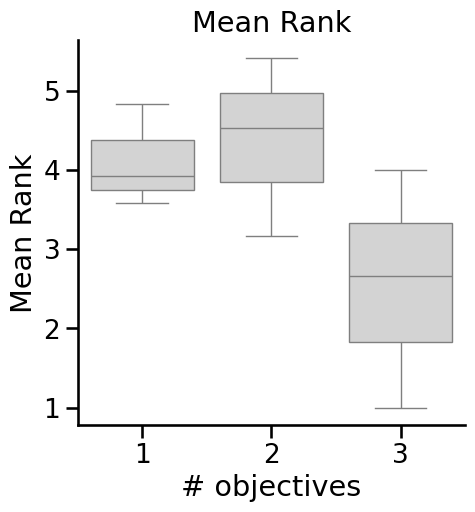

In [1168]:
task_rank = (
    df.groupby(["k", "task"])["rank"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(5, 5))

sns.boxplot(
    data=task_rank,
    x="k",
    y="rank",
    whis=(0, 100),  # whiskers span min–max
    color="lightgray",
)

plt.xlabel("# objectives")
plt.ylabel("Mean Rank")
plt.title("Mean Rank")
sns.despine()
plt.show()

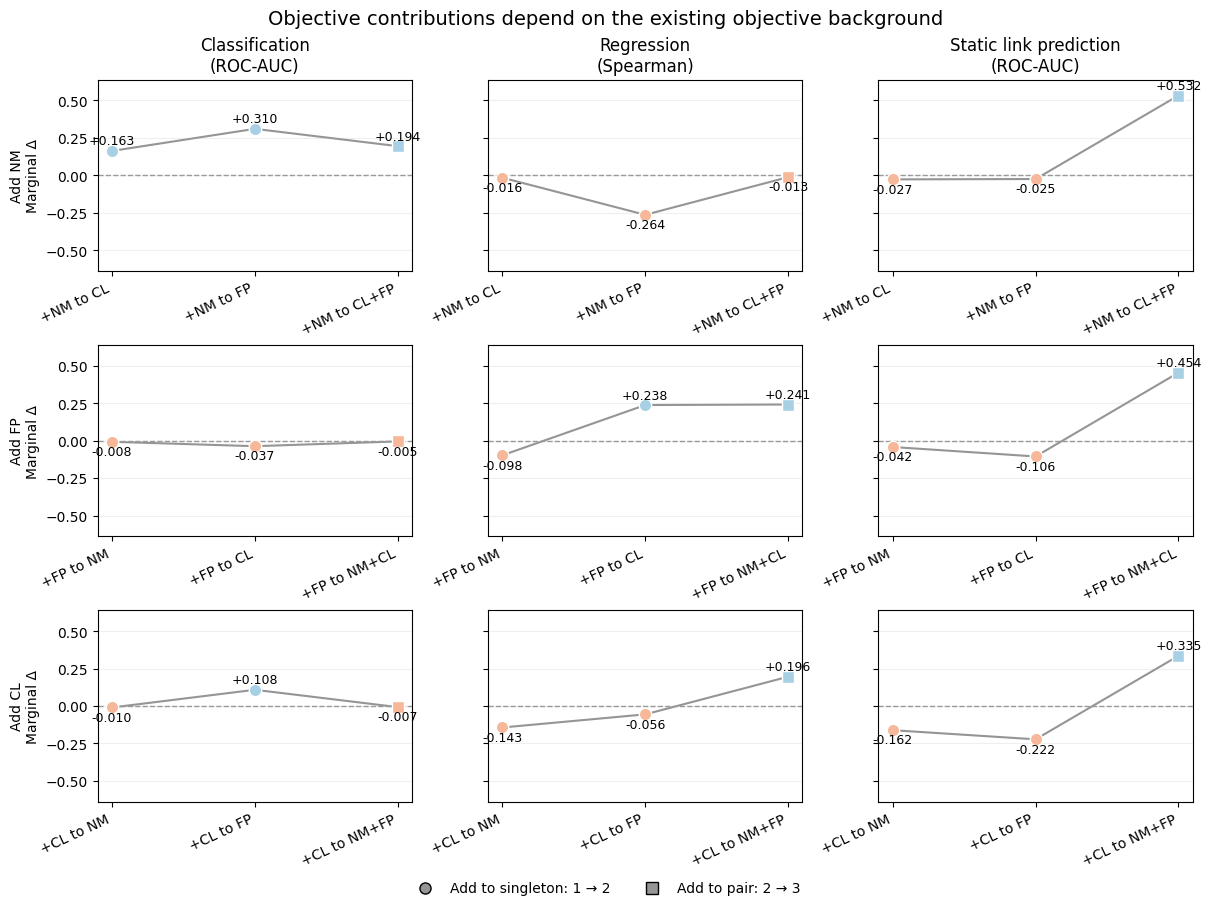

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

related_task = {
    "NM": "classification",
    "FP": "regression",
    "CL": "static_link_prediction",
}

objective_order = ["NM", "FP", "CL"]
stage_order = ["1 → 2", "2 → 3"]

# Keep only each objective's hypothesized related task.
related_effects = transition_summary[
    transition_summary.apply(
        lambda row: row["task"]
        == related_task[row["added_objective"]],
        axis=1,
    )
].copy()

# Average the two singleton-background effects for 1→2.
# The 2→3 stage contains one effect: pair → MIX.
plot_df = (
    related_effects
    .groupby(
        ["added_objective", "stage"],
        as_index=False,
    )["mean_delta"]
    .mean()
)

plot_df["stage"] = plot_df["stage"].replace({
    "1 → 2": "Add to singleton",
    "2 → 3": "Complete MIX",
})

fig, ax = plt.subplots(figsize=(7, 4))

sns.barplot(
    data=plot_df,
    x="added_objective",
    y="mean_delta",
    hue="stage",
    order=objective_order,
    hue_order=["Add to singleton", "Complete MIX"],
    palette=["#9e9e9e", "#3478b8"],
    errorbar=None,
    ax=ax,
)

ax.axhline(0, color="black", linewidth=1)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%+.3f",
        padding=3,
        fontsize=9,
    )

ax.set_title("Objective effects depend on what is already present")
ax.set_xlabel("Objective added")
ax.set_ylabel("Mean marginal Δ on related task")
ax.legend(title="Objective background", frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

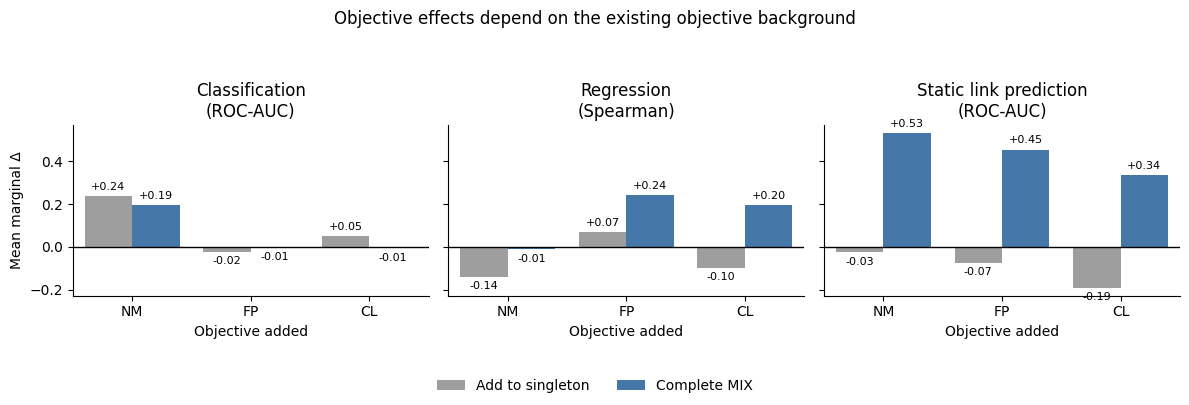

In [789]:
import matplotlib.pyplot as plt
import seaborn as sns

objective_order = ["NM", "FP", "CL"]

task_order = [
    "classification",
    "regression",
    "static_link_prediction",
]

task_labels = {
    "classification": "Classification\n(ROC-AUC)",
    "regression": "Regression\n(Spearman)",
    "static_link_prediction": "Static link prediction\n(ROC-AUC)",
}

# Average the two 1→2 transitions.
# The 2→3 stage already contains one transition.
plot_df = (
    transition_summary
    .groupby(
        ["task", "added_objective", "stage"],
        as_index=False,
    )["mean_delta"]
    .mean()
)

plot_df["background"] = plot_df["stage"].replace({
    "1 → 2": "Add to singleton",
    "2 → 3": "Complete MIX",
})

fig, axes = plt.subplots(
    1,
    3,
    figsize=(12, 4),
    sharey=True,
)

for ax, task in zip(axes, task_order):
    task_df = plot_df[plot_df["task"].eq(task)]

    sns.barplot(
        data=task_df,
        x="added_objective",
        y="mean_delta",
        hue="background",
        order=objective_order,
        hue_order=[
            "Add to singleton",
            "Complete MIX",
        ],
        palette=["#9e9e9e", "#3478b8"],
        errorbar=None,
        ax=ax,
    )

    ax.axhline(
        0,
        color="black",
        linewidth=1,
    )

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%+.2f",
            padding=3,
            fontsize=8,
        )

    ax.set_title(task_labels[task])
    ax.set_xlabel("Objective added")

    if ax is axes[0]:
        ax.set_ylabel("Mean marginal Δ")
    else:
        ax.set_ylabel("")

    ax.legend_.remove()
    sns.despine(ax=ax)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=False,
)

fig.suptitle(
    "Objective effects depend on the existing objective background"
)

plt.tight_layout(
    rect=[0, 0.12, 1, 0.92]
)
plt.show()

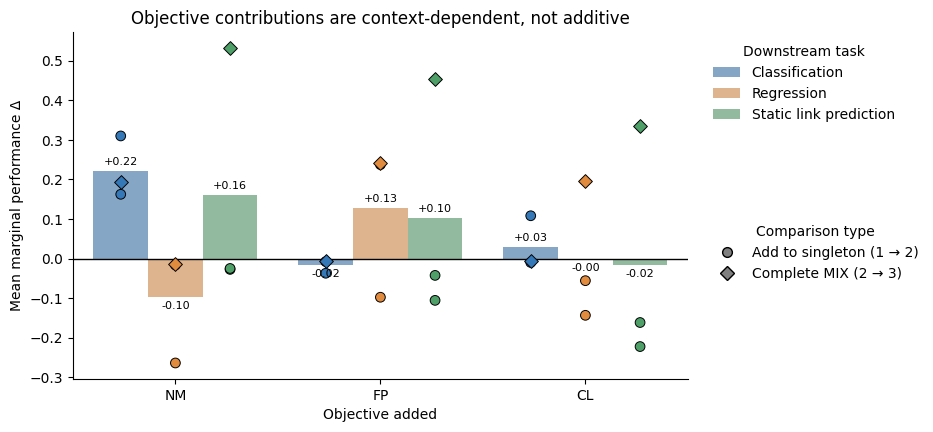

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

objective_order = ["NM", "FP", "CL"]

task_order = [
    "classification",
    "regression",
    "static_link_prediction",
]

task_labels = {
    "classification": "Classification",
    "regression": "Regression",
    "static_link_prediction": "Static link prediction",
}

# Bars: equal-weight mean across all three backgrounds.
bar_df = objective_task_summary.copy()
bar_df["Task"] = bar_df["task"].map(task_labels)

# Dots: individual background-specific mean effects.
point_df = transition_summary.copy()
point_df["Task"] = point_df["task"].map(task_labels)

hue_order = [
    "Classification",
    "Regression",
    "Static link prediction",
]

palette = ["#3478b8", "#e08b3e", "#4e9f68"]

from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(10, 4.5))

# 1. Draw mean bars first.
sns.barplot(
    data=bar_df,
    x="added_objective",
    y="mean_delta",
    hue="Task",
    order=objective_order,
    hue_order=hue_order,
    palette=palette,
    errorbar=None,
    alpha=0.65,
    ax=ax,
)

# Save bar containers for labels.
bar_containers = list(ax.containers)

# Save the task legend created by the bars.
task_handles, task_names = ax.get_legend_handles_labels()
ax.get_legend().remove()

# 2. Overlay dots with stage-specific shapes.
stage_markers = {
    "1 → 2": "o",
    "2 → 3": "D",
}

for stage, marker in stage_markers.items():
    sns.stripplot(
        data=point_df[point_df["stage"].eq(stage)],
        x="added_objective",
        y="mean_delta",
        hue="Task",
        order=objective_order,
        hue_order=hue_order,
        palette=palette,
        dodge=True,
        jitter=0,
        marker=marker,
        size=7,
        edgecolor="black",
        linewidth=0.7,
        legend=False,
        ax=ax,
    )

# 3. Zero reference.
ax.axhline(
    0,
    color="black",
    linewidth=1,
)

# 4. Label mean bars.
for container in bar_containers:
    ax.bar_label(
        container,
        fmt="%+.2f",
        padding=3,
        fontsize=8,
    )

# 5. Task-color legend.
task_legend = ax.legend(
    task_handles[:len(hue_order)],
    task_names[:len(hue_order)],
    title="Downstream task",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

ax.add_artist(task_legend)

# 6. Comparison-shape legend.
shape_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="none",
        markerfacecolor="gray",
        markeredgecolor="black",
        markersize=7,
        label="Add to singleton (1 → 2)",
    ),
    Line2D(
        [0], [0],
        marker="D",
        linestyle="none",
        markerfacecolor="gray",
        markeredgecolor="black",
        markersize=7,
        label="Complete MIX (2 → 3)",
    ),
]

ax.legend(
    handles=shape_handles,
    title="Comparison type",
    frameon=False,
    bbox_to_anchor=(1.02, 0.48),
    loc="upper left",
)

ax.set_title(
    "Objective contributions are context-dependent, not additive"
)
ax.set_xlabel("Objective added")
ax.set_ylabel("Mean marginal performance Δ")

sns.despine()

# Reserve room on the right for both legends.
plt.subplots_adjust(right=0.74)
plt.show()

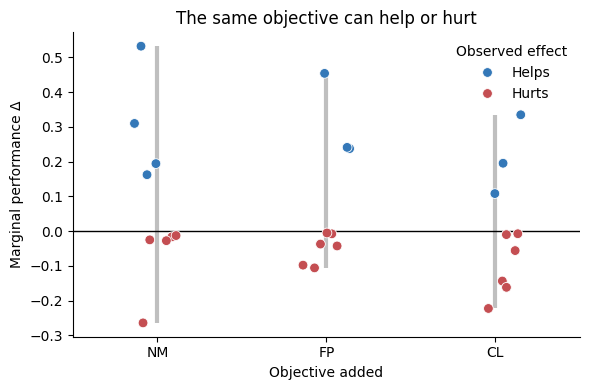

In [894]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

objective_order = ["NM", "FP", "CL"]

plot_df = transition_summary.copy()

plot_df["Effect"] = np.where(
    plot_df["mean_delta"] >= 0,
    "Helps",
    "Hurts",
)

fig, ax = plt.subplots(figsize=(6, 4))

# Show the full effect range for each objective.
for x, objective in enumerate(objective_order):
    values = plot_df.loc[
        plot_df["added_objective"].eq(objective),
        "mean_delta",
    ]

    ax.vlines(
        x,
        values.min(),
        values.max(),
        color="0.75",
        linewidth=3,
        zorder=0,
    )

# Each dot is one task/background-specific effect.
sns.stripplot(
    data=plot_df,
    x="added_objective",
    y="mean_delta",
    hue="Effect",
    order=objective_order,
    hue_order=["Helps", "Hurts"],
    palette={
        "Helps": "#3478b8",
        "Hurts": "#c44e52",
    },
    jitter=0.16,
    size=7,
    edgecolor="white",
    linewidth=0.6,
    ax=ax,
)

ax.axhline(
    0,
    color="black",
    linewidth=1,
)

ax.set_title("The same objective can help or hurt")
ax.set_xlabel("Objective added")
ax.set_ylabel("Marginal performance Δ")

ax.legend(
    title="Observed effect",
    frameon=False,
)

sns.despine()
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'More tasks != better')

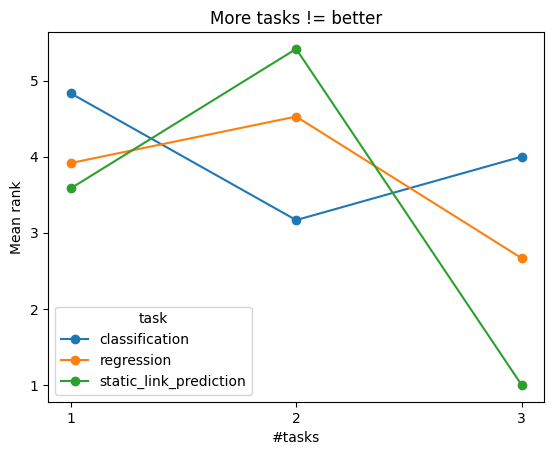

In [912]:
df.groupby(['k', 'task'])['rank'].mean().unstack().plot.line(marker='o')
plt.xticks([1,2,3])
plt.xlabel('#tasks')
plt.ylabel('Mean rank')
plt.title('More tasks != better')

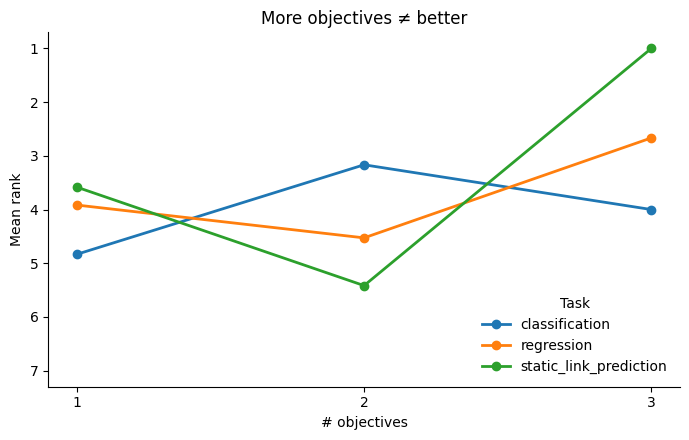

In [917]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mean rank for each individual model.
model_rank = (
    df.groupby(
        ["k", "task", "model"],
        dropna=False,
    )["rank"]
    .mean()
    .reset_index()
)

# Mean/min/max across models with the same number of objectives.
rank_summary = (
    model_rank
    .groupby(["k", "task"])["rank"]
    .agg(["mean", "min", "max"])
    .reset_index()
)

tasks = rank_summary["task"].unique()
colors = dict(
    zip(tasks, sns.color_palette("tab10", len(tasks)))
)

fig, ax = plt.subplots(figsize=(7, 4.5))

for task in tasks:
    task_df = (
        rank_summary[rank_summary["task"].eq(task)]
        .sort_values("k")
    )

    x = task_df["k"].to_numpy()
    mean = task_df["mean"].to_numpy()
    minimum = task_df["min"].to_numpy()
    maximum = task_df["max"].to_numpy()

    # Range across models.
    ax.fill_between(
        x,
        minimum,
        maximum,
        color='white',
        alpha=0.15,
        linewidth=0,
    )

    # Mean across models.
    ax.plot(
        x,
        mean,
        marker="o",
        linewidth=2,
        color=colors[task],
        label=task,
    )

ax.set_xticks([1, 2, 3])
ax.set_xlabel("# objectives")
ax.set_ylabel("Mean rank")
ax.set_title("More objectives ≠ better")

# Rank 1 is best, so put better ranks higher.
ax.invert_yaxis()

ax.legend(
    title="Task",
    frameon=False,
)

sns.despine()
plt.tight_layout()
plt.show()

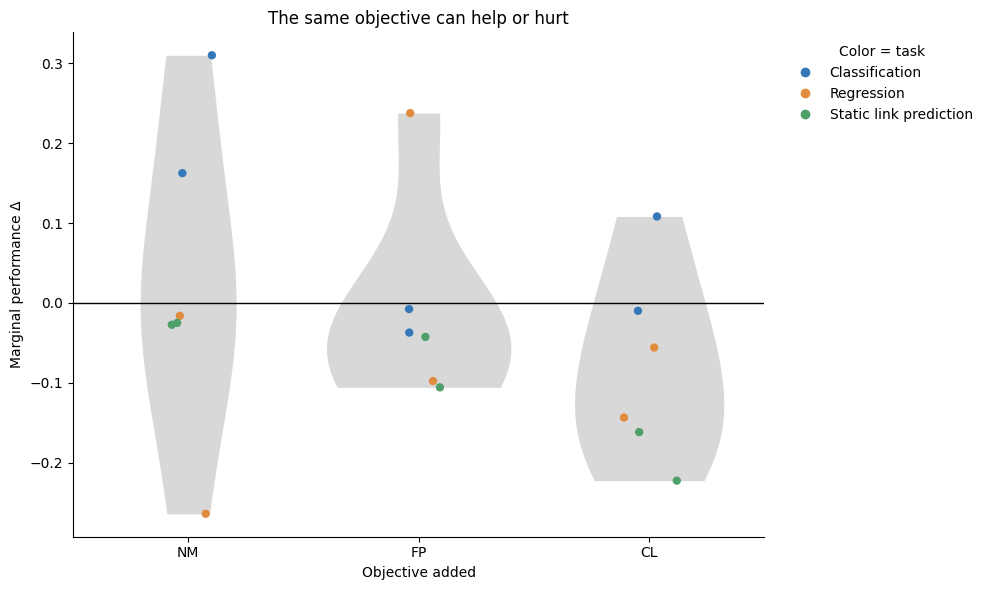

In [961]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

order = ["NM", "FP", "CL"]

task_labels = {
    "classification": "Classification",
    "regression": "Regression",
    "static_link_prediction": "Static link prediction",
}

palette = {
    "Classification": "#3478b8",
    "Regression": "#e08b3e",
    "Static link prediction": "#4e9f68",
}

plot_df = transition_summary.copy()
plot_df["Task"] = plot_df["task"].map(task_labels)

plot_df = plot_df[plot_df.stage.eq("1 → 2")]

fig, ax = plt.subplots(figsize=(10,6))

sns.violinplot(
    data=plot_df,
    x="added_objective",
    y="mean_delta",
    order=order,
    inner=None,
    cut=0,
    # hue="added_objective",
    # palette={
    #     "NM": palette["Classification"],
    #     "FP": palette["Regression"],
    #     "CL": palette["Static link prediction"],
    # },
    legend=False,
    linewidth=0,
    ax=ax,
    alpha=0.3,
    color='grey'
)

for stage, marker in {"1 → 2": "o", "2 → 3": "D"}.items():
    sns.stripplot(
        data=plot_df[plot_df["stage"].eq(stage)],
        x="added_objective",
        y="mean_delta",
        hue="Task",
        order=order,
        palette=palette,
        jitter=0.12,
        marker=marker,
        size=6,
        edgecolor="black",
        linewidth=0,
        legend=False,
        ax=ax,
    )

ax.axhline(0, color="black", linewidth=1)

handles = [
    *[
        Line2D(
            [0], [0],
            marker="o",
            linestyle="none",
            color=color,
            label=task,
        )
        for task, color in palette.items()
    ],
    # Line2D(
    #     [0], [0],
    #     marker="o",
    #     linestyle="none",
    #     color="gray",
    #     label="1 → 2",
    # ),
    # Line2D(
    #     [0], [0],
    #     marker="D",
    #     linestyle="none",
    #     color="gray",
    #     label="2 → 3",
    # ),
]

ax.legend(
    handles=handles,
    title="Color = task",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

ax.set(xlabel="Objective added", ylabel="Marginal performance Δ")
ax.set_title("The same objective can help or hurt")

sns.despine()
plt.tight_layout()
plt.show()

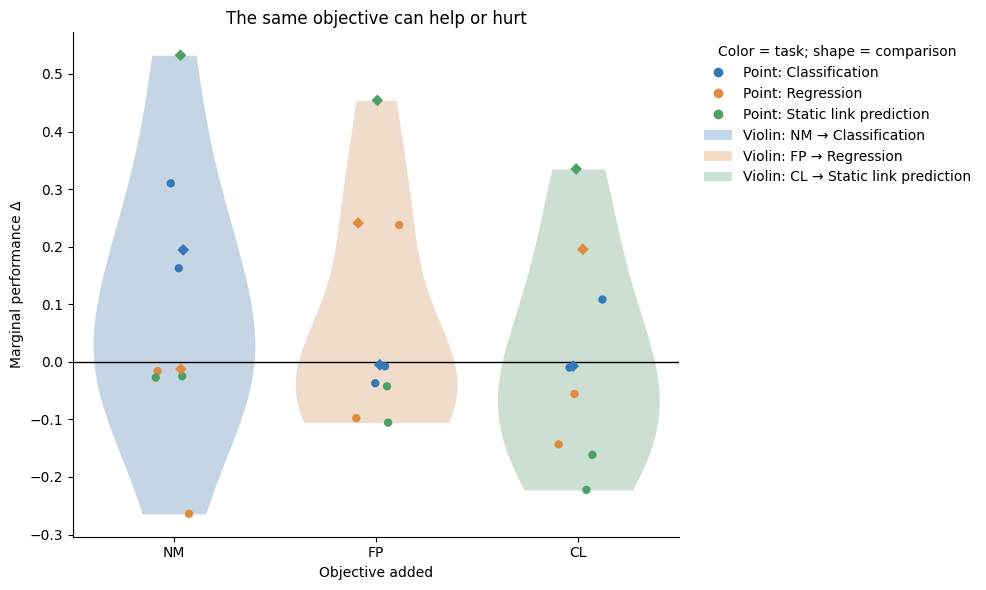

In [944]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

order = ["NM", "FP", "CL"]

task_labels = {
    "classification": "Classification",
    "regression": "Regression",
    "static_link_prediction": "Static link prediction",
}

palette = {
    "Classification": "#3478b8",
    "Regression": "#e08b3e",
    "Static link prediction": "#4e9f68",
}

plot_df = transition_summary.copy()
plot_df["Task"] = plot_df["task"].map(task_labels)

fig, ax = plt.subplots(figsize=(10,6))

sns.violinplot(
    data=plot_df,
    x="added_objective",
    y="mean_delta",
    order=order,
    inner=None,
    cut=0,
    hue="added_objective",
    palette={
        "NM": palette["Classification"],
        "FP": palette["Regression"],
        "CL": palette["Static link prediction"],
    },
    legend=False,
    linewidth=0,
    ax=ax,
    alpha=0.3,
)

for stage, marker in {"1 → 2": "o", "2 → 3": "D"}.items():
    sns.stripplot(
        data=plot_df[plot_df["stage"].eq(stage)],
        x="added_objective",
        y="mean_delta",
        hue="Task",
        order=order,
        palette=palette,
        jitter=0.12,
        marker=marker,
        size=6,
        edgecolor="black",
        linewidth=0,
        legend=False,
        ax=ax,
    )

ax.axhline(0, color="black", linewidth=1)



handles = [
    # Dot colors: evaluated task
    *[
        Line2D(
            [0], [0],
            marker="o",
            linestyle="none",
            color=color,
            label=f"Point: {task}",
        )
        for task, color in palette.items()
    ],

    # Violin colors: objective's related task
    Patch(
        facecolor=palette["Classification"],
        alpha=0.3,
        edgecolor="none",
        label="Violin: NM → Classification",
    ),
    Patch(
        facecolor=palette["Regression"],
        alpha=0.3,
        edgecolor="none",
        label="Violin: FP → Regression",
    ),
    Patch(
        facecolor=palette["Static link prediction"],
        alpha=0.3,
        edgecolor="none",
        label="Violin: CL → Static link prediction",
    ),
]

ax.legend(
    handles=handles,
    title="Color = task; shape = comparison",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

ax.set(xlabel="Objective added", ylabel="Marginal performance Δ")
ax.set_title("The same objective can help or hurt")

sns.despine()
plt.tight_layout()
plt.show()

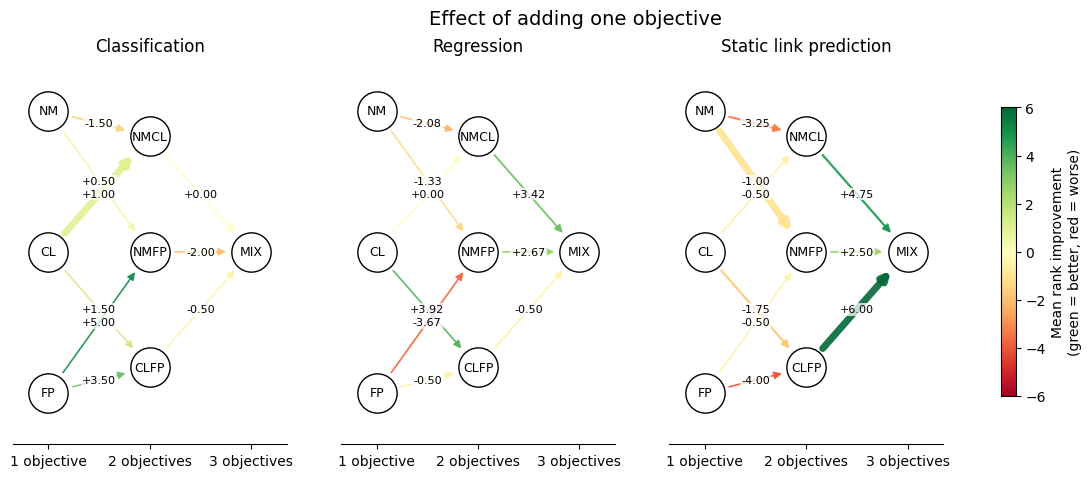

In [960]:
import numpy as np
import pandas as pd

edges = [
    ("NM",   "NMCL",  "CL"),
    ("CL",   "NMCL",  "NM"),
    ("NM",   "NMFP",  "FP"),
    ("FP",   "NMFP",  "NM"),
    ("CL",   "CLFP",  "FP"),
    ("FP",   "CLFP",  "CL"),
    ("NMCL", "MIX",   "FP"),
    ("NMFP", "MIX",   "CL"),
    ("CLFP", "MIX",   "NM"),
]

tasks = [
    "classification",
    "regression",
    "static_link_prediction",
]

match_keys = [
    "dataset",
    "target",
    "split",
    "shots",
]

rank_scores = (
    df.groupby(
        match_keys + ["task", "model"],
        dropna=False,
    )["rank"]
    .mean()
    .rename("rank")
    .reset_index()
)

rows = []

for task in tasks:
    for source, destination, added in edges:
        source_scores = (
            rank_scores[
                rank_scores["task"].eq(task)
                & rank_scores["model"].eq(source)
            ][match_keys + ["rank"]]
            .rename(columns={"rank": "source_rank"})
        )

        destination_scores = (
            rank_scores[
                rank_scores["task"].eq(task)
                & rank_scores["model"].eq(destination)
            ][match_keys + ["rank"]]
            .rename(columns={"rank": "destination_rank"})
        )

        matched = source_scores.merge(
            destination_scores,
            on=match_keys,
            how="inner",
            validate="one_to_one",
        )

        # Positive means adding the objective improves rank.
        delta = (
            matched["source_rank"]
            - matched["destination_rank"]
        )

        rows.append({
            "task": task,
            "source": source,
            "destination": destination,
            "added": added,
            "mean_delta": delta.mean(),
            "std_delta": delta.std(ddof=1),
            "n": len(delta),
        })

edge_stats = pd.DataFrame(rows)

std = edge_stats["std_delta"].copy()

fallback = std.dropna().max()
if pd.isna(fallback):
    fallback = 1.0

std = std.fillna(fallback)

stability = 1 / (std + 0.1)

lo = stability.min()
hi = stability.max()

if hi > lo:
    edge_stats["width"] = (
        1 + 4 * (stability - lo) / (hi - lo)
    )
else:
    edge_stats["width"] = 2.5
    
    import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import FancyArrowPatch
from matplotlib.cm import ScalarMappable

positions = {
    # One objective
    "NM":   (0, 2.2),
    "CL":   (0, 1.1),
    "FP":   (0, 0.0),

    # Two objectives
    "NMCL": (1, 2.0),
    "NMFP": (1, 1.1),
    "CLFP": (1, 0.2),

    # Three objectives
    "MIX":  (2, 1.1),
}

task_titles = {
    "classification": "Classification",
    "regression": "Regression",
    "static_link_prediction": "Static link prediction",
}

limit = max(
    edge_stats["mean_delta"].abs().max(),
    1e-6,
)

norm = TwoSlopeNorm(
    vmin=-limit,
    vcenter=0,
    vmax=limit,
)

cmap = plt.cm.RdYlGn

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
    constrained_layout=False,
)

for ax, task in zip(axes, tasks):
    task_edges = edge_stats[
        edge_stats["task"].eq(task)
    ]

    # Draw addition effects as directed edges.
    for _, row in task_edges.iterrows():
        x1, y1 = positions[row["source"]]
        x2, y2 = positions[row["destination"]]

        color = cmap(norm(row["mean_delta"]))

        arrow = FancyArrowPatch(
            (x1, y1),
            (x2, y2),
            arrowstyle="-|>",
            mutation_scale=11,
            linewidth=row["width"],
            color=color,
            alpha=0.9,
            shrinkA=18,
            shrinkB=18,
            zorder=1,
        )

        ax.add_patch(arrow)

        # Effect label at edge midpoint.
        ax.text(
            (x1 + x2) / 2,
            (y1 + y2) / 2,
            f'{row["mean_delta"]:+.2f}',
            ha="center",
            va="center",
            fontsize=8,
            bbox={
                "facecolor": "white",
                "edgecolor": "none",
                "alpha": 0.75,
                "pad": 1,
            },
            zorder=3,
        )

    # Draw model nodes.
    for model, (x, y) in positions.items():
        ax.scatter(
            x,
            y,
            s=800,
            facecolor="white",
            edgecolor="black",
            linewidth=1,
            zorder=2,
        )

        ax.text(
            x,
            y,
            model,
            ha="center",
            va="center",
            fontsize=9,
            zorder=3,
        )

    ax.set_title(task_titles[task])
    ax.set_xlim(-0.35, 2.35)
    ax.set_ylim(-0.4, 2.6)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels([
        "1 objective",
        "2 objectives",
        "3 objectives",
    ])
    ax.set_yticks([])

    for side in ["left", "right", "top"]:
        ax.spines[side].set_visible(False)

fig.suptitle(
    "Effect of adding one objective",
    fontsize=14,
)

colorbar = fig.colorbar(
    ScalarMappable(norm=norm, cmap=cmap),
    ax=axes,
    shrink=0.75,
)

colorbar.set_label(
    "Mean rank improvement\n"
    "(green = better, red = worse)"
)

plt.show()

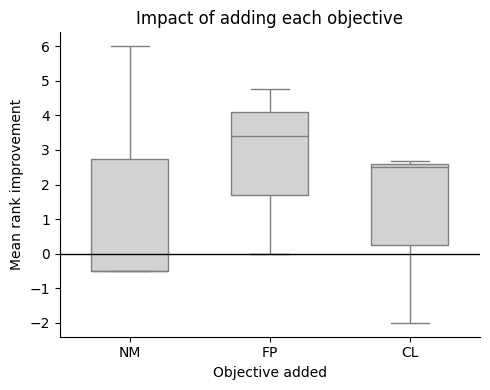

In [965]:
import matplotlib.pyplot as plt
import seaborn as sns


stages = [
    # "1 → 2", 
    "2 → 3"
    ]
plot_df = rank_transitions[rank_transitions["stage"].isin(stages)]

fig, ax = plt.subplots(figsize=(5, 4))

sns.boxplot(
    data=plot_df,
    x="added_objective",
    y="mean_rank_improvement",
    order=["NM", "FP", "CL"],
    whis=(0, 100),       # whiskers show full min–max range
    showfliers=False,
    color="lightgray",
    width=0.55,
    ax=ax,
)

ax.axhline(0, color="black", linewidth=1)
ax.set_xlabel("Objective added")
ax.set_ylabel("Mean rank improvement")
ax.set_title("Impact of adding each objective")

sns.despine()
plt.tight_layout()
plt.show()

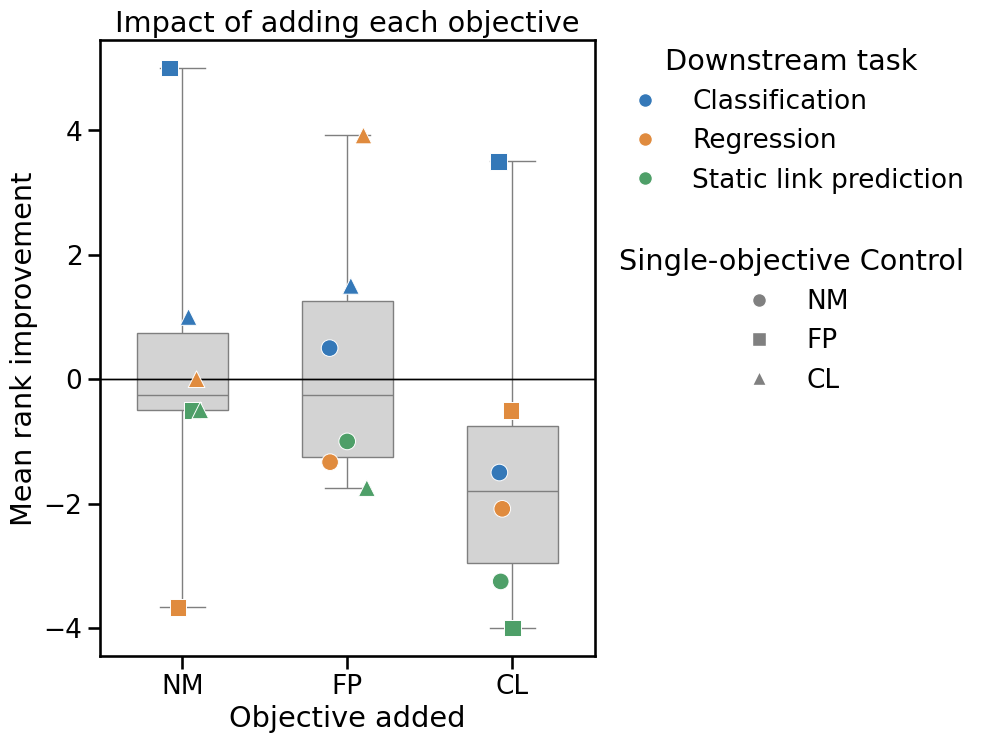

In [1079]:
import matplotlib.pyplot as plt
import seaborn as sns

stages = [
    "1 → 2",
    # "2 → 3"
    ]

plot_df = rank_transitions[
    rank_transitions["stage"].isin(stages)
].copy()

plot_df["Task"] = plot_df["task"].map({
    "classification": "Classification",
    "regression": "Regression",
    "static_link_prediction": "Static link prediction",
})

sns.set_context("talk", font_scale=1.15)

fig, ax = plt.subplots(figsize=(10,8))

sns.boxplot(
    data=plot_df,
    x="added_objective",
    y="mean_rank_improvement",
    order=["NM", "FP", "CL"],
    whis=(0, 100),
    showfliers=False,
    color="lightgray",
    width=0.55,
    ax=ax,
)

ax.axhline(0, color="black", linewidth=1)
# plt.tight_layout()
# plt.legend()

from matplotlib.lines import Line2D

task_palette = {
    "Classification": "#3478b8",
    "Regression": "#e08b3e",
    "Static link prediction": "#4e9f68",
}

source_markers = {
    "NM": "o",
    "FP": "s",
    "CL": "^",
}

# Draw each source separately to assign its marker.
for source, marker in source_markers.items():
    sns.stripplot(
        data=plot_df[plot_df["control_model"].eq(source)],
        x="added_objective",
        y="mean_rank_improvement",
        hue="Task",
        order=["NM", "FP", "CL"],
        hue_order=list(task_palette),
        palette=task_palette,
        marker=marker,
        jitter=0.12,
        size=12,
        edgecolor="white",
        linewidth=0.7,
        legend=False,
        ax=ax,
    )

# Color legend: downstream task.
task_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="none",
        markerfacecolor=color,
        markeredgecolor="white",
        markersize=10,
        label=task,
    )
    for task, color in task_palette.items()
]

# task_legend = ax.legend(
#     handles=task_handles,
#     title="Downstream task",
#     frameon=False,
#     loc="upper left",
#     bbox_to_anchor=(1.001, 1),
# )
# ax.add_artist(task_legend)

# Shape legend: singleton source model.
source_handles = [
    Line2D(
        [0], [0],
        marker=marker,
        linestyle="none",
        markerfacecolor="gray",
        markeredgecolor="white",
        markersize=10,
        label=source,
    )
    for source, marker in source_markers.items()
]

ax.axhline(0, color="black", linewidth=1)

ax.set_xlabel("Objective added")
ax.set_ylabel("Mean rank improvement")
ax.set_title("Impact of adding each objective")

# sns.despine()

# Leave space for the two legends.
# Leave the right 38% of the figure for legends.
fig.subplots_adjust(right=0.62)

fig.legend(
    handles=task_handles,
    title="Downstream task",
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(0.62, 0.9),
)

fig.legend(
    handles=source_handles,
    title="Single-objective Control",
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(0.62, 0.65),
)

plt.show()

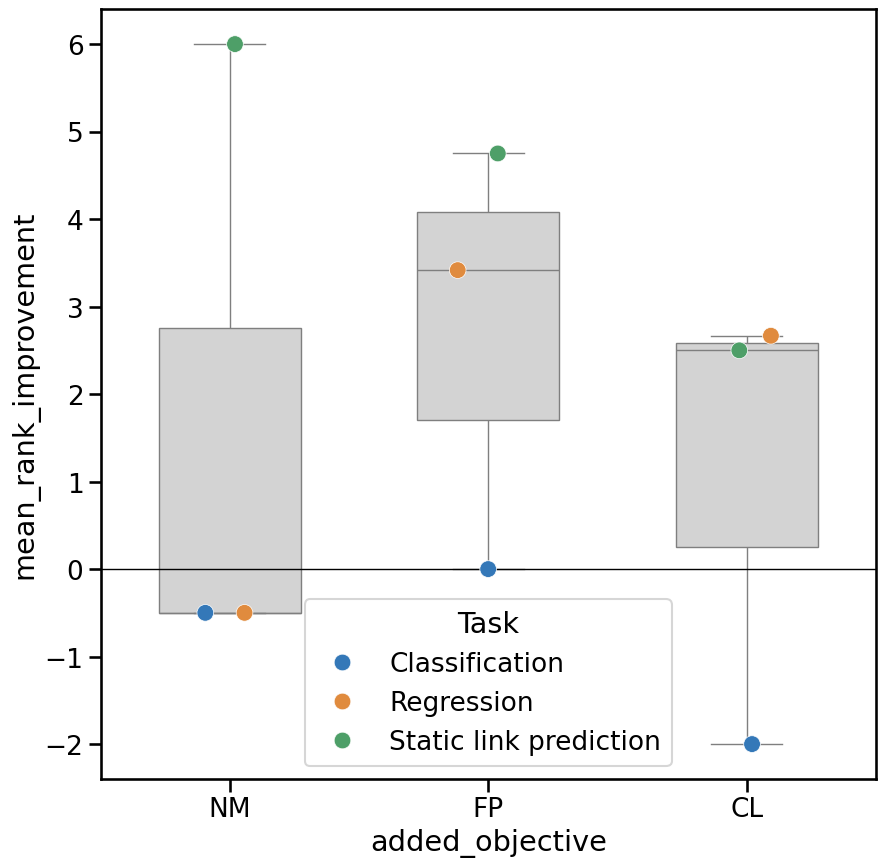

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

stages = [
    "1 → 2",
    "2 → 3"
    ]

plot_df = rank_transitions[
    rank_transitions["stage"].isin(stages)
].copy()

plot_df["Task"] = plot_df["task"].map({
    "classification": "Classification",
    "regression": "Regression",
    "static_link_prediction": "Static link prediction",
})

sns.set_context("talk", font_scale=1.15)

fig, ax = plt.subplots(figsize=(10,10))

sns.boxplot(
    data=plot_df,
    x="added_objective",
    y="mean_rank_improvement",
    order=["NM", "FP", "CL"],
    whis=(0, 100),
    showfliers=False,
    color="lightgray",
    width=0.55,
    ax=ax,
)

sns.stripplot(
    data=plot_df,
    x="added_objective",
    y="mean_rank_improvement",
    hue="Task",
    order=["NM", "FP", "CL"],
    palette=["#3478b8", "#e08b3e", "#4e9f68"],
    jitter=0.12,
    size=12,
    edgecolor="white",
    linewidth=0.5,
    ax=ax,
)

ax.axhline(0, color="black", linewidth=1)
# plt.tight_layout()
# plt.legend()

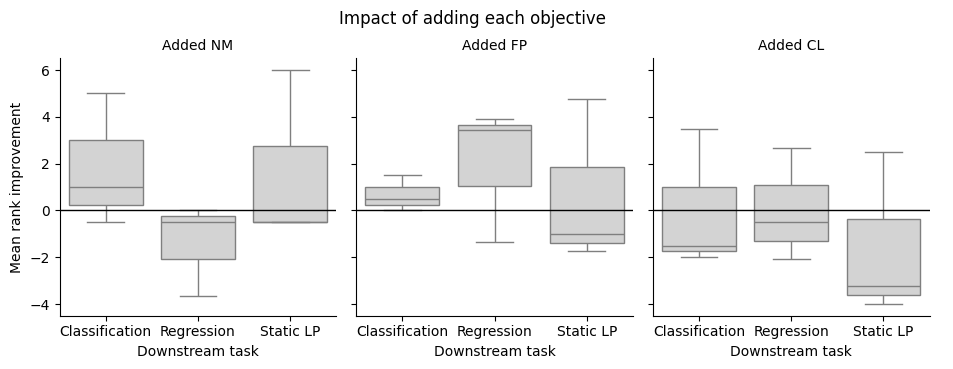

In [967]:
import matplotlib.pyplot as plt
import seaborn as sns

include_2_to_3 = True  # False = only 1→2

stages = ["1 → 2", "2 → 3"] if include_2_to_3 else ["1 → 2"]
plot_df = rank_transitions[
    rank_transitions["stage"].isin(stages)
].copy()

plot_df["Task"] = plot_df["task"].map({
    "classification": "Classification",
    "regression": "Regression",
    "static_link_prediction": "Static LP",
})

g = sns.catplot(
    data=plot_df,
    x="Task",
    y="mean_rank_improvement",
    col="added_objective",
    col_order=["NM", "FP", "CL"],
    order=["Classification", "Regression", "Static LP"],
    kind="box",
    whis=(0, 100),
    showfliers=False,
    color="lightgray",
    height=3.5,
    aspect=0.9,
)

for ax in g.axes.flat:
    ax.axhline(0, color="black", linewidth=1)

g.set_axis_labels("Downstream task", "Mean rank improvement")
g.set_titles("Added {col_name}")
g.figure.suptitle("Impact of adding each objective", y=1.04)

sns.despine()
plt.show()

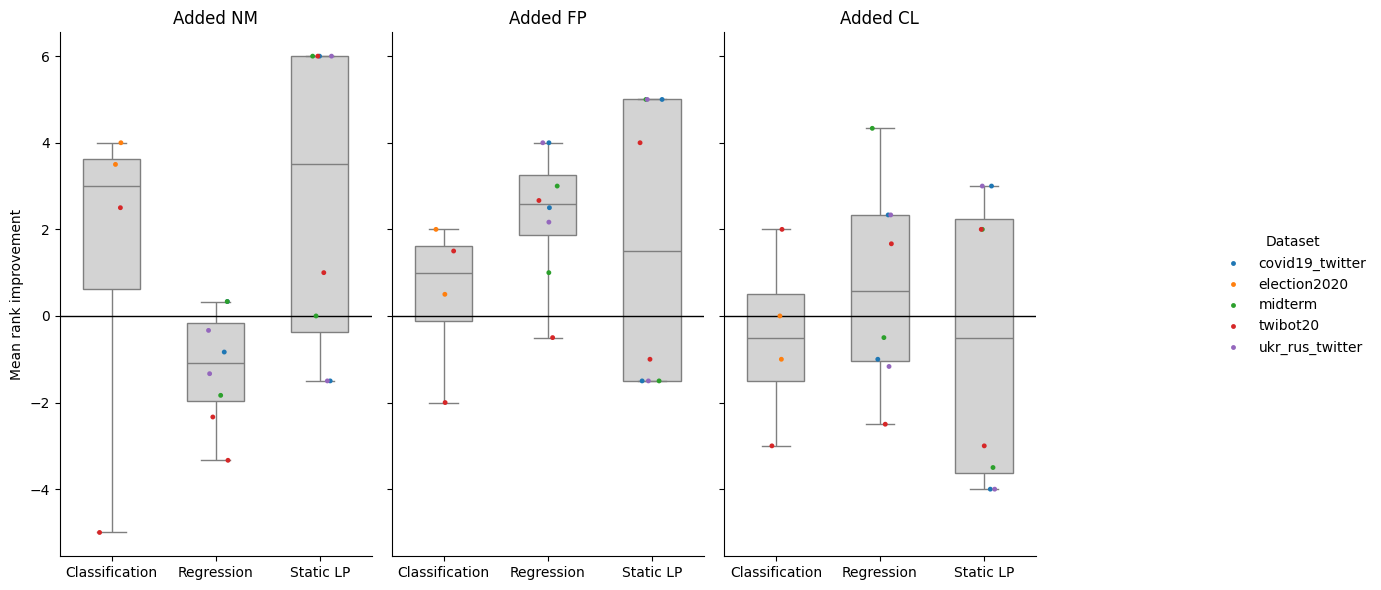

In [970]:
import pandas as pd

match_keys = ["task", "dataset", "target", "split", "shots"]

wide_rank = (
    df.groupby(match_keys + ["model"], dropna=False)["rank"]
    .mean()
    .unstack("model")
)

transitions = [
    ("NM", "1 → 2", "CL",   "NMCL"),
    ("NM", "1 → 2", "FP",   "NMFP"),
    ("NM", "2 → 3", "CLFP", "MIX"),
    ("FP", "1 → 2", "NM",   "NMFP"),
    ("FP", "1 → 2", "CL",   "CLFP"),
    ("FP", "2 → 3", "NMCL", "MIX"),
    ("CL", "1 → 2", "NM",   "NMCL"),
    ("CL", "1 → 2", "FP",   "CLFP"),
    ("CL", "2 → 3", "NMFP", "MIX"),
]

parts = []

for added, stage, control, treatment in transitions:
    x = wide_rank[[control, treatment]].dropna().reset_index()

    x["added_objective"] = added
    x["stage"] = stage
    x["rank_improvement"] = x[control] - x[treatment]

    parts.append(x)

rank_dataset_effects = pd.concat(parts, ignore_index=True)

# One value per dataset and transition.
rank_dataset_effects = (
    rank_dataset_effects
    .groupby(
        [
            "dataset",
            "task",
            "added_objective",
            "stage",
        ],
        as_index=False,
    )["rank_improvement"]
    .mean()
)

import matplotlib.pyplot as plt
import seaborn as sns

include_2_to_3 = True

stages = ["1 → 2", "2 → 3"] if include_2_to_3 else ["1 → 2"]

plot_df = rank_dataset_effects[
    rank_dataset_effects["stage"].isin(stages)
].copy()

plot_df["Task"] = plot_df["task"].map({
    "classification": "Classification",
    "regression": "Regression",
    "static_link_prediction": "Static LP",
})

objectives = ["NM", "FP", "CL"]
task_order = ["Classification", "Regression", "Static LP"]

datasets = sorted(plot_df["dataset"].unique())
palette = dict(zip(
    datasets,
    sns.color_palette("tab10", len(datasets)),
))

fig, axes = plt.subplots(
    1, 3,
    figsize=(12, 6),
    sharey=True,
)

legend_handles = legend_labels = None

for ax, objective in zip(axes, objectives):
    sub = plot_df[
        plot_df["added_objective"].eq(objective)
    ]

    sns.boxplot(
        data=sub,
        x="Task",
        y="rank_improvement",
        order=task_order,
        whis=(0, 100),
        showfliers=False,
        color="lightgray",
        width=0.55,
        ax=ax,
    )

    sns.stripplot(
        data=sub,
        x="Task",
        y="rank_improvement",
        hue="dataset",
        order=task_order,
        palette=palette,
        jitter=0.12,
        size=3.5,
        linewidth=0,
        ax=ax,
    )

    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(f"Added {objective}")
    ax.set_xlabel("")

    if ax is axes[0]:
        ax.set_ylabel("Mean rank improvement")
        legend_handles, legend_labels = ax.get_legend_handles_labels()
    else:
        ax.set_ylabel("")

    ax.get_legend().remove()

fig.legend(
    legend_handles,
    legend_labels,
    title="Dataset",
    frameon=False,
    bbox_to_anchor=(1.01, 0.5),
    loc="center left",
)

sns.despine()
plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()

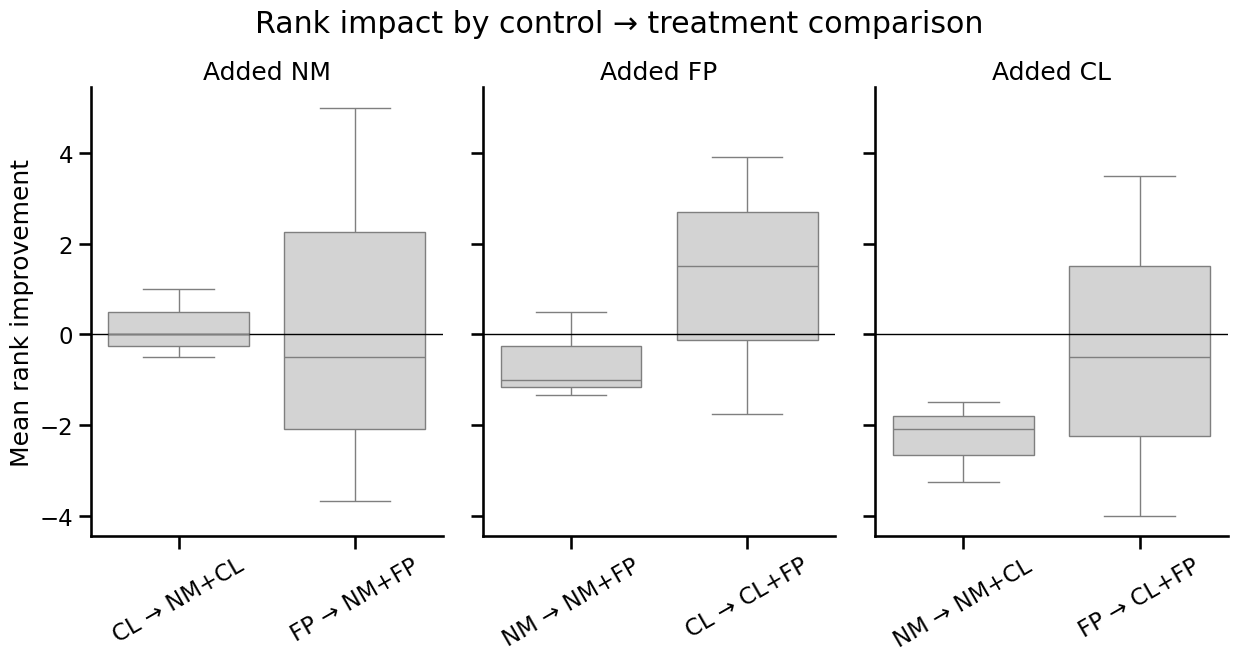

In [1179]:
sns.set_context("talk", font_scale=1)


stages = ["1 → 2",]

plot_df = rank_transitions[
    rank_transitions["stage"].isin(stages)
].copy()

pretty = {
    "NMCL": "NM+CL",
    "NMFP": "NM+FP",
    "CLFP": "CL+FP",
    "MIX": "NM+FP+CL",
}

plot_df["comparison"] = (
    plot_df["control_model"].replace(pretty)
    + " → "
    + plot_df["treatment_model"].replace(pretty)
)


g = sns.catplot(
    data=plot_df,
    x="comparison",
    y="mean_rank_improvement",
    col="added_objective",
    col_order=["NM", "FP", "CL"],
    kind="box",
    whis=(0, 100),
    showfliers=False,
    color="lightgray",
    sharex=False,
    height=6,
    aspect=0.7,
)

for ax in g.axes.flat:
    ax.axhline(0, color="black", linewidth=1)
    ax.tick_params(axis="x", rotation=30)

g.set_axis_labels("", "Mean rank improvement")
g.set_titles("Added {col_name}")
g.fig.suptitle(
    "Rank impact by control → treatment comparison",
    y=1.04,
)


sns.despine()
plt.show()

sns.set_context("talk", font_scale=1)


In [1104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

models = ["NM", "CL", "FP", "NM+CL", "NM+FP", "CL+FP", "NM+FP+CL"]
tasks = ["classification", "regression", "static_link_prediction"]

def annotations(mean, std):
    return pd.DataFrame(
        [
            [
                "" if pd.isna(mean.loc[m, t])
                else (
                    f"{mean.loc[m, t]:.2f}"
                    if pd.isna(std.loc[m, t])
                    else f"{mean.loc[m, t]:.2f} ± {std.loc[m, t]:.2f}"
                )
                for t in mean.columns
            ]
            for m in mean.index
        ],
        index=mean.index,
        columns=mean.columns,
    )


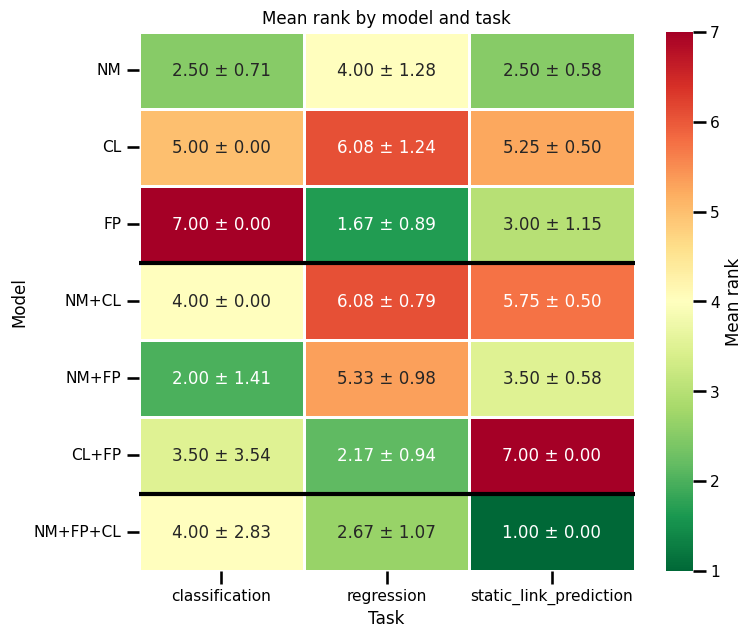

In [1109]:
sns.set_context("talk", font_scale=0.67)

m = {'NMCL': 'NM+CL', 'NMFP': 'NM+FP', 'CLFP': 'CL+FP', "MIX": "NM+FP+CL"}

df['model'] = df.model.replace(m)

rank_stats = (
    df.groupby(["model", "task"])["rank"]
    .agg(["mean", "std"])
    .reset_index()
)

rank_mean = (
    rank_stats.pivot(index="model", columns="task", values="mean")
    .reindex(index=models, columns=tasks)
)

rank_std = (
    rank_stats.pivot(index="model", columns="task", values="std")
    .reindex_like(rank_mean)
)

plt.figure(figsize=(8, 7))
sns.heatmap(
    rank_mean,
    annot=annotations(rank_mean, rank_std),
    fmt="",
    cmap="RdYlGn_r",  # low rank = green
    linewidths=1,
    mask=rank_mean.isna(),
    cbar_kws={"label": "Mean rank"},
)

plt.hlines(
    [3, 6],
    xmin=0,
    xmax=matrix.shape[1],
    colors="black",
    linewidths=3,
)


plt.xlabel("Task")
plt.ylabel("Model")
plt.title("Mean rank by model and task")
# plt.tight_layout()
plt.yticks(rotation=0)
plt.show()

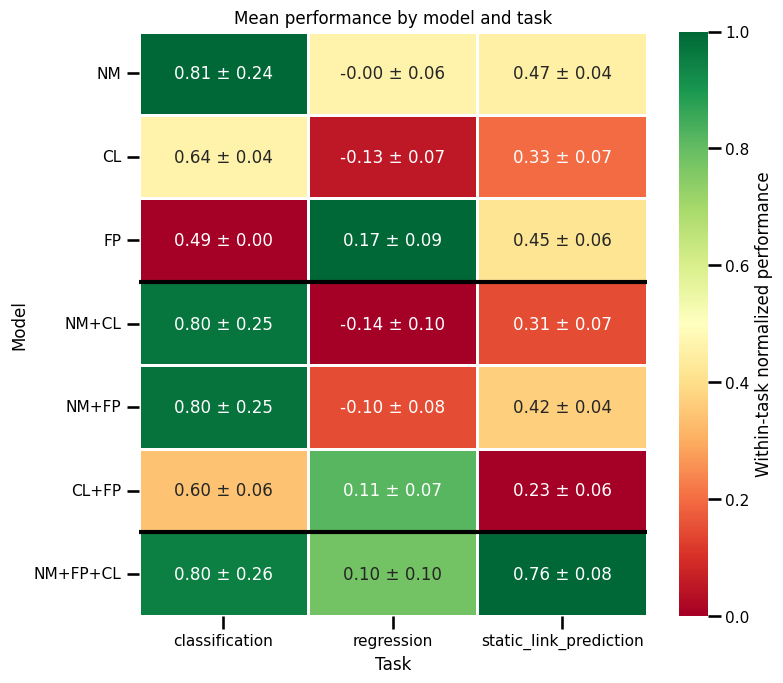

In [1108]:
metric_by_task = {
    "classification": "roc_auc",
    "regression": "spearman",
    "static_link_prediction": "roc_auc",
}

performance = pd.concat([
    df.loc[df["task"].eq(task), ["model", metric]]
      .rename(columns={metric: "score"})
      .assign(task=task)
    for task, metric in metric_by_task.items()
])

perf_stats = (
    performance.groupby(["model", "task"])["score"]
    .agg(["mean", "std"])
    .reset_index()
)

perf_mean = (
    perf_stats.pivot(index="model", columns="task", values="mean")
    .reindex(index=models, columns=tasks)
)

perf_std = (
    perf_stats.pivot(index="model", columns="task", values="std")
    .reindex_like(perf_mean)
)

# Normalize colors independently within each task.
perf_color = (
    (perf_mean - perf_mean.min())
    / (perf_mean.max() - perf_mean.min())
).fillna(0.5)

plt.figure(figsize=(8, 7))
sns.heatmap(
    perf_color,
    annot=annotations(perf_mean, perf_std),
    fmt="",
    cmap="RdYlGn",  # low performance = red; high = green
    vmin=0,
    vmax=1,
    linewidths=1,
    mask=perf_mean.isna(),
    cbar_kws={"label": "Within-task normalized performance"},
)

plt.hlines(
    [3, 6],
    xmin=0,
    xmax=matrix.shape[1],
    colors="black",
    linewidths=3,
)


plt.xlabel("Task")
plt.yticks(rotation=0)
plt.ylabel("Model")
plt.title("Mean performance by model and task")
plt.tight_layout()
plt.show()